In [1]:
# ============================================================
# 09 — IBM QUANTUM HARDWARE EVALUATION
# CELL 1 — ENVIRONMENT & CONNECTION CHECK
# ============================================================

import sys
import numpy as np
import pandas as pd

print("=" * 70)
print("09 — IBM QUANTUM HARDWARE EVALUATION")
print("CELL 1 — ENVIRONMENT & CONNECTION CHECK")
print("=" * 70)

print("\nPYTHON")
print("Version :", sys.version)

# ------------------------------------------------------------
# Qiskit
# ------------------------------------------------------------

try:
    import qiskit
    print("\nQISKIT")
    print("Version :", qiskit.__version__)
except Exception as e:
    print("\nQISKIT")
    print("ERROR  :", e)
    raise

# ------------------------------------------------------------
# IBM Runtime
# ------------------------------------------------------------

try:
    import qiskit_ibm_runtime
    from qiskit_ibm_runtime import QiskitRuntimeService

    print("\nQISKIT IBM RUNTIME")
    print("Version :", qiskit_ibm_runtime.__version__)

except Exception as e:
    print("\nQISKIT IBM RUNTIME")
    print("ERROR  :", e)
    raise

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\heart\quantum_6g_ai")
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

print("\nPROJECT")
print("Project :", PROJECT_DIR)
print("Results :", RESULTS_DIR)
print("Figures :", FIGURES_DIR)

assert PROJECT_DIR.exists()
assert RESULTS_DIR.exists()
assert FIGURES_DIR.exists()

# ------------------------------------------------------------
# Trained VQC parameters
# ------------------------------------------------------------

trained_theta = np.load(
    RESULTS_DIR / "trained_theta.npy"
)

print("\nTRAINED VQC")
print("Parameters :", len(trained_theta))
print("Shape      :", trained_theta.shape)

assert trained_theta.shape == (16,)

# ------------------------------------------------------------
# Test dataset
# ------------------------------------------------------------

test_data = pd.read_csv(
    RESULTS_DIR / "quantum_test_features.csv"
)

print("\nTEST DATA")
print("Shape      :", test_data.shape)
print("Columns    :", list(test_data.columns))

assert test_data.shape == (200, 5)

# ------------------------------------------------------------
# IBM Quantum connection
# ------------------------------------------------------------

print("\nIBM QUANTUM CONNECTION")
print("Checking saved IBM Quantum account...")

service = QiskitRuntimeService()

print("Connection : PASS")

# ------------------------------------------------------------
# Backend discovery
# ------------------------------------------------------------

print("\nAVAILABLE IBM BACKENDS")

backends = service.backends()

print("Backend count :", len(backends))

for backend in backends:
    try:
        status = backend.status()

        print(
            f"{backend.name:15s} | "
            f"qubits={backend.num_qubits:3d} | "
            f"operational={status.operational} | "
            f"pending={status.pending_jobs}"
        )

    except Exception as e:
        print(
            f"{backend.name:15s} | "
            f"status unavailable | {e}"
        )

print("\nValidation: PASS")

09 — IBM QUANTUM HARDWARE EVALUATION
CELL 1 — ENVIRONMENT & CONNECTION CHECK

PYTHON
Version : 3.11.5 | packaged by Anaconda, Inc. | (main, Sep 11 2023, 13:26:23) [MSC v.1916 64 bit (AMD64)]

QISKIT
Version : 2.5.2

QISKIT IBM RUNTIME
Version : 0.49.0

PROJECT
Project : C:\Users\heart\quantum_6g_ai
Results : C:\Users\heart\quantum_6g_ai\results
Figures : C:\Users\heart\quantum_6g_ai\results\figures

TRAINED VQC
Parameters : 16
Shape      : (16,)

TEST DATA
Shape      : (200, 5)
Columns    : ['Trust_Score', 'Risk_Score', 'Interference', 'Resource_Load', 'Label']

IBM QUANTUM CONNECTION
Checking saved IBM Quantum account...


qiskit_runtime_service.__init__:WARNING:2026-09-18 16:55:03,868: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-18 16:55:03,868: Loading instance: open-instance, plan: open


Connection : PASS

AVAILABLE IBM BACKENDS
Backend count : 3
ibm_fez         | qubits=156 | operational=True | pending=1
ibm_marrakesh   | qubits=156 | operational=True | pending=3
ibm_kingston    | qubits=156 | operational=True | pending=77

Validation: PASS


In [2]:
# ============================================================
# 09 — CELL 1B
# IBM BACKEND VERIFICATION
# ============================================================

print("=" * 70)
print("IBM QUANTUM BACKEND VERIFICATION")
print("=" * 70)

# ------------------------------------------------------------
# Confirm service
# ------------------------------------------------------------

assert service is not None

print("\nIBM SERVICE")
print("Connection : PASS")

# ------------------------------------------------------------
# Get backends
# ------------------------------------------------------------

print("\nLOADING BACKENDS...")

backends = service.backends()

print("Backend count :", len(backends))

# ------------------------------------------------------------
# Backend information
# ------------------------------------------------------------

print("\nBACKEND STATUS")
print("-" * 70)

backend_records = []

for backend in backends:

    try:
        status = backend.status()

        record = {
            "backend": backend.name,
            "qubits": backend.num_qubits,
            "operational": status.operational,
            "pending_jobs": status.pending_jobs,
        }

        backend_records.append(record)

        print(
            f"{backend.name:20s} | "
            f"qubits={backend.num_qubits:3d} | "
            f"operational={status.operational!s:5s} | "
            f"pending={status.pending_jobs}"
        )

    except Exception as e:

        print(
            f"{backend.name:20s} | "
            f"status unavailable | {e}"
        )

# ------------------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------------------

backend_df = pd.DataFrame(backend_records)

print("\nBACKEND DATAFRAME")
display(backend_df)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert len(backends) > 0
assert len(backend_df) > 0

print("\nValidation: PASS")

qiskit_runtime_service.backends:WARNING:2026-09-18 16:55:13,864: Loading instance: open-instance, plan: open


IBM QUANTUM BACKEND VERIFICATION

IBM SERVICE
Connection : PASS

LOADING BACKENDS...
Backend count : 3

BACKEND STATUS
----------------------------------------------------------------------
ibm_fez              | qubits=156 | operational=True  | pending=1
ibm_marrakesh        | qubits=156 | operational=True  | pending=3
ibm_kingston         | qubits=156 | operational=True  | pending=77

BACKEND DATAFRAME


,backend,qubits,operational,pending_jobs
0,ibm_fez,156,True,1
1,ibm_marrakesh,156,True,3
2,ibm_kingston,156,True,77



Validation: PASS


In [3]:
# ============================================================
# 09 — CELL 2
# REBUILD TRAINED VQC FOR HARDWARE EXECUTION
# ============================================================

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

print("=" * 70)
print("09 — HARDWARE VQC CIRCUIT RECONSTRUCTION")
print("=" * 70)

# ------------------------------------------------------------
# Configuration — MUST MATCH TRAINING
# ------------------------------------------------------------

N_QUBITS = 4
N_LAYERS = 2
N_PARAMS = 16

VQC_PARAMS = ParameterVector(
    "theta",
    length=N_PARAMS
)

# ------------------------------------------------------------
# Build circuit
# ------------------------------------------------------------

qc_hardware = QuantumCircuit(N_QUBITS)

param_index = 0

# ------------------------------------------------------------
# Feature encoding
# Ry(x) + Rz(x)
# ------------------------------------------------------------

feature_params = ParameterVector(
    "x",
    length=N_QUBITS
)

for q in range(N_QUBITS):

    qc_hardware.ry(
        feature_params[q],
        q
    )

    qc_hardware.rz(
        feature_params[q],
        q
    )

# ------------------------------------------------------------
# Entanglement
# ------------------------------------------------------------

for q in range(N_QUBITS - 1):
    qc_hardware.cx(q, q + 1)

# ------------------------------------------------------------
# Trainable VQC layers
# Ry(theta) + Rz(theta)
# ------------------------------------------------------------

for layer in range(N_LAYERS):

    for q in range(N_QUBITS):

        qc_hardware.ry(
            VQC_PARAMS[param_index],
            q
        )

        param_index += 1

        qc_hardware.rz(
            VQC_PARAMS[param_index],
            q
        )

        param_index += 1

    # Linear CNOT chain
    for q in range(N_QUBITS - 1):
        qc_hardware.cx(q, q + 1)

# ------------------------------------------------------------
# Measurement
# ------------------------------------------------------------

qc_hardware.measure_all()

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\nCIRCUIT")
print(qc_hardware)

# ------------------------------------------------------------
# Statistics
# ------------------------------------------------------------

print("\nCIRCUIT INFORMATION")
print("Qubits          :", qc_hardware.num_qubits)
print("Classical bits  :", qc_hardware.num_clbits)
print("Parameters      :", len(qc_hardware.parameters))
print("Trainable params:", N_PARAMS)
print("Operations      :", len(qc_hardware.data))

# ------------------------------------------------------------
# Parameter validation
# ------------------------------------------------------------

assert qc_hardware.num_qubits == 4
assert qc_hardware.num_clbits == 4
assert len(qc_hardware.parameters) == 20
assert param_index == 16
assert trained_theta.shape == (16,)

print("\nValidation: PASS")

09 — HARDWARE VQC CIRCUIT RECONSTRUCTION

CIRCUIT
        ┌──────────┐┌──────────┐     ┌──────────────┐┌──────────────┐»
   q_0: ┤ Ry(x[0]) ├┤ Rz(x[0]) ├──■──┤ Ry(theta[0]) ├┤ Rz(theta[1]) ├»
        ├──────────┤├──────────┤┌─┴─┐└──────────────┘├──────────────┤»
   q_1: ┤ Ry(x[1]) ├┤ Rz(x[1]) ├┤ X ├───────■────────┤ Ry(theta[2]) ├»
        ├──────────┤├──────────┤└───┘     ┌─┴─┐      └──────────────┘»
   q_2: ┤ Ry(x[2]) ├┤ Rz(x[2]) ├──────────┤ X ├─────────────■────────»
        ├──────────┤├──────────┤          └───┘           ┌─┴─┐      »
   q_3: ┤ Ry(x[3]) ├┤ Rz(x[3]) ├──────────────────────────┤ X ├──────»
        └──────────┘└──────────┘                          └───┘      »
meas: 4/═════════════════════════════════════════════════════════════»
                                                                     »
«                                        ┌──────────────┐ ┌──────────────┐»
«   q_0: ───────────────────────■────────┤ Ry(theta[8]) ├─┤ Rz(theta[9]) ├»
«        ┌───────

In [4]:
# ============================================================
# 09 — CELL 3
# PARAMETER BINDING VALIDATION — FIXED
# ============================================================

print("=" * 70)
print("09 — PARAMETER BINDING VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# Load test data directly
# ------------------------------------------------------------

test_data = pd.read_csv(
    RESULTS_DIR / "quantum_test_features.csv"
)

FEATURE_COLUMNS = [
    "Trust_Score",
    "Risk_Score",
    "Interference",
    "Resource_Load"
]

X_test_q = test_data[
    FEATURE_COLUMNS
].to_numpy(dtype=float)

y_test = test_data[
    "Label"
].to_numpy(dtype=int)

print("\nTEST DATA")
print("Shape       :", X_test_q.shape)
print("Features    :", FEATURE_COLUMNS)
print("Labels      :", y_test.shape)

assert X_test_q.shape == (200, 4)
assert y_test.shape == (200,)

# ------------------------------------------------------------
# Select one real test sample
# ------------------------------------------------------------

sample_index = 0

sample_features = X_test_q[sample_index]
true_label = y_test[sample_index]

print("\nTEST SAMPLE")
print("Index       :", sample_index)
print("Features    :", sample_features)
print("True label  :", true_label)

assert sample_features.shape == (4,)

# ------------------------------------------------------------
# Create parameter binding dictionary
# ------------------------------------------------------------

binding = {}

# Feature parameters
for q in range(N_QUBITS):
    binding[feature_params[q]] = float(
        sample_features[q]
    )

# Trained VQC parameters
for i in range(N_PARAMS):
    binding[VQC_PARAMS[i]] = float(
        trained_theta[i]
    )

print("\nBINDING")
print("Feature parameters :", N_QUBITS)
print("Trained parameters  :", N_PARAMS)
print("Total bindings      :", len(binding))

assert len(binding) == 20

# ------------------------------------------------------------
# Bind parameters
# ------------------------------------------------------------

bound_circuit = qc_hardware.assign_parameters(
    binding
)

# ------------------------------------------------------------
# Validate no parameters remain
# ------------------------------------------------------------

remaining_parameters = list(
    bound_circuit.parameters
)

print("\nBOUND CIRCUIT")
print(
    "Remaining parameters :",
    len(remaining_parameters)
)

print(
    "Qubits                :",
    bound_circuit.num_qubits
)

print(
    "Classical bits        :",
    bound_circuit.num_clbits
)

print(
    "Operations            :",
    len(bound_circuit.data)
)

assert len(remaining_parameters) == 0
assert bound_circuit.num_qubits == 4
assert bound_circuit.num_clbits == 4

print("\nValidation: PASS")

09 — PARAMETER BINDING VALIDATION

TEST DATA
Shape       : (200, 4)
Features    : ['Trust_Score', 'Risk_Score', 'Interference', 'Resource_Load']
Labels      : (200,)

TEST SAMPLE
Index       : 0
Features    : [-0.01130174  0.01130174 -1.80195572 -0.34473423]
True label  : 1

BINDING
Feature parameters : 4
Trained parameters  : 16
Total bindings      : 20

BOUND CIRCUIT
Remaining parameters : 0
Qubits                : 4
Classical bits        : 4
Operations            : 38

Validation: PASS


In [5]:
# ============================================================
# 09 — CELL 4
# IBM HARDWARE TRANSPILATION
# ============================================================

from qiskit import transpile

print("=" * 70)
print("09 — IBM HARDWARE TRANSPILATION")
print("=" * 70)

# ------------------------------------------------------------
# Select backend
# ------------------------------------------------------------

BACKEND_NAME = "ibm_fez"

backend = service.backend(
    BACKEND_NAME
)

print("\nBACKEND")
print("Name        :", backend.name)
print("Qubits      :", backend.num_qubits)

status = backend.status()

print("Operational :", status.operational)
print("Pending     :", status.pending_jobs)

assert backend.num_qubits >= 4
assert status.operational is True

# ------------------------------------------------------------
# Transpile parameterized circuit
# ------------------------------------------------------------

print("\nTRANSPILING...")

transpiled_circuit = transpile(
    qc_hardware,
    backend=backend,
    optimization_level=1
)

# ------------------------------------------------------------
# Circuit information
# ------------------------------------------------------------

print("\nORIGINAL CIRCUIT")
print("Qubits      :", qc_hardware.num_qubits)
print("Depth       :", qc_hardware.depth())
print("Operations  :", len(qc_hardware.data))

print("\nTRANSPILED CIRCUIT")
print("Qubits      :", transpiled_circuit.num_qubits)
print("Depth       :", transpiled_circuit.depth())
print("Operations  :", len(transpiled_circuit.data))

print("\nTRANSPILED CIRCUIT:")
print(transpiled_circuit)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert transpiled_circuit.num_qubits >= 4
assert transpiled_circuit.num_clbits == 4
assert len(transpiled_circuit.parameters) == 20

print("\nValidation: PASS")

qiskit_runtime_service.backends:WARNING:2026-09-18 16:55:49,864: Using instance: open-instance, plan: open


09 — IBM HARDWARE TRANSPILATION

BACKEND
Name        : ibm_fez
Qubits      : 156
Operational : True
Pending     : 1

TRANSPILING...

ORIGINAL CIRCUIT
Qubits      : 4
Depth       : 14
Operations  : 38

TRANSPILED CIRCUIT
Qubits      : 156
Depth       : 47
Operations  : 126

TRANSPILED CIRCUIT:
global phase: π
         ┌────┐┌──────────────┐┌────┐┌────────┐┌──────────┐                 »
q_0 -> 0 ┤ √X ├┤ Rz(π + x[0]) ├┤ √X ├┤ Rz(3π) ├┤ Rz(x[0]) ├─────────────────»
         ├────┤├──────────────┤├────┤├────────┤├──────────┤┌─────────┐┌────┐»
q_1 -> 1 ┤ √X ├┤ Rz(π + x[1]) ├┤ √X ├┤ Rz(3π) ├┤ Rz(x[1]) ├┤ Rz(π/2) ├┤ √X ├»
         ├────┤├──────────────┤├────┤├────────┤├──────────┤├─────────┤├────┤»
q_2 -> 2 ┤ √X ├┤ Rz(π + x[2]) ├┤ √X ├┤ Rz(3π) ├┤ Rz(x[2]) ├┤ Rz(π/2) ├┤ √X ├»
         ├────┤├──────────────┤├────┤├────────┤├──────────┤├─────────┤├────┤»
q_3 -> 3 ┤ √X ├┤ Rz(π + x[3]) ├┤ √X ├┤ Rz(3π) ├┤ Rz(x[3]) ├┤ Rz(π/2) ├┤ √X ├»
         └────┘└──────────────┘└────┘└────────┘└──────────┘└──────

In [6]:
# ============================================================
# 09 — CELL 5
# FINAL HARDWARE-READY PARAMETER BINDING
# ============================================================

print("=" * 70)
print("09 — FINAL HARDWARE-READY CIRCUIT CHECK")
print("=" * 70)

# ------------------------------------------------------------
# Use test sample #0
# ------------------------------------------------------------

sample_index = 0

sample_features = X_test_q[sample_index]
true_label = int(y_test[sample_index])

print("\nSAMPLE")
print("Index      :", sample_index)
print("Features   :", sample_features)
print("True label :", true_label)

# ------------------------------------------------------------
# Create binding for transpiled circuit
# ------------------------------------------------------------

transpiled_binding = {}

for parameter in transpiled_circuit.parameters:

    name = parameter.name

    # Feature parameters
    if name.startswith("x["):
        index = int(
            name.split("[")[1].split("]")[0]
        )

        transpiled_binding[parameter] = float(
            sample_features[index]
        )

    # Trained VQC parameters
    elif name.startswith("theta["):
        index = int(
            name.split("[")[1].split("]")[0]
        )

        transpiled_binding[parameter] = float(
            trained_theta[index]
        )

# ------------------------------------------------------------
# Validate binding count
# ------------------------------------------------------------

print("\nPARAMETER BINDING")
print("Parameters before binding :", len(
    transpiled_circuit.parameters
))

print("Bindings created          :", len(
    transpiled_binding
))

assert len(transpiled_binding) == 20

# ------------------------------------------------------------
# Bind values
# ------------------------------------------------------------

hardware_ready_circuit = (
    transpiled_circuit.assign_parameters(
        transpiled_binding
    )
)

# ------------------------------------------------------------
# Final circuit validation
# ------------------------------------------------------------

remaining = list(
    hardware_ready_circuit.parameters
)

print("\nHARDWARE-READY CIRCUIT")
print("Remaining parameters :", len(remaining))
print("Qubits               :", hardware_ready_circuit.num_qubits)
print("Classical bits       :", hardware_ready_circuit.num_clbits)
print("Depth                :", hardware_ready_circuit.depth())
print("Operations           :", len(
    hardware_ready_circuit.data
))

assert len(remaining) == 0
assert hardware_ready_circuit.num_qubits == 156
assert hardware_ready_circuit.num_clbits == 4

print("\nValidation: PASS")
print("\nSTATUS: READY FOR HARDWARE EXECUTION")

09 — FINAL HARDWARE-READY CIRCUIT CHECK

SAMPLE
Index      : 0
Features   : [-0.01130174  0.01130174 -1.80195572 -0.34473423]
True label : 1

PARAMETER BINDING
Parameters before binding : 20
Bindings created          : 20

HARDWARE-READY CIRCUIT
Remaining parameters : 0
Qubits               : 156
Classical bits       : 4
Depth                : 47
Operations           : 126

Validation: PASS

STATUS: READY FOR HARDWARE EXECUTION


In [7]:
# ============================================================
# 09 — CELL 6
# IBM HARDWARE SMOKE TEST
# ============================================================

from qiskit_ibm_runtime import SamplerV2 as Sampler

print("=" * 70)
print("09 — IBM QUANTUM HARDWARE SMOKE TEST")
print("=" * 70)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

BACKEND_NAME = "ibm_fez"
SHOTS = 1024

print("\nCONFIGURATION")
print("Backend :", BACKEND_NAME)
print("Shots   :", SHOTS)
print("Sample  :", sample_index)

# ------------------------------------------------------------
# Refresh backend status
# ------------------------------------------------------------

backend = service.backend(
    BACKEND_NAME
)

status = backend.status()

print("\nBACKEND")
print("Name        :", backend.name)
print("Qubits      :", backend.num_qubits)
print("Operational :", status.operational)
print("Pending     :", status.pending_jobs)

assert status.operational is True
assert backend.num_qubits >= 4

# ------------------------------------------------------------
# Create Sampler
# ------------------------------------------------------------

print("\nINITIALIZING SAMPLER...")

sampler = Sampler(
    mode=backend
)

# ------------------------------------------------------------
# Submit ONE circuit
# ------------------------------------------------------------

print("Submitting sample #0...")
print("This will create a real IBM Quantum hardware job.")

job = sampler.run(
    [hardware_ready_circuit],
    shots=SHOTS
)

print("\nJOB SUBMITTED")
print("Job ID :", job.job_id())

# ------------------------------------------------------------
# Wait for result
# ------------------------------------------------------------

print("\nWAITING FOR IBM HARDWARE RESULT...")

result = job.result()

print("Result received: PASS")

# ------------------------------------------------------------
# Extract counts
# ------------------------------------------------------------

pub_result = result[0]

print("\nPUB RESULT")
print(pub_result)

print("\nAvailable result data:")
print(pub_result.data)

qiskit_runtime_service.backends:WARNING:2026-09-18 16:57:01,576: Using instance: open-instance, plan: open


09 — IBM QUANTUM HARDWARE SMOKE TEST

CONFIGURATION
Backend : ibm_fez
Shots   : 1024
Sample  : 0

BACKEND
Name        : ibm_fez
Qubits      : 156
Operational : True
Pending     : 1

INITIALIZING SAMPLER...
Submitting sample #0...
This will create a real IBM Quantum hardware job.

JOB SUBMITTED
Job ID : damh3uv8gn2s739le79g

WAITING FOR IBM HARDWARE RESULT...
Result received: PASS

PUB RESULT
SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=1024, num_bits=4>)), metadata={'circuit_metadata': {}})

Available result data:
DataBin(meas=BitArray(<shape=(), num_shots=1024, num_bits=4>))


In [8]:
# ============================================================
# 09 — CELL 7
# EXTRACT HARDWARE COUNTS & PROBABILITY
# ============================================================

print("=" * 70)
print("09 — IBM HARDWARE RESULT ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Extract measurement data
# ------------------------------------------------------------

meas = result[0].data.meas

print("\nMEASUREMENT OBJECT")
print("Type       :", type(meas))
print("Shots      :", meas.num_shots)
print("Bits       :", meas.num_bits)

assert meas.num_shots == SHOTS
assert meas.num_bits == 4

# ------------------------------------------------------------
# Convert to counts
# ------------------------------------------------------------

counts = meas.get_counts()

print("\nRAW HARDWARE COUNTS")
print("-" * 40)

for state, count in sorted(counts.items()):
    print(f"{state} : {count}")

# ------------------------------------------------------------
# Validate counts
# ------------------------------------------------------------

total_counts = sum(counts.values())

print("\nCOUNT VALIDATION")
print("Total counts :", total_counts)

assert total_counts == SHOTS

# ------------------------------------------------------------
# Calculate P(y=1)
# ------------------------------------------------------------

# The circuit uses measure_all().
# Qiskit count strings are displayed in classical-register
# order with the highest-index classical bit on the left.
#
# Classification is based on the measured q0 / c0 bit,
# therefore the right-most bit is used.

class_1_counts = sum(
    count
    for state, count in counts.items()
    if state[-1] == "1"
)

hardware_probability = (
    class_1_counts / SHOTS
)

hardware_prediction = int(
    hardware_probability >= 0.5
)

print("\nHARDWARE CLASSIFICATION")
print("Class-1 counts :", class_1_counts)
print("P(y=1)         :", f"{hardware_probability:.6f}")
print("Prediction     :", hardware_prediction)

# ------------------------------------------------------------
# Compare with ideal result
# ------------------------------------------------------------

ideal_probability = float(
    ideal_probabilities[sample_index]
)

ideal_prediction = int(
    ideal_predictions[sample_index]
)

print("\nIDEAL vs HARDWARE")
print("-" * 40)

print(
    "Ideal P(y=1)     :",
    f"{ideal_probability:.6f}"
)

print(
    "Hardware P(y=1)  :",
    f"{hardware_probability:.6f}"
)

print(
    "Probability shift:",
    f"{hardware_probability - ideal_probability:+.6f}"
)

print(
    "Ideal prediction :",
    ideal_prediction
)

print(
    "Hardware prediction:",
    hardware_prediction
)

prediction_changed = (
    ideal_prediction != hardware_prediction
)

print(
    "Prediction changed:",
    prediction_changed
)

# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

assert 0.0 <= hardware_probability <= 1.0
assert hardware_prediction in [0, 1]

print("\nValidation: PASS")

09 — IBM HARDWARE RESULT ANALYSIS

MEASUREMENT OBJECT
Type       : <class 'qiskit.primitives.containers.bit_array.BitArray'>
Shots      : 1024
Bits       : 4

RAW HARDWARE COUNTS
----------------------------------------
0000 : 4
0001 : 50
0010 : 8
0011 : 14
0100 : 13
0101 : 172
0110 : 8
0111 : 30
1000 : 17
1001 : 407
1010 : 10
1011 : 47
1100 : 6
1101 : 163
1110 : 5
1111 : 70

COUNT VALIDATION
Total counts : 1024

HARDWARE CLASSIFICATION
Class-1 counts : 953
P(y=1)         : 0.930664
Prediction     : 1


NameError: name 'ideal_probabilities' is not defined

In [9]:
# ============================================================
# 09 — CELL 7
# HARDWARE RESULT ANALYSIS — FIXED
# ============================================================

print("=" * 70)
print("09 — IBM HARDWARE RESULT ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Load ideal results directly
# ------------------------------------------------------------

ideal_results = pd.read_csv(
    RESULTS_DIR / "ideal_results.csv"
)

assert len(ideal_results) == 200

ideal_probabilities = (
    ideal_results[
        "Probability_Class_1"
    ].to_numpy(dtype=float)
)

ideal_predictions = (
    ideal_results[
        "Predicted_Label"
    ].to_numpy(dtype=int)
)

# ------------------------------------------------------------
# Extract measurement data
# ------------------------------------------------------------

meas = result[0].data.meas

print("\nMEASUREMENT OBJECT")
print("Type       :", type(meas))
print("Shots      :", meas.num_shots)
print("Bits       :", meas.num_bits)

assert meas.num_shots == SHOTS
assert meas.num_bits == 4

# ------------------------------------------------------------
# Convert to counts
# ------------------------------------------------------------

counts = meas.get_counts()

print("\nRAW HARDWARE COUNTS")
print("-" * 40)

for state, count in sorted(counts.items()):
    print(f"{state} : {count}")

# ------------------------------------------------------------
# Validate counts
# ------------------------------------------------------------

total_counts = sum(counts.values())

print("\nCOUNT VALIDATION")
print("Total counts :", total_counts)

assert total_counts == SHOTS

# ------------------------------------------------------------
# Calculate P(y=1)
# ------------------------------------------------------------

class_1_counts = sum(
    count
    for state, count in counts.items()
    if state[-1] == "1"
)

hardware_probability = (
    class_1_counts / SHOTS
)

hardware_prediction = int(
    hardware_probability >= 0.5
)

print("\nHARDWARE CLASSIFICATION")
print("Class-1 counts :", class_1_counts)
print(
    "P(y=1)         :",
    f"{hardware_probability:.6f}"
)
print(
    "Prediction     :",
    hardware_prediction
)

# ------------------------------------------------------------
# Compare with ideal result
# ------------------------------------------------------------

ideal_probability = float(
    ideal_probabilities[sample_index]
)

ideal_prediction = int(
    ideal_predictions[sample_index]
)

print("\nIDEAL vs HARDWARE")
print("-" * 40)

print(
    "Ideal P(y=1)      :",
    f"{ideal_probability:.6f}"
)

print(
    "Hardware P(y=1)   :",
    f"{hardware_probability:.6f}"
)

probability_shift = (
    hardware_probability -
    ideal_probability
)

print(
    "Probability shift  :",
    f"{probability_shift:+.6f}"
)

print(
    "Absolute shift     :",
    f"{abs(probability_shift):.6f}"
)

print(
    "Ideal prediction   :",
    ideal_prediction
)

print(
    "Hardware prediction:",
    hardware_prediction
)

prediction_changed = (
    ideal_prediction != hardware_prediction
)

print(
    "Prediction changed :",
    prediction_changed
)

# ------------------------------------------------------------
# Compare with true label
# ------------------------------------------------------------

true_label = int(
    test_data.iloc[sample_index]["Label"]
)

print(
    "True label         :",
    true_label
)

print(
    "Hardware correct   :",
    hardware_prediction == true_label
)

# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

assert 0.0 <= hardware_probability <= 1.0
assert hardware_prediction in [0, 1]
assert ideal_prediction in [0, 1]

print("\nValidation: PASS")

09 — IBM HARDWARE RESULT ANALYSIS

MEASUREMENT OBJECT
Type       : <class 'qiskit.primitives.containers.bit_array.BitArray'>
Shots      : 1024
Bits       : 4

RAW HARDWARE COUNTS
----------------------------------------
0000 : 4
0001 : 50
0010 : 8
0011 : 14
0100 : 13
0101 : 172
0110 : 8
0111 : 30
1000 : 17
1001 : 407
1010 : 10
1011 : 47
1100 : 6
1101 : 163
1110 : 5
1111 : 70

COUNT VALIDATION
Total counts : 1024

HARDWARE CLASSIFICATION
Class-1 counts : 953
P(y=1)         : 0.930664
Prediction     : 1

IDEAL vs HARDWARE
----------------------------------------
Ideal P(y=1)      : 0.995117
Hardware P(y=1)   : 0.930664
Probability shift  : -0.064453
Absolute shift     : 0.064453
Ideal prediction   : 1
Hardware prediction: 1
Prediction changed : False
True label         : 1
Hardware correct   : True

Validation: PASS


In [10]:
# ============================================================
# 09 — CELL 8
# SAVE REAL IBM HARDWARE SMOKE-TEST RESULT
# ============================================================

hardware_csv = RESULTS_DIR / "hardware_runs.csv"

print("=" * 70)
print("09 — SAVE IBM HARDWARE RESULT")
print("=" * 70)

# ------------------------------------------------------------
# Build one hardware result record
# ------------------------------------------------------------

hardware_record = {
    "backend": BACKEND_NAME,
    "job_id": job.job_id(),
    "sample_index": int(sample_index),
    "shots": int(SHOTS),

    "true_label": int(true_label),

    "ideal_probability": float(ideal_probability),
    "hardware_probability": float(hardware_probability),

    "probability_shift": float(probability_shift),
    "absolute_probability_shift": float(
        abs(probability_shift)
    ),

    "ideal_prediction": int(ideal_prediction),
    "hardware_prediction": int(hardware_prediction),

    "prediction_changed": bool(
        prediction_changed
    ),

    "hardware_correct": bool(
        hardware_prediction == true_label
    ),

    "counts": str(dict(sorted(counts.items())))
}

hardware_row = pd.DataFrame([hardware_record])

# ------------------------------------------------------------
# Append safely if file already exists
# ------------------------------------------------------------

if hardware_csv.exists():

    existing = pd.read_csv(hardware_csv)

    print("\nExisting hardware_runs.csv found")
    print("Existing rows :", len(existing))

    combined = pd.concat(
        [existing, hardware_row],
        ignore_index=True
    )

    combined.to_csv(
        hardware_csv,
        index=False
    )

else:

    hardware_row.to_csv(
        hardware_csv,
        index=False
    )

    combined = hardware_row

# ------------------------------------------------------------
# Display saved result
# ------------------------------------------------------------

print("\nSAVED HARDWARE RESULT")
print("-" * 70)

print(
    combined.tail(1).to_string(index=False)
)

print("\nOutput file:")
print(hardware_csv)

print("\nValidation: PASS")

09 — SAVE IBM HARDWARE RESULT

Existing hardware_runs.csv found
Existing rows : 1

SAVED HARDWARE RESULT
----------------------------------------------------------------------
timestamp experiment backend               job_id  shots  count_00  count_01  count_10  count_11  p00  p01  p10  p11  bell_fidelity_proxy  error_probability  sample_index  true_label  ideal_probability  hardware_probability  probability_shift  absolute_probability_shift  ideal_prediction  hardware_prediction prediction_changed hardware_correct                                                                                                                                                                                         counts
      NaN        NaN ibm_fez damh3uv8gn2s739le79g   1024       NaN       NaN       NaN       NaN  NaN  NaN  NaN  NaN                  NaN                NaN           0.0         1.0           0.995117              0.930664          -0.064453                    0.064453               1.

In [11]:
# ============================================================
# 09 — CELL 9
# DETAILED HARDWARE vs IDEAL ANALYSIS
# ============================================================

print("=" * 70)
print("09 — DETAILED IBM HARDWARE ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Hardware state probabilities
# ------------------------------------------------------------

state_probabilities = {
    state: count / SHOTS
    for state, count in counts.items()
}

print("\nSTATE PROBABILITIES")
print("-" * 40)

for state, probability in sorted(
    state_probabilities.items()
):
    print(
        f"{state} : "
        f"{probability:.6f}"
    )

# ------------------------------------------------------------
# Probability normalization
# ------------------------------------------------------------

probability_sum = sum(
    state_probabilities.values()
)

print("\nPROBABILITY NORMALIZATION")
print("-" * 40)
print(
    "Sum of probabilities :",
    f"{probability_sum:.6f}"
)

assert abs(
    probability_sum - 1.0
) < 1e-12

# ------------------------------------------------------------
# Class probabilities
# ------------------------------------------------------------

class_0_counts = sum(
    count
    for state, count in counts.items()
    if state[-1] == "0"
)

class_1_counts = sum(
    count
    for state, count in counts.items()
    if state[-1] == "1"
)

p_class_0 = class_0_counts / SHOTS
p_class_1 = class_1_counts / SHOTS

print("\nCLASS PROBABILITIES")
print("-" * 40)

print(
    "Class-0 counts :",
    class_0_counts
)

print(
    "Class-1 counts :",
    class_1_counts
)

print(
    "P(y=0)         :",
    f"{p_class_0:.6f}"
)

print(
    "P(y=1)         :",
    f"{p_class_1:.6f}"
)

assert abs(
    p_class_0 + p_class_1 - 1.0
) < 1e-12

# ------------------------------------------------------------
# Decision margin
# ------------------------------------------------------------

ideal_margin = abs(
    ideal_probability - 0.5
)

hardware_margin = abs(
    hardware_probability - 0.5
)

print("\nDECISION MARGIN")
print("-" * 40)

print(
    "Ideal margin    :",
    f"{ideal_margin:.6f}"
)

print(
    "Hardware margin :",
    f"{hardware_margin:.6f}"
)

# ------------------------------------------------------------
# Probability degradation
# ------------------------------------------------------------

margin_change = (
    hardware_margin -
    ideal_margin
)

print(
    "Margin change    :",
    f"{margin_change:+.6f}"
)

# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

print("\nFINAL HARDWARE SUMMARY")
print("-" * 40)

print(
    "Backend              :",
    BACKEND_NAME
)

print(
    "Job ID               :",
    job.job_id()
)

print(
    "Shots                :",
    SHOTS
)

print(
    "Ideal P(y=1)         :",
    f"{ideal_probability:.6f}"
)

print(
    "Hardware P(y=1)      :",
    f"{hardware_probability:.6f}"
)

print(
    "Absolute shift       :",
    f"{abs(probability_shift):.6f}"
)

print(
    "Prediction changed   :",
    prediction_changed
)

print(
    "Hardware correct     :",
    hardware_prediction == true_label
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert class_0_counts + class_1_counts == SHOTS
assert 0.0 <= p_class_0 <= 1.0
assert 0.0 <= p_class_1 <= 1.0

print("\nValidation: PASS")

09 — DETAILED IBM HARDWARE ANALYSIS

STATE PROBABILITIES
----------------------------------------
0000 : 0.003906
0001 : 0.048828
0010 : 0.007812
0011 : 0.013672
0100 : 0.012695
0101 : 0.167969
0110 : 0.007812
0111 : 0.029297
1000 : 0.016602
1001 : 0.397461
1010 : 0.009766
1011 : 0.045898
1100 : 0.005859
1101 : 0.159180
1110 : 0.004883
1111 : 0.068359

PROBABILITY NORMALIZATION
----------------------------------------
Sum of probabilities : 1.000000

CLASS PROBABILITIES
----------------------------------------
Class-0 counts : 71
Class-1 counts : 953
P(y=0)         : 0.069336
P(y=1)         : 0.930664

DECISION MARGIN
----------------------------------------
Ideal margin    : 0.495117
Hardware margin : 0.430664
Margin change    : -0.064453

FINAL HARDWARE SUMMARY
----------------------------------------
Backend              : ibm_fez
Job ID               : damh3uv8gn2s739le79g
Shots                : 1024
Ideal P(y=1)         : 0.995117
Hardware P(y=1)      : 0.930664
Absolute shift    

In [12]:
# ============================================================
# 09 — CELL 9
# DETAILED HARDWARE vs IDEAL ANALYSIS
# ============================================================

print("=" * 70)
print("09 — DETAILED IBM HARDWARE ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Hardware state probabilities
# ------------------------------------------------------------

state_probabilities = {
    state: count / SHOTS
    for state, count in counts.items()
}

print("\nSTATE PROBABILITIES")
print("-" * 40)

for state, probability in sorted(
    state_probabilities.items()
):
    print(
        f"{state} : "
        f"{probability:.6f}"
    )

# ------------------------------------------------------------
# Probability normalization
# ------------------------------------------------------------

probability_sum = sum(
    state_probabilities.values()
)

print("\nPROBABILITY NORMALIZATION")
print("-" * 40)
print(
    "Sum of probabilities :",
    f"{probability_sum:.6f}"
)

assert abs(
    probability_sum - 1.0
) < 1e-12

# ------------------------------------------------------------
# Class probabilities
# ------------------------------------------------------------

class_0_counts = sum(
    count
    for state, count in counts.items()
    if state[-1] == "0"
)

class_1_counts = sum(
    count
    for state, count in counts.items()
    if state[-1] == "1"
)

p_class_0 = class_0_counts / SHOTS
p_class_1 = class_1_counts / SHOTS

print("\nCLASS PROBABILITIES")
print("-" * 40)

print(
    "Class-0 counts :",
    class_0_counts
)

print(
    "Class-1 counts :",
    class_1_counts
)

print(
    "P(y=0)         :",
    f"{p_class_0:.6f}"
)

print(
    "P(y=1)         :",
    f"{p_class_1:.6f}"
)

assert abs(
    p_class_0 + p_class_1 - 1.0
) < 1e-12

# ------------------------------------------------------------
# Decision margin
# ------------------------------------------------------------

ideal_margin = abs(
    ideal_probability - 0.5
)

hardware_margin = abs(
    hardware_probability - 0.5
)

print("\nDECISION MARGIN")
print("-" * 40)

print(
    "Ideal margin    :",
    f"{ideal_margin:.6f}"
)

print(
    "Hardware margin :",
    f"{hardware_margin:.6f}"
)

# ------------------------------------------------------------
# Probability degradation
# ------------------------------------------------------------

margin_change = (
    hardware_margin -
    ideal_margin
)

print(
    "Margin change    :",
    f"{margin_change:+.6f}"
)

# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

print("\nFINAL HARDWARE SUMMARY")
print("-" * 40)

print(
    "Backend              :",
    BACKEND_NAME
)

print(
    "Job ID               :",
    job.job_id()
)

print(
    "Shots                :",
    SHOTS
)

print(
    "Ideal P(y=1)         :",
    f"{ideal_probability:.6f}"
)

print(
    "Hardware P(y=1)      :",
    f"{hardware_probability:.6f}"
)

print(
    "Absolute shift       :",
    f"{abs(probability_shift):.6f}"
)

print(
    "Prediction changed   :",
    prediction_changed
)

print(
    "Hardware correct     :",
    hardware_prediction == true_label
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert class_0_counts + class_1_counts == SHOTS
assert 0.0 <= p_class_0 <= 1.0
assert 0.0 <= p_class_1 <= 1.0

print("\nValidation: PASS")

09 — DETAILED IBM HARDWARE ANALYSIS

STATE PROBABILITIES
----------------------------------------
0000 : 0.003906
0001 : 0.048828
0010 : 0.007812
0011 : 0.013672
0100 : 0.012695
0101 : 0.167969
0110 : 0.007812
0111 : 0.029297
1000 : 0.016602
1001 : 0.397461
1010 : 0.009766
1011 : 0.045898
1100 : 0.005859
1101 : 0.159180
1110 : 0.004883
1111 : 0.068359

PROBABILITY NORMALIZATION
----------------------------------------
Sum of probabilities : 1.000000

CLASS PROBABILITIES
----------------------------------------
Class-0 counts : 71
Class-1 counts : 953
P(y=0)         : 0.069336
P(y=1)         : 0.930664

DECISION MARGIN
----------------------------------------
Ideal margin    : 0.495117
Hardware margin : 0.430664
Margin change    : -0.064453

FINAL HARDWARE SUMMARY
----------------------------------------
Backend              : ibm_fez
Job ID               : damh3uv8gn2s739le79g
Shots                : 1024
Ideal P(y=1)         : 0.995117
Hardware P(y=1)      : 0.930664
Absolute shift    

In [13]:
# ============================================================
# 09 — CELL 10
# PREPARE CONTROLLED IBM HARDWARE BATCH
# ============================================================

print("=" * 70)
print("09 — PREPARE IBM HARDWARE BATCH")
print("=" * 70)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

BATCH_SIZE = 10
SHOTS = 1024

assert BATCH_SIZE <= len(X_test_q)

batch_features = X_test_q[:BATCH_SIZE]
batch_labels = y_test[:BATCH_SIZE]

print("\nBATCH CONFIGURATION")
print("-" * 40)

print("Backend       :", BACKEND_NAME)
print("Batch size    :", BATCH_SIZE)
print("Shots/sample  :", SHOTS)
print("Total shots   :", BATCH_SIZE * SHOTS)
print("Qubits        :", N_QUBITS)
print("VQC layers    :", N_LAYERS)

# ------------------------------------------------------------
# Create hardware-ready circuits
# ------------------------------------------------------------

hardware_batch = []

for i in range(BATCH_SIZE):

    sample_features = batch_features[i]

    binding = {}

    for parameter in transpiled_circuit.parameters:

        name = parameter.name

        if name.startswith("x["):

            index = int(
                name.split("[")[1].split("]")[0]
            )

            binding[parameter] = float(
                sample_features[index]
            )

        elif name.startswith("theta["):

            index = int(
                name.split("[")[1].split("]")[0]
            )

            binding[parameter] = float(
                trained_theta[index]
            )

    bound_circuit = (
        transpiled_circuit.assign_parameters(
            binding
        )
    )

    assert len(bound_circuit.parameters) == 0

    hardware_batch.append(bound_circuit)

    print(
        f"Sample {i:02d} | "
        f"True label = {batch_labels[i]} | "
        f"Parameters remaining = "
        f"{len(bound_circuit.parameters)}"
    )

# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

assert len(hardware_batch) == BATCH_SIZE

assert all(
    len(circuit.parameters) == 0
    for circuit in hardware_batch
)

print("\nBATCH VALIDATION")
print("-" * 40)

print("Circuits prepared :", len(hardware_batch))
print(
    "All parameters bound:",
    all(
        len(circuit.parameters) == 0
        for circuit in hardware_batch
    )
)

print("\nValidation: PASS")
print("STATUS: READY FOR 10-SAMPLE HARDWARE PILOT")

09 — PREPARE IBM HARDWARE BATCH

BATCH CONFIGURATION
----------------------------------------
Backend       : ibm_fez
Batch size    : 10
Shots/sample  : 1024
Total shots   : 10240
Qubits        : 4
VQC layers    : 2
Sample 00 | True label = 1 | Parameters remaining = 0
Sample 01 | True label = 0 | Parameters remaining = 0
Sample 02 | True label = 0 | Parameters remaining = 0
Sample 03 | True label = 0 | Parameters remaining = 0
Sample 04 | True label = 1 | Parameters remaining = 0
Sample 05 | True label = 1 | Parameters remaining = 0
Sample 06 | True label = 1 | Parameters remaining = 0
Sample 07 | True label = 1 | Parameters remaining = 0
Sample 08 | True label = 0 | Parameters remaining = 0
Sample 09 | True label = 0 | Parameters remaining = 0

BATCH VALIDATION
----------------------------------------
Circuits prepared : 10
All parameters bound: True

Validation: PASS
STATUS: READY FOR 10-SAMPLE HARDWARE PILOT


In [14]:
# ============================================================
# 09 — CELL 11
# SUBMIT 10-SAMPLE IBM HARDWARE PILOT
# ============================================================

from qiskit_ibm_runtime import SamplerV2 as Sampler

print("=" * 70)
print("09 — IBM HARDWARE 10-SAMPLE PILOT")
print("=" * 70)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

BATCH_SIZE = 10
SHOTS = 1024

assert len(hardware_batch) == BATCH_SIZE

# ------------------------------------------------------------
# Refresh backend
# ------------------------------------------------------------

backend = service.backend(BACKEND_NAME)

print("\nBACKEND")
print("-" * 40)
print("Backend :", BACKEND_NAME)

# ------------------------------------------------------------
# Create SamplerV2
# ------------------------------------------------------------

sampler = Sampler(mode=backend)

print("\nSAMPLER")
print("-" * 40)
print("Sampler : SamplerV2")
print("Shots   :", SHOTS)

# ------------------------------------------------------------
# Submit ONE job containing 10 circuits
# ------------------------------------------------------------

print("\nSUBMITTING HARDWARE JOB...")
print("-" * 40)

pilot_job = sampler.run(
    hardware_batch,
    shots=SHOTS
)

pilot_job_id = pilot_job.job_id()

print("Job submitted successfully")
print("Job ID :", pilot_job_id)

# ------------------------------------------------------------
# Wait for result
# ------------------------------------------------------------

print("\nWAITING FOR IBM HARDWARE RESULT...")
print("-" * 40)

pilot_result = pilot_job.result()

print("Result received: PASS")

# ------------------------------------------------------------
# Basic result validation
# ------------------------------------------------------------

print("\nRESULT VALIDATION")
print("-" * 40)

print(
    "Number of circuit results :",
    len(pilot_result)
)

assert len(pilot_result) == BATCH_SIZE

print(
    "Expected circuit results  :",
    BATCH_SIZE
)

print("\nValidation: PASS")
print("STATUS: 10-SAMPLE HARDWARE RESULTS AVAILABLE")

qiskit_runtime_service.backends:WARNING:2026-09-18 17:01:01,622: Using instance: open-instance, plan: open


09 — IBM HARDWARE 10-SAMPLE PILOT

BACKEND
----------------------------------------
Backend : ibm_fez

SAMPLER
----------------------------------------
Sampler : SamplerV2
Shots   : 1024

SUBMITTING HARDWARE JOB...
----------------------------------------
Job submitted successfully
Job ID : damh5qn8gn2s739le9b0

WAITING FOR IBM HARDWARE RESULT...
----------------------------------------
Result received: PASS

RESULT VALIDATION
----------------------------------------
Number of circuit results : 10
Expected circuit results  : 10

Validation: PASS
STATUS: 10-SAMPLE HARDWARE RESULTS AVAILABLE


In [15]:
# ============================================================
# 09 — CELL 12
# EXTRACT 10-SAMPLE HARDWARE RESULTS
# ============================================================

print("=" * 70)
print("09 — 10-SAMPLE HARDWARE RESULT ANALYSIS")
print("=" * 70)

hardware_pilot_records = []

# ------------------------------------------------------------
# Process each circuit result
# ------------------------------------------------------------

for i in range(BATCH_SIZE):

    circuit_result = pilot_result[i]

    meas = circuit_result.data.meas

    counts_i = meas.get_counts()

    total_counts_i = sum(
        counts_i.values()
    )

    assert total_counts_i == SHOTS

    # --------------------------------------------------------
    # Class probability
    # --------------------------------------------------------

    class_1_counts_i = sum(
        count
        for state, count in counts_i.items()
        if state[-1] == "1"
    )

    hardware_probability_i = (
        class_1_counts_i / SHOTS
    )

    hardware_prediction_i = int(
        hardware_probability_i >= 0.5
    )

    # --------------------------------------------------------
    # Ground truth
    # --------------------------------------------------------

    true_label_i = int(
        batch_labels[i]
    )

    # --------------------------------------------------------
    # Ideal result
    # --------------------------------------------------------

    ideal_probability_i = float(
        ideal_probabilities[i]
    )

    ideal_prediction_i = int(
        ideal_predictions[i]
    )

    # --------------------------------------------------------
    # Comparison
    # --------------------------------------------------------

    probability_shift_i = (
        hardware_probability_i -
        ideal_probability_i
    )

    prediction_changed_i = (
        ideal_prediction_i !=
        hardware_prediction_i
    )

    hardware_correct_i = (
        hardware_prediction_i ==
        true_label_i
    )

    # --------------------------------------------------------
    # Record
    # --------------------------------------------------------

    record = {
        "sample_index": i,
        "true_label": true_label_i,

        "ideal_probability": ideal_probability_i,
        "hardware_probability": hardware_probability_i,

        "probability_shift": probability_shift_i,
        "absolute_probability_shift": abs(
            probability_shift_i
        ),

        "ideal_prediction": ideal_prediction_i,
        "hardware_prediction": hardware_prediction_i,

        "prediction_changed":
            prediction_changed_i,

        "hardware_correct":
            hardware_correct_i,

        "class_1_counts":
            class_1_counts_i,

        "shots": SHOTS,

        "job_id": pilot_job_id,
        "backend": BACKEND_NAME,

        "counts":
            str(dict(sorted(counts_i.items())))
    }

    hardware_pilot_records.append(
        record
    )

# ------------------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------------------

hardware_pilot_df = pd.DataFrame(
    hardware_pilot_records
)

# ------------------------------------------------------------
# Display compact result table
# ------------------------------------------------------------

display_columns = [
    "sample_index",
    "true_label",
    "ideal_probability",
    "hardware_probability",
    "probability_shift",
    "ideal_prediction",
    "hardware_prediction",
    "prediction_changed",
    "hardware_correct"
]

print("\nSAMPLE-BY-SAMPLE RESULTS")
print("-" * 100)

print(
    hardware_pilot_df[
        display_columns
    ].to_string(index=False)
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert len(
    hardware_pilot_df
) == BATCH_SIZE

assert (
    hardware_pilot_df["shots"]
    == SHOTS
).all()

assert (
    hardware_pilot_df["backend"]
    == BACKEND_NAME
).all()

print("\nValidation: PASS")
print(
    "Samples analyzed :",
    len(hardware_pilot_df)
)

print(
    "Hardware job     :",
    pilot_job_id
)

print(
    "STATUS: HARDWARE DATA EXTRACTION COMPLETE"
)

09 — 10-SAMPLE HARDWARE RESULT ANALYSIS

SAMPLE-BY-SAMPLE RESULTS
----------------------------------------------------------------------------------------------------
 sample_index  true_label  ideal_probability  hardware_probability  probability_shift  ideal_prediction  hardware_prediction  prediction_changed  hardware_correct
            0           1           0.995117              0.929688          -0.065430                 1                    1               False              True
            1           0           0.125000              0.160156           0.035156                 0                    0               False              True
            2           0           0.184570              0.221680           0.037109                 0                    0               False              True
            3           0           0.345703              0.326172          -0.019531                 0                    0               False              True
            4     

In [16]:
# ============================================================
# 09 — CELL 13
# 10-SAMPLE HARDWARE PILOT SUMMARY
# ============================================================

print("=" * 70)
print("09 — IBM HARDWARE PILOT SUMMARY")
print("=" * 70)

# ------------------------------------------------------------
# Calculate pilot metrics
# ------------------------------------------------------------

pilot_accuracy = (
    hardware_pilot_df["hardware_correct"]
    .mean()
)

pilot_mean_shift = (
    hardware_pilot_df["probability_shift"]
    .mean()
)

pilot_mean_abs_shift = (
    hardware_pilot_df[
        "absolute_probability_shift"
    ].mean()
)

pilot_max_abs_shift = (
    hardware_pilot_df[
        "absolute_probability_shift"
    ].max()
)

pilot_prediction_changes = (
    hardware_pilot_df[
        "prediction_changed"
    ].sum()
)

pilot_prediction_change_rate = (
    pilot_prediction_changes /
    BATCH_SIZE
)

pilot_ideal_accuracy = (
    hardware_pilot_df.apply(
        lambda row:
        row["ideal_prediction"]
        == row["true_label"],
        axis=1
    ).mean()
)

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("\nPILOT METRICS")
print("-" * 50)

print(
    "Backend                    :",
    BACKEND_NAME
)

print(
    "Job ID                     :",
    pilot_job_id
)

print(
    "Samples                    :",
    BATCH_SIZE
)

print(
    "Shots/sample               :",
    SHOTS
)

print(
    "Total shots                :",
    BATCH_SIZE * SHOTS
)

print(
    "Ideal accuracy             :",
    f"{pilot_ideal_accuracy:.4f}"
)

print(
    "Hardware accuracy          :",
    f"{pilot_accuracy:.4f}"
)

print(
    "Mean probability shift     :",
    f"{pilot_mean_shift:+.6f}"
)

print(
    "Mean absolute shift        :",
    f"{pilot_mean_abs_shift:.6f}"
)

print(
    "Max absolute shift         :",
    f"{pilot_max_abs_shift:.6f}"
)

print(
    "Prediction changes         :",
    int(pilot_prediction_changes)
)

print(
    "Prediction change rate     :",
    f"{pilot_prediction_change_rate:.4f}"
)

# ------------------------------------------------------------
# Create summary DataFrame
# ------------------------------------------------------------

pilot_summary = pd.DataFrame([{
    "backend": BACKEND_NAME,
    "job_id": pilot_job_id,
    "samples": BATCH_SIZE,
    "shots_per_sample": SHOTS,
    "total_shots": BATCH_SIZE * SHOTS,

    "ideal_accuracy":
        pilot_ideal_accuracy,

    "hardware_accuracy":
        pilot_accuracy,

    "mean_probability_shift":
        pilot_mean_shift,

    "mean_absolute_probability_shift":
        pilot_mean_abs_shift,

    "max_absolute_probability_shift":
        pilot_max_abs_shift,

    "prediction_changes":
        int(pilot_prediction_changes),

    "prediction_change_rate":
        pilot_prediction_change_rate
}])

# ------------------------------------------------------------
# Save pilot sample-level results
# ------------------------------------------------------------

pilot_results_csv = (
    RESULTS_DIR /
    "hardware_pilot_10_results.csv"
)

hardware_pilot_df.to_csv(
    pilot_results_csv,
    index=False
)

# ------------------------------------------------------------
# Save pilot summary
# ------------------------------------------------------------

pilot_summary_csv = (
    RESULTS_DIR /
    "hardware_pilot_10_summary.csv"
)

pilot_summary.to_csv(
    pilot_summary_csv,
    index=False
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert len(hardware_pilot_df) == 10
assert 0.0 <= pilot_accuracy <= 1.0
assert 0.0 <= pilot_prediction_change_rate <= 1.0

print("\nFILES SAVED")
print("-" * 50)

print(
    "Sample-level results:",
    pilot_results_csv
)

print(
    "Pilot summary        :",
    pilot_summary_csv
)

print("\nValidation: PASS")
print("STATUS: PILOT RESULTS SAVED")

09 — IBM HARDWARE PILOT SUMMARY

PILOT METRICS
--------------------------------------------------
Backend                    : ibm_fez
Job ID                     : damh5qn8gn2s739le9b0
Samples                    : 10
Shots/sample               : 1024
Total shots                : 10240
Ideal accuracy             : 0.9000
Hardware accuracy          : 0.9000
Mean probability shift     : -0.018359
Mean absolute shift        : 0.034570
Max absolute shift         : 0.080078
Prediction changes         : 0
Prediction change rate     : 0.0000

FILES SAVED
--------------------------------------------------
Sample-level results: C:\Users\heart\quantum_6g_ai\results\hardware_pilot_10_results.csv
Pilot summary        : C:\Users\heart\quantum_6g_ai\results\hardware_pilot_10_summary.csv

Validation: PASS
STATUS: PILOT RESULTS SAVED


In [17]:
# ============================================================
# 09 — CELL 14
# FULL IBM HARDWARE EVALUATION — BATCH SETUP
# ============================================================

print("=" * 70)
print("09 — FULL IBM HARDWARE EVALUATION BATCH SETUP")
print("=" * 70)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

FULL_DATASET_SIZE = len(X_test_q)

BATCH_SIZE_FULL = 50
NUM_BATCHES = (
    FULL_DATASET_SIZE //
    BATCH_SIZE_FULL
)

SHOTS_FULL = 1024

print("\nFULL EVALUATION CONFIGURATION")
print("-" * 50)

print("Backend              :", BACKEND_NAME)
print("Total test samples   :", FULL_DATASET_SIZE)
print("Batch size           :", BATCH_SIZE_FULL)
print("Number of batches    :", NUM_BATCHES)
print("Shots/sample         :", SHOTS_FULL)
print(
    "Total hardware shots :",
    FULL_DATASET_SIZE * SHOTS_FULL
)

# ------------------------------------------------------------
# Validate dataset
# ------------------------------------------------------------

assert FULL_DATASET_SIZE == 200
assert FULL_DATASET_SIZE % BATCH_SIZE_FULL == 0
assert NUM_BATCHES == 4

assert len(y_test) == FULL_DATASET_SIZE
assert len(ideal_probabilities) == FULL_DATASET_SIZE
assert len(ideal_predictions) == FULL_DATASET_SIZE

# ------------------------------------------------------------
# Define batch ranges
# ------------------------------------------------------------

batch_ranges = []

for batch_id in range(NUM_BATCHES):

    start_index = (
        batch_id *
        BATCH_SIZE_FULL
    )

    end_index = (
        start_index +
        BATCH_SIZE_FULL
    )

    batch_ranges.append(
        (
            batch_id,
            start_index,
            end_index
        )
    )

# ------------------------------------------------------------
# Display batch plan
# ------------------------------------------------------------

print("\nBATCH PLAN")
print("-" * 50)

for (
    batch_id,
    start_index,
    end_index
) in batch_ranges:

    print(
        f"Batch {batch_id + 1}: "
        f"samples {start_index}–{end_index - 1} "
        f"({end_index - start_index} samples)"
    )

# ------------------------------------------------------------
# Check existing pilot
# ------------------------------------------------------------

pilot_file = (
    RESULTS_DIR /
    "hardware_pilot_10_results.csv"
)

if pilot_file.exists():

    pilot_check = pd.read_csv(
        pilot_file
    )

    print("\nPILOT DATA")
    print("-" * 50)
    print(
        "Pilot result file found :",
        pilot_file
    )
    print(
        "Pilot samples           :",
        len(pilot_check)
    )

else:

    print("\nWARNING:")
    print("Pilot result file not found.")

# ------------------------------------------------------------
# Prepare full result directory
# ------------------------------------------------------------

full_results_csv = (
    RESULTS_DIR /
    "hardware_full_results.csv"
)

full_summary_csv = (
    RESULTS_DIR /
    "hardware_full_summary.csv"
)

print("\nOUTPUT FILES")
print("-" * 50)

print(
    "Full sample results :",
    full_results_csv
)

print(
    "Full summary        :",
    full_summary_csv
)

# ------------------------------------------------------------
# Resume information
# ------------------------------------------------------------

if full_results_csv.exists():

    existing_full = pd.read_csv(
        full_results_csv
    )

    completed_samples = sorted(
        existing_full[
            "sample_index"
        ].astype(int).unique()
    )

    print("\nRESUME STATUS")
    print("-" * 50)

    print(
        "Existing result rows :",
        len(existing_full)
    )

    print(
        "Completed samples    :",
        len(completed_samples)
    )

else:

    existing_full = pd.DataFrame()

    completed_samples = []

    print("\nRESUME STATUS")
    print("-" * 50)
    print("No previous full-run results found.")
    print("Starting from sample 0.")

# ------------------------------------------------------------
# Batch completion status
# ------------------------------------------------------------

print("\nBATCH COMPLETION STATUS")
print("-" * 50)

for (
    batch_id,
    start_index,
    end_index
) in batch_ranges:

    batch_samples = set(
        range(
            start_index,
            end_index
        )
    )

    completed_set = set(
        completed_samples
    )

    completed_in_batch = (
        batch_samples &
        completed_set
    )

    if len(completed_in_batch) == BATCH_SIZE_FULL:

        status = "COMPLETE"

    elif len(completed_in_batch) > 0:

        status = (
            f"PARTIAL "
            f"({len(completed_in_batch)}/"
            f"{BATCH_SIZE_FULL})"
        )

    else:

        status = "PENDING"

    print(
        f"Batch {batch_id + 1}: {status}"
    )

# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

assert NUM_BATCHES == 4
assert BATCH_SIZE_FULL == 50
assert SHOTS_FULL == 1024

print("\nValidation: PASS")
print("STATUS: FULL HARDWARE EVALUATION READY")

09 — FULL IBM HARDWARE EVALUATION BATCH SETUP

FULL EVALUATION CONFIGURATION
--------------------------------------------------
Backend              : ibm_fez
Total test samples   : 200
Batch size           : 50
Number of batches    : 4
Shots/sample         : 1024
Total hardware shots : 204800

BATCH PLAN
--------------------------------------------------
Batch 1: samples 0–49 (50 samples)
Batch 2: samples 50–99 (50 samples)
Batch 3: samples 100–149 (50 samples)
Batch 4: samples 150–199 (50 samples)

PILOT DATA
--------------------------------------------------
Pilot result file found : C:\Users\heart\quantum_6g_ai\results\hardware_pilot_10_results.csv
Pilot samples           : 10

OUTPUT FILES
--------------------------------------------------
Full sample results : C:\Users\heart\quantum_6g_ai\results\hardware_full_results.csv
Full summary        : C:\Users\heart\quantum_6g_ai\results\hardware_full_summary.csv

RESUME STATUS
--------------------------------------------------
No previo

In [18]:
# ============================================================
# 09 — CELL 15
# IBM HARDWARE FULL EVALUATION — BATCH 1
# SAMPLES 0–49
# ============================================================

from qiskit_ibm_runtime import SamplerV2 as Sampler

print("=" * 70)
print("09 — IBM HARDWARE FULL EVALUATION — BATCH 1")
print("=" * 70)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

BATCH_ID = 0
START_INDEX = 0
END_INDEX = 50
BATCH_SIZE = END_INDEX - START_INDEX
SHOTS = 1024

assert BATCH_SIZE == 50
assert END_INDEX <= len(X_test_q)

print("\nBATCH CONFIGURATION")
print("-" * 50)

print("Batch ID       :", BATCH_ID + 1)
print("Samples        :", f"{START_INDEX}–{END_INDEX - 1}")
print("Batch size     :", BATCH_SIZE)
print("Shots/sample   :", SHOTS)
print("Total shots    :", BATCH_SIZE * SHOTS)
print("Backend        :", BACKEND_NAME)

# ------------------------------------------------------------
# Prepare circuits
# ------------------------------------------------------------

batch_circuits = []

for i in range(
    START_INDEX,
    END_INDEX
):

    sample_features = X_test_q[i]

    binding = {}

    for parameter in transpiled_circuit.parameters:

        name = parameter.name

        if name.startswith("x["):

            index = int(
                name.split("[")[1]
                .split("]")[0]
            )

            binding[parameter] = float(
                sample_features[index]
            )

        elif name.startswith("theta["):

            index = int(
                name.split("[")[1]
                .split("]")[0]
            )

            binding[parameter] = float(
                trained_theta[index]
            )

    bound_circuit = (
        transpiled_circuit.assign_parameters(
            binding
        )
    )

    assert len(
        bound_circuit.parameters
    ) == 0

    batch_circuits.append(
        bound_circuit
    )

print("\nCIRCUIT PREPARATION")
print("-" * 50)

print(
    "Circuits prepared :",
    len(batch_circuits)
)

assert len(batch_circuits) == BATCH_SIZE

print("All parameters bound: PASS")

# ------------------------------------------------------------
# Refresh backend
# ------------------------------------------------------------

backend = service.backend(
    BACKEND_NAME
)

# ------------------------------------------------------------
# Create SamplerV2
# ------------------------------------------------------------

sampler_full = Sampler(
    mode=backend
)

# ------------------------------------------------------------
# Submit Batch 1
# ------------------------------------------------------------

print("\nSUBMITTING BATCH 1...")
print("-" * 50)

batch1_job = sampler_full.run(
    batch_circuits,
    shots=SHOTS
)

batch1_job_id = batch1_job.job_id()

print(
    "Job submitted successfully"
)

print(
    "Batch 1 Job ID :",
    batch1_job_id
)

# ------------------------------------------------------------
# Wait for result
# ------------------------------------------------------------

print("\nWAITING FOR IBM HARDWARE...")
print("-" * 50)

batch1_result = batch1_job.result()

print(
    "Result received: PASS"
)

# ------------------------------------------------------------
# Validate result count
# ------------------------------------------------------------

print("\nRESULT VALIDATION")
print("-" * 50)

print(
    "Expected results :",
    BATCH_SIZE
)

print(
    "Received results :",
    len(batch1_result)
)

assert len(batch1_result) == BATCH_SIZE

print("\nValidation: PASS")
print(
    "STATUS: BATCH 1 RESULTS AVAILABLE"
)

qiskit_runtime_service.backends:WARNING:2026-09-18 17:04:06,789: Using instance: open-instance, plan: open


09 — IBM HARDWARE FULL EVALUATION — BATCH 1

BATCH CONFIGURATION
--------------------------------------------------
Batch ID       : 1
Samples        : 0–49
Batch size     : 50
Shots/sample   : 1024
Total shots    : 51200
Backend        : ibm_fez

CIRCUIT PREPARATION
--------------------------------------------------
Circuits prepared : 50
All parameters bound: PASS

SUBMITTING BATCH 1...
--------------------------------------------------
Job submitted successfully
Batch 1 Job ID : damh7978gn2s739leav0

WAITING FOR IBM HARDWARE...
--------------------------------------------------
Result received: PASS

RESULT VALIDATION
--------------------------------------------------
Expected results : 50
Received results : 50

Validation: PASS
STATUS: BATCH 1 RESULTS AVAILABLE


In [19]:
# ============================================================
# 09 — CELL 16
# EXTRACT & SAVE IBM HARDWARE BATCH 1
# SAMPLES 0–49
# ============================================================

print("=" * 70)
print("09 — EXTRACT IBM HARDWARE BATCH 1")
print("=" * 70)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

START_INDEX = 0
END_INDEX = 50
BATCH_SIZE = END_INDEX - START_INDEX
SHOTS = 1024

assert len(batch1_result) == BATCH_SIZE

batch1_records = []

# ------------------------------------------------------------
# Extract each circuit result
# ------------------------------------------------------------

for local_index in range(BATCH_SIZE):

    global_index = (
        START_INDEX +
        local_index
    )

    circuit_result = (
        batch1_result[local_index]
    )

    meas = circuit_result.data.meas

    counts_i = meas.get_counts()

    total_counts_i = sum(
        counts_i.values()
    )

    assert total_counts_i == SHOTS

    # --------------------------------------------------------
    # Class-1 probability
    # --------------------------------------------------------

    class_1_counts_i = sum(
        count
        for state, count in counts_i.items()
        if state[-1] == "1"
    )

    hardware_probability_i = (
        class_1_counts_i / SHOTS
    )

    hardware_prediction_i = int(
        hardware_probability_i >= 0.5
    )

    # --------------------------------------------------------
    # Ground truth
    # --------------------------------------------------------

    true_label_i = int(
        y_test[global_index]
    )

    # --------------------------------------------------------
    # Ideal result
    # --------------------------------------------------------

    ideal_probability_i = float(
        ideal_probabilities[global_index]
    )

    ideal_prediction_i = int(
        ideal_predictions[global_index]
    )

    # --------------------------------------------------------
    # Comparisons
    # --------------------------------------------------------

    probability_shift_i = (
        hardware_probability_i -
        ideal_probability_i
    )

    absolute_shift_i = abs(
        probability_shift_i
    )

    prediction_changed_i = (
        ideal_prediction_i !=
        hardware_prediction_i
    )

    hardware_correct_i = (
        hardware_prediction_i ==
        true_label_i
    )

    # --------------------------------------------------------
    # Record
    # --------------------------------------------------------

    batch1_records.append({
        "batch_id": 1,
        "sample_index": global_index,

        "backend": BACKEND_NAME,
        "job_id": batch1_job_id,

        "shots": SHOTS,

        "true_label": true_label_i,

        "ideal_probability":
            ideal_probability_i,

        "hardware_probability":
            hardware_probability_i,

        "probability_shift":
            probability_shift_i,

        "absolute_probability_shift":
            absolute_shift_i,

        "ideal_prediction":
            ideal_prediction_i,

        "hardware_prediction":
            hardware_prediction_i,

        "prediction_changed":
            prediction_changed_i,

        "hardware_correct":
            hardware_correct_i,

        "class_1_counts":
            class_1_counts_i,

        "counts":
            str(
                dict(
                    sorted(
                        counts_i.items()
                    )
                )
            )
    })

# ------------------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------------------

batch1_df = pd.DataFrame(
    batch1_records
)

# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

assert len(batch1_df) == 50

assert (
    batch1_df["sample_index"].tolist()
    == list(range(0, 50))
)

assert (
    batch1_df["shots"] == SHOTS
).all()

assert (
    batch1_df["backend"]
    == BACKEND_NAME
).all()

assert (
    batch1_df["job_id"]
    == batch1_job_id
).all()

# ------------------------------------------------------------
# Save / append
# ------------------------------------------------------------

full_results_csv = (
    RESULTS_DIR /
    "hardware_full_results.csv"
)

if full_results_csv.exists():

    existing_full = pd.read_csv(
        full_results_csv
    )

    print("\nExisting full results found")
    print(
        "Existing rows :",
        len(existing_full)
    )

    combined_full = pd.concat(
        [
            existing_full,
            batch1_df
        ],
        ignore_index=True
    )

    # Prevent duplicate sample records
    combined_full = (
        combined_full
        .drop_duplicates(
            subset=[
                "sample_index"
            ],
            keep="last"
        )
        .sort_values(
            "sample_index"
        )
        .reset_index(drop=True)
    )

else:

    combined_full = batch1_df.copy()

combined_full.to_csv(
    full_results_csv,
    index=False
)

# ------------------------------------------------------------
# Display first/last rows
# ------------------------------------------------------------

print("\nBATCH 1 SAMPLE RESULTS")
print("-" * 110)

display_columns = [
    "sample_index",
    "true_label",
    "ideal_probability",
    "hardware_probability",
    "probability_shift",
    "ideal_prediction",
    "hardware_prediction",
    "prediction_changed",
    "hardware_correct"
]

print(
    batch1_df[
        display_columns
    ].to_string(index=False)
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

batch1_accuracy = (
    batch1_df["hardware_correct"]
    .mean()
)

batch1_mean_shift = (
    batch1_df["probability_shift"]
    .mean()
)

batch1_mean_abs_shift = (
    batch1_df[
        "absolute_probability_shift"
    ].mean()
)

batch1_prediction_changes = (
    batch1_df[
        "prediction_changed"
    ].sum()
)

batch1_change_rate = (
    batch1_prediction_changes /
    BATCH_SIZE
)

print("\nBATCH 1 SUMMARY")
print("-" * 50)

print(
    "Hardware accuracy      :",
    f"{batch1_accuracy:.4f}"
)

print(
    "Mean probability shift :",
    f"{batch1_mean_shift:+.6f}"
)

print(
    "Mean absolute shift    :",
    f"{batch1_mean_abs_shift:.6f}"
)

print(
    "Prediction changes     :",
    int(batch1_prediction_changes)
)

print(
    "Prediction change rate :",
    f"{batch1_change_rate:.4f}"
)

print(
    "\nSaved to:",
    full_results_csv
)

print("\nValidation: PASS")
print(
    "STATUS: BATCH 1 SAVED SUCCESSFULLY"
)

09 — EXTRACT IBM HARDWARE BATCH 1

BATCH 1 SAMPLE RESULTS
--------------------------------------------------------------------------------------------------------------
 sample_index  true_label  ideal_probability  hardware_probability  probability_shift  ideal_prediction  hardware_prediction  prediction_changed  hardware_correct
            0           1           0.995117              0.940430          -0.054688                 1                    1               False              True
            1           0           0.125000              0.166016           0.041016                 0                    0               False              True
            2           0           0.184570              0.198242           0.013672                 0                    0               False              True
            3           0           0.345703              0.343750          -0.001953                 0                    0               False              True
            4   

In [20]:
# ============================================================
# 09 — CELL 17
# IBM HARDWARE FULL EVALUATION — BATCH 2
# SAMPLES 50–99
# ============================================================

from qiskit_ibm_runtime import SamplerV2 as Sampler

print("=" * 70)
print("09 — IBM HARDWARE FULL EVALUATION — BATCH 2")
print("=" * 70)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

BATCH_ID = 1
START_INDEX = 50
END_INDEX = 100

BATCH_SIZE = END_INDEX - START_INDEX
SHOTS = 1024

assert BATCH_SIZE == 50
assert END_INDEX <= len(X_test_q)

print("\nBATCH CONFIGURATION")
print("-" * 50)

print("Batch ID       :", BATCH_ID + 1)
print("Samples        :", f"{START_INDEX}–{END_INDEX - 1}")
print("Batch size     :", BATCH_SIZE)
print("Shots/sample   :", SHOTS)
print("Total shots    :", BATCH_SIZE * SHOTS)
print("Backend        :", BACKEND_NAME)

# ------------------------------------------------------------
# Prepare circuits
# ------------------------------------------------------------

batch2_circuits = []

for i in range(
    START_INDEX,
    END_INDEX
):

    sample_features = X_test_q[i]

    binding = {}

    for parameter in transpiled_circuit.parameters:

        name = parameter.name

        if name.startswith("x["):

            index = int(
                name.split("[")[1]
                .split("]")[0]
            )

            binding[parameter] = float(
                sample_features[index]
            )

        elif name.startswith("theta["):

            index = int(
                name.split("[")[1]
                .split("]")[0]
            )

            binding[parameter] = float(
                trained_theta[index]
            )

    bound_circuit = (
        transpiled_circuit.assign_parameters(
            binding
        )
    )

    assert len(
        bound_circuit.parameters
    ) == 0

    batch2_circuits.append(
        bound_circuit
    )

print("\nCIRCUIT PREPARATION")
print("-" * 50)

print(
    "Circuits prepared :",
    len(batch2_circuits)
)

assert len(batch2_circuits) == BATCH_SIZE

print("All parameters bound: PASS")

# ------------------------------------------------------------
# Refresh backend
# ------------------------------------------------------------

backend = service.backend(
    BACKEND_NAME
)

# ------------------------------------------------------------
# Create SamplerV2
# ------------------------------------------------------------

sampler_full = Sampler(
    mode=backend
)

# ------------------------------------------------------------
# Submit Batch 2
# ------------------------------------------------------------

print("\nSUBMITTING BATCH 2...")
print("-" * 50)

batch2_job = sampler_full.run(
    batch2_circuits,
    shots=SHOTS
)

batch2_job_id = batch2_job.job_id()

print(
    "Job submitted successfully"
)

print(
    "Batch 2 Job ID :",
    batch2_job_id
)

# ------------------------------------------------------------
# Wait for result
# ------------------------------------------------------------

print("\nWAITING FOR IBM HARDWARE...")
print("-" * 50)

batch2_result = batch2_job.result()

print(
    "Result received: PASS"
)

# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

print("\nRESULT VALIDATION")
print("-" * 50)

print(
    "Expected results :",
    BATCH_SIZE
)

print(
    "Received results :",
    len(batch2_result)
)

assert len(batch2_result) == BATCH_SIZE

print("\nValidation: PASS")
print(
    "STATUS: BATCH 2 RESULTS AVAILABLE"
)

qiskit_runtime_service.backends:WARNING:2026-09-18 17:06:30,210: Using instance: open-instance, plan: open


09 — IBM HARDWARE FULL EVALUATION — BATCH 2

BATCH CONFIGURATION
--------------------------------------------------
Batch ID       : 2
Samples        : 50–99
Batch size     : 50
Shots/sample   : 1024
Total shots    : 51200
Backend        : ibm_fez

CIRCUIT PREPARATION
--------------------------------------------------
Circuits prepared : 50
All parameters bound: PASS

SUBMITTING BATCH 2...
--------------------------------------------------
Job submitted successfully
Batch 2 Job ID : damh8d5r85ps73fcreq0

WAITING FOR IBM HARDWARE...
--------------------------------------------------
Result received: PASS

RESULT VALIDATION
--------------------------------------------------
Expected results : 50
Received results : 50

Validation: PASS
STATUS: BATCH 2 RESULTS AVAILABLE


In [21]:
# ============================================================
# 09 — CELL 18
# EXTRACT & SAVE IBM HARDWARE BATCH 2
# SAMPLES 50–99
# ============================================================

print("=" * 70)
print("09 — EXTRACT IBM HARDWARE BATCH 2")
print("=" * 70)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

START_INDEX = 50
END_INDEX = 100

BATCH_SIZE = END_INDEX - START_INDEX
SHOTS = 1024

assert len(batch2_result) == BATCH_SIZE

batch2_records = []

# ------------------------------------------------------------
# Extract each circuit result
# ------------------------------------------------------------

for local_index in range(BATCH_SIZE):

    global_index = (
        START_INDEX +
        local_index
    )

    circuit_result = (
        batch2_result[local_index]
    )

    meas = circuit_result.data.meas

    counts_i = meas.get_counts()

    total_counts_i = sum(
        counts_i.values()
    )

    assert total_counts_i == SHOTS

    # --------------------------------------------------------
    # Class-1 probability
    # --------------------------------------------------------

    class_1_counts_i = sum(
        count
        for state, count in counts_i.items()
        if state[-1] == "1"
    )

    hardware_probability_i = (
        class_1_counts_i / SHOTS
    )

    hardware_prediction_i = int(
        hardware_probability_i >= 0.5
    )

    # --------------------------------------------------------
    # Ground truth
    # --------------------------------------------------------

    true_label_i = int(
        y_test[global_index]
    )

    # --------------------------------------------------------
    # Ideal result
    # --------------------------------------------------------

    ideal_probability_i = float(
        ideal_probabilities[global_index]
    )

    ideal_prediction_i = int(
        ideal_predictions[global_index]
    )

    # --------------------------------------------------------
    # Comparisons
    # --------------------------------------------------------

    probability_shift_i = (
        hardware_probability_i -
        ideal_probability_i
    )

    absolute_shift_i = abs(
        probability_shift_i
    )

    prediction_changed_i = (
        ideal_prediction_i !=
        hardware_prediction_i
    )

    hardware_correct_i = (
        hardware_prediction_i ==
        true_label_i
    )

    # --------------------------------------------------------
    # Record
    # --------------------------------------------------------

    batch2_records.append({

        "batch_id": 2,

        "sample_index":
            global_index,

        "backend":
            BACKEND_NAME,

        "job_id":
            batch2_job_id,

        "shots":
            SHOTS,

        "true_label":
            true_label_i,

        "ideal_probability":
            ideal_probability_i,

        "hardware_probability":
            hardware_probability_i,

        "probability_shift":
            probability_shift_i,

        "absolute_probability_shift":
            absolute_shift_i,

        "ideal_prediction":
            ideal_prediction_i,

        "hardware_prediction":
            hardware_prediction_i,

        "prediction_changed":
            prediction_changed_i,

        "hardware_correct":
            hardware_correct_i,

        "class_1_counts":
            class_1_counts_i,

        "counts":
            str(
                dict(
                    sorted(
                        counts_i.items()
                    )
                )
            )
    })

# ------------------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------------------

batch2_df = pd.DataFrame(
    batch2_records
)

# ------------------------------------------------------------
# Validate Batch 2
# ------------------------------------------------------------

assert len(batch2_df) == 50

assert (
    batch2_df["sample_index"].tolist()
    == list(range(50, 100))
)

assert (
    batch2_df["shots"] == SHOTS
).all()

assert (
    batch2_df["backend"]
    == BACKEND_NAME
).all()

assert (
    batch2_df["job_id"]
    == batch2_job_id
).all()

# ------------------------------------------------------------
# Save / append
# ------------------------------------------------------------

full_results_csv = (
    RESULTS_DIR /
    "hardware_full_results.csv"
)

assert full_results_csv.exists()

existing_full = pd.read_csv(
    full_results_csv
)

print("\nEXISTING FULL RESULTS")
print("-" * 50)

print(
    "Existing rows :",
    len(existing_full)
)

# ------------------------------------------------------------
# Append Batch 2
# ------------------------------------------------------------

combined_full = pd.concat(
    [
        existing_full,
        batch2_df
    ],
    ignore_index=True
)

# Prevent duplicate sample records
combined_full = (
    combined_full
    .drop_duplicates(
        subset=[
            "sample_index"
        ],
        keep="last"
    )
    .sort_values(
        "sample_index"
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Validate combined dataset
# ------------------------------------------------------------

assert len(combined_full) == 100

assert (
    combined_full["sample_index"].tolist()
    == list(range(100))
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

combined_full.to_csv(
    full_results_csv,
    index=False
)

# ------------------------------------------------------------
# Display Batch 2 results
# ------------------------------------------------------------

print("\nBATCH 2 SAMPLE RESULTS")
print("-" * 110)

display_columns = [
    "sample_index",
    "true_label",
    "ideal_probability",
    "hardware_probability",
    "probability_shift",
    "ideal_prediction",
    "hardware_prediction",
    "prediction_changed",
    "hardware_correct"
]

print(
    batch2_df[
        display_columns
    ].to_string(index=False)
)

# ------------------------------------------------------------
# Batch 2 summary
# ------------------------------------------------------------

batch2_accuracy = (
    batch2_df["hardware_correct"]
    .mean()
)

batch2_mean_shift = (
    batch2_df["probability_shift"]
    .mean()
)

batch2_mean_abs_shift = (
    batch2_df[
        "absolute_probability_shift"
    ].mean()
)

batch2_max_abs_shift = (
    batch2_df[
        "absolute_probability_shift"
    ].max()
)

batch2_prediction_changes = (
    batch2_df[
        "prediction_changed"
    ].sum()
)

batch2_change_rate = (
    batch2_prediction_changes /
    BATCH_SIZE
)

print("\nBATCH 2 SUMMARY")
print("-" * 50)

print(
    "Hardware accuracy      :",
    f"{batch2_accuracy:.4f}"
)

print(
    "Mean probability shift :",
    f"{batch2_mean_shift:+.6f}"
)

print(
    "Mean absolute shift    :",
    f"{batch2_mean_abs_shift:.6f}"
)

print(
    "Max absolute shift     :",
    f"{batch2_max_abs_shift:.6f}"
)

print(
    "Prediction changes     :",
    int(batch2_prediction_changes)
)

print(
    "Prediction change rate :",
    f"{batch2_change_rate:.4f}"
)

# ------------------------------------------------------------
# Combined progress
# ------------------------------------------------------------

print("\nFULL EVALUATION PROGRESS")
print("-" * 50)

print(
    "Samples saved :",
    len(combined_full),
    "/ 200"
)

print(
    "Remaining     :",
    200 - len(combined_full)
)

print(
    "\nSaved to:",
    full_results_csv
)

print("\nValidation: PASS")
print(
    "STATUS: BATCH 2 SAVED SUCCESSFULLY"
)

09 — EXTRACT IBM HARDWARE BATCH 2

EXISTING FULL RESULTS
--------------------------------------------------
Existing rows : 50

BATCH 2 SAMPLE RESULTS
--------------------------------------------------------------------------------------------------------------
 sample_index  true_label  ideal_probability  hardware_probability  probability_shift  ideal_prediction  hardware_prediction  prediction_changed  hardware_correct
           50           1           0.869141              0.801758          -0.067383                 1                    1               False              True
           51           0           0.368164              0.386719           0.018555                 0                    0               False              True
           52           1           0.951172              0.888672          -0.062500                 1                    1               False              True
           53           0           0.255859              0.279297           0.023438 

In [22]:
# ============================================================
# 09 — CELL 19
# IBM HARDWARE FULL EVALUATION — BATCH 3
# SAMPLES 100–149
# ============================================================

from qiskit_ibm_runtime import SamplerV2 as Sampler

print("=" * 70)
print("09 — IBM HARDWARE FULL EVALUATION — BATCH 3")
print("=" * 70)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

BATCH_ID = 3

START_INDEX = 100
END_INDEX = 150

BATCH_SIZE = END_INDEX - START_INDEX
SHOTS = 1024

assert BATCH_SIZE == 50
assert END_INDEX <= len(X_test_q)

print("\nBATCH CONFIGURATION")
print("-" * 50)

print("Batch ID       :", BATCH_ID)
print("Samples        :", f"{START_INDEX}–{END_INDEX - 1}")
print("Batch size     :", BATCH_SIZE)
print("Shots/sample   :", SHOTS)
print("Total shots    :", BATCH_SIZE * SHOTS)
print("Backend        :", BACKEND_NAME)

# ------------------------------------------------------------
# Prepare Batch 3 circuits
# ------------------------------------------------------------

batch3_circuits = []

for i in range(
    START_INDEX,
    END_INDEX
):

    sample_features = X_test_q[i]

    binding = {}

    for parameter in transpiled_circuit.parameters:

        name = parameter.name

        if name.startswith("x["):

            index = int(
                name.split("[")[1]
                .split("]")[0]
            )

            binding[parameter] = float(
                sample_features[index]
            )

        elif name.startswith("theta["):

            index = int(
                name.split("[")[1]
                .split("]")[0]
            )

            binding[parameter] = float(
                trained_theta[index]
            )

    bound_circuit = (
        transpiled_circuit.assign_parameters(
            binding
        )
    )

    assert len(
        bound_circuit.parameters
    ) == 0

    batch3_circuits.append(
        bound_circuit
    )

print("\nCIRCUIT PREPARATION")
print("-" * 50)

print(
    "Circuits prepared :",
    len(batch3_circuits)
)

assert len(batch3_circuits) == BATCH_SIZE

print(
    "All parameters bound: PASS"
)

# ------------------------------------------------------------
# Refresh backend
# ------------------------------------------------------------

backend = service.backend(
    BACKEND_NAME
)

# ------------------------------------------------------------
# Create SamplerV2
# ------------------------------------------------------------

sampler_batch3 = Sampler(
    mode=backend
)

# ------------------------------------------------------------
# Submit Batch 3
# ------------------------------------------------------------

print("\nSUBMITTING BATCH 3...")
print("-" * 50)

batch3_job = sampler_batch3.run(
    batch3_circuits,
    shots=SHOTS
)

batch3_job_id = batch3_job.job_id()

print(
    "Job submitted successfully"
)

print(
    "Batch 3 Job ID :",
    batch3_job_id
)

# ------------------------------------------------------------
# Wait for result
# ------------------------------------------------------------

print("\nWAITING FOR IBM HARDWARE...")
print("-" * 50)

batch3_result = batch3_job.result()

print(
    "Result received: PASS"
)

# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

print("\nRESULT VALIDATION")
print("-" * 50)

print(
    "Expected results :",
    BATCH_SIZE
)

print(
    "Received results :",
    len(batch3_result)
)

assert len(batch3_result) == BATCH_SIZE

print("\nValidation: PASS")

print(
    "STATUS: BATCH 3 RESULTS AVAILABLE"
)

qiskit_runtime_service.backends:WARNING:2026-09-18 17:09:06,335: Using instance: open-instance, plan: open


09 — IBM HARDWARE FULL EVALUATION — BATCH 3

BATCH CONFIGURATION
--------------------------------------------------
Batch ID       : 3
Samples        : 100–149
Batch size     : 50
Shots/sample   : 1024
Total shots    : 51200
Backend        : ibm_fez

CIRCUIT PREPARATION
--------------------------------------------------
Circuits prepared : 50
All parameters bound: PASS

SUBMITTING BATCH 3...
--------------------------------------------------
Job submitted successfully
Batch 3 Job ID : damh9jopqrnc7397i6a0

WAITING FOR IBM HARDWARE...
--------------------------------------------------
Result received: PASS

RESULT VALIDATION
--------------------------------------------------
Expected results : 50
Received results : 50

Validation: PASS
STATUS: BATCH 3 RESULTS AVAILABLE


In [23]:
# ============================================================
# 09 — CELL 20
# EXTRACT & SAVE IBM HARDWARE BATCH 3
# SAMPLES 100–149
# ============================================================

print("=" * 70)
print("09 — EXTRACT IBM HARDWARE BATCH 3")
print("=" * 70)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

START_INDEX = 100
END_INDEX = 150

BATCH_SIZE = END_INDEX - START_INDEX
SHOTS = 1024

assert len(batch3_result) == BATCH_SIZE

batch3_records = []

# ------------------------------------------------------------
# Extract each circuit result
# ------------------------------------------------------------

for local_index in range(BATCH_SIZE):

    global_index = (
        START_INDEX +
        local_index
    )

    circuit_result = (
        batch3_result[local_index]
    )

    meas = circuit_result.data.meas

    counts_i = meas.get_counts()

    total_counts_i = sum(
        counts_i.values()
    )

    assert total_counts_i == SHOTS

    # --------------------------------------------------------
    # Class-1 probability
    # --------------------------------------------------------

    class_1_counts_i = sum(
        count
        for state, count in counts_i.items()
        if state[-1] == "1"
    )

    hardware_probability_i = (
        class_1_counts_i / SHOTS
    )

    hardware_prediction_i = int(
        hardware_probability_i >= 0.5
    )

    # --------------------------------------------------------
    # Ground truth
    # --------------------------------------------------------

    true_label_i = int(
        y_test[global_index]
    )

    # --------------------------------------------------------
    # Ideal result
    # --------------------------------------------------------

    ideal_probability_i = float(
        ideal_probabilities[global_index]
    )

    ideal_prediction_i = int(
        ideal_predictions[global_index]
    )

    # --------------------------------------------------------
    # Comparisons
    # --------------------------------------------------------

    probability_shift_i = (
        hardware_probability_i -
        ideal_probability_i
    )

    absolute_shift_i = abs(
        probability_shift_i
    )

    prediction_changed_i = (
        ideal_prediction_i !=
        hardware_prediction_i
    )

    hardware_correct_i = (
        hardware_prediction_i ==
        true_label_i
    )

    # --------------------------------------------------------
    # Record
    # --------------------------------------------------------

    batch3_records.append({

        "batch_id": 3,

        "sample_index":
            global_index,

        "backend":
            BACKEND_NAME,

        "job_id":
            batch3_job_id,

        "shots":
            SHOTS,

        "true_label":
            true_label_i,

        "ideal_probability":
            ideal_probability_i,

        "hardware_probability":
            hardware_probability_i,

        "probability_shift":
            probability_shift_i,

        "absolute_probability_shift":
            absolute_shift_i,

        "ideal_prediction":
            ideal_prediction_i,

        "hardware_prediction":
            hardware_prediction_i,

        "prediction_changed":
            prediction_changed_i,

        "hardware_correct":
            hardware_correct_i,

        "class_1_counts":
            class_1_counts_i,

        "counts":
            str(
                dict(
                    sorted(
                        counts_i.items()
                    )
                )
            )
    })

# ------------------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------------------

batch3_df = pd.DataFrame(
    batch3_records
)

# ------------------------------------------------------------
# Validate Batch 3
# ------------------------------------------------------------

assert len(batch3_df) == 50

assert (
    batch3_df["sample_index"].tolist()
    == list(range(100, 150))
)

assert (
    batch3_df["shots"] == SHOTS
).all()

assert (
    batch3_df["backend"]
    == BACKEND_NAME
).all()

assert (
    batch3_df["job_id"]
    == batch3_job_id
).all()

# ------------------------------------------------------------
# Load existing full results
# ------------------------------------------------------------

full_results_csv = (
    RESULTS_DIR /
    "hardware_full_results.csv"
)

assert full_results_csv.exists()

existing_full = pd.read_csv(
    full_results_csv
)

print("\nEXISTING FULL RESULTS")
print("-" * 50)

print(
    "Existing rows :",
    len(existing_full)
)

# ------------------------------------------------------------
# Append Batch 3
# ------------------------------------------------------------

combined_full = pd.concat(
    [
        existing_full,
        batch3_df
    ],
    ignore_index=True
)

# Prevent duplicate sample records
combined_full = (
    combined_full
    .drop_duplicates(
        subset=[
            "sample_index"
        ],
        keep="last"
    )
    .sort_values(
        "sample_index"
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Validate combined dataset
# ------------------------------------------------------------

assert len(combined_full) == 150

assert (
    combined_full["sample_index"].tolist()
    == list(range(150))
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

combined_full.to_csv(
    full_results_csv,
    index=False
)

# ------------------------------------------------------------
# Display Batch 3 results
# ------------------------------------------------------------

print("\nBATCH 3 SAMPLE RESULTS")
print("-" * 110)

display_columns = [
    "sample_index",
    "true_label",
    "ideal_probability",
    "hardware_probability",
    "probability_shift",
    "ideal_prediction",
    "hardware_prediction",
    "prediction_changed",
    "hardware_correct"
]

print(
    batch3_df[
        display_columns
    ].to_string(index=False)
)

# ------------------------------------------------------------
# Batch 3 summary
# ------------------------------------------------------------

batch3_accuracy = (
    batch3_df["hardware_correct"]
    .mean()
)

batch3_mean_shift = (
    batch3_df["probability_shift"]
    .mean()
)

batch3_mean_abs_shift = (
    batch3_df[
        "absolute_probability_shift"
    ].mean()
)

batch3_max_abs_shift = (
    batch3_df[
        "absolute_probability_shift"
    ].max()
)

batch3_prediction_changes = (
    batch3_df[
        "prediction_changed"
    ].sum()
)

batch3_change_rate = (
    batch3_prediction_changes /
    BATCH_SIZE
)

print("\nBATCH 3 SUMMARY")
print("-" * 50)

print(
    "Hardware accuracy      :",
    f"{batch3_accuracy:.4f}"
)

print(
    "Mean probability shift :",
    f"{batch3_mean_shift:+.6f}"
)

print(
    "Mean absolute shift    :",
    f"{batch3_mean_abs_shift:.6f}"
)

print(
    "Max absolute shift     :",
    f"{batch3_max_abs_shift:.6f}"
)

print(
    "Prediction changes     :",
    int(batch3_prediction_changes)
)

print(
    "Prediction change rate :",
    f"{batch3_change_rate:.4f}"
)

# ------------------------------------------------------------
# Combined progress
# ------------------------------------------------------------

print("\nFULL EVALUATION PROGRESS")
print("-" * 50)

print(
    "Samples saved :",
    len(combined_full),
    "/ 200"
)

print(
    "Remaining     :",
    200 - len(combined_full)
)

print(
    "\nSaved to:",
    full_results_csv
)

print("\nValidation: PASS")

print(
    "STATUS: BATCH 3 SAVED SUCCESSFULLY"
)

09 — EXTRACT IBM HARDWARE BATCH 3

EXISTING FULL RESULTS
--------------------------------------------------
Existing rows : 100

BATCH 3 SAMPLE RESULTS
--------------------------------------------------------------------------------------------------------------
 sample_index  true_label  ideal_probability  hardware_probability  probability_shift  ideal_prediction  hardware_prediction  prediction_changed  hardware_correct
          100           1           0.432617              0.429688          -0.002930                 0                    0               False             False
          101           0           0.165039              0.190430           0.025391                 0                    0               False              True
          102           0           0.399414              0.403320           0.003906                 0                    0               False              True
          103           1           0.972656              0.906250          -0.066406

In [24]:
# ============================================================
# 09 — CELL 21
# IBM HARDWARE FULL EVALUATION — BATCH 4
# SAMPLES 150–199
# ============================================================

from qiskit_ibm_runtime import SamplerV2 as Sampler

print("=" * 70)
print("09 — IBM HARDWARE FULL EVALUATION — BATCH 4")
print("=" * 70)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

BATCH_ID = 4

START_INDEX = 150
END_INDEX = 200

BATCH_SIZE = END_INDEX - START_INDEX
SHOTS = 1024

assert BATCH_SIZE == 50
assert END_INDEX <= len(X_test_q)

print("\nBATCH CONFIGURATION")
print("-" * 50)

print("Batch ID       :", BATCH_ID)
print("Samples        :", f"{START_INDEX}–{END_INDEX - 1}")
print("Batch size     :", BATCH_SIZE)
print("Shots/sample   :", SHOTS)
print("Total shots    :", BATCH_SIZE * SHOTS)
print("Backend        :", BACKEND_NAME)

# ------------------------------------------------------------
# Prepare Batch 4 circuits
# ------------------------------------------------------------

batch4_circuits = []

for i in range(
    START_INDEX,
    END_INDEX
):

    sample_features = X_test_q[i]

    binding = {}

    for parameter in transpiled_circuit.parameters:

        name = parameter.name

        if name.startswith("x["):

            index = int(
                name.split("[")[1]
                .split("]")[0]
            )

            binding[parameter] = float(
                sample_features[index]
            )

        elif name.startswith("theta["):

            index = int(
                name.split("[")[1]
                .split("]")[0]
            )

            binding[parameter] = float(
                trained_theta[index]
            )

    bound_circuit = (
        transpiled_circuit.assign_parameters(
            binding
        )
    )

    assert len(
        bound_circuit.parameters
    ) == 0

    batch4_circuits.append(
        bound_circuit
    )

print("\nCIRCUIT PREPARATION")
print("-" * 50)

print(
    "Circuits prepared :",
    len(batch4_circuits)
)

assert len(batch4_circuits) == BATCH_SIZE

print(
    "All parameters bound: PASS"
)

# ------------------------------------------------------------
# Refresh backend
# ------------------------------------------------------------

backend = service.backend(
    BACKEND_NAME
)

# ------------------------------------------------------------
# Create SamplerV2
# ------------------------------------------------------------

sampler_batch4 = Sampler(
    mode=backend
)

# ------------------------------------------------------------
# Submit Batch 4
# ------------------------------------------------------------

print("\nSUBMITTING BATCH 4...")
print("-" * 50)

batch4_job = sampler_batch4.run(
    batch4_circuits,
    shots=SHOTS
)

batch4_job_id = batch4_job.job_id()

print(
    "Job submitted successfully"
)

print(
    "Batch 4 Job ID :",
    batch4_job_id
)

# ------------------------------------------------------------
# Wait for result
# ------------------------------------------------------------

print("\nWAITING FOR IBM HARDWARE...")
print("-" * 50)

batch4_result = batch4_job.result()

print(
    "Result received: PASS"
)

# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

print("\nRESULT VALIDATION")
print("-" * 50)

print(
    "Expected results :",
    BATCH_SIZE
)

print(
    "Received results :",
    len(batch4_result)
)

assert len(batch4_result) == BATCH_SIZE

print("\nValidation: PASS")

print(
    "STATUS: BATCH 4 RESULTS AVAILABLE"
)

qiskit_runtime_service.backends:WARNING:2026-09-18 17:10:34,375: Using instance: open-instance, plan: open


09 — IBM HARDWARE FULL EVALUATION — BATCH 4

BATCH CONFIGURATION
--------------------------------------------------
Batch ID       : 4
Samples        : 150–199
Batch size     : 50
Shots/sample   : 1024
Total shots    : 51200
Backend        : ibm_fez

CIRCUIT PREPARATION
--------------------------------------------------
Circuits prepared : 50
All parameters bound: PASS

SUBMITTING BATCH 4...
--------------------------------------------------
Job submitted successfully
Batch 4 Job ID : damha9tr85ps73fcrgng

WAITING FOR IBM HARDWARE...
--------------------------------------------------
Result received: PASS

RESULT VALIDATION
--------------------------------------------------
Expected results : 50
Received results : 50

Validation: PASS
STATUS: BATCH 4 RESULTS AVAILABLE


In [25]:
# ============================================================
# 09 — CELL 22
# EXTRACT & SAVE IBM HARDWARE BATCH 4
# SAMPLES 150–199
# ============================================================

print("=" * 70)
print("09 — EXTRACT IBM HARDWARE BATCH 4")
print("=" * 70)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

START_INDEX = 150
END_INDEX = 200

BATCH_SIZE = END_INDEX - START_INDEX
SHOTS = 1024

assert len(batch4_result) == BATCH_SIZE

batch4_records = []

# ------------------------------------------------------------
# Extract each circuit result
# ------------------------------------------------------------

for local_index in range(BATCH_SIZE):

    global_index = (
        START_INDEX +
        local_index
    )

    circuit_result = (
        batch4_result[local_index]
    )

    meas = circuit_result.data.meas

    counts_i = meas.get_counts()

    total_counts_i = sum(
        counts_i.values()
    )

    assert total_counts_i == SHOTS

    # --------------------------------------------------------
    # Class-1 probability
    # --------------------------------------------------------

    class_1_counts_i = sum(
        count
        for state, count in counts_i.items()
        if state[-1] == "1"
    )

    hardware_probability_i = (
        class_1_counts_i / SHOTS
    )

    hardware_prediction_i = int(
        hardware_probability_i >= 0.5
    )

    # --------------------------------------------------------
    # Ground truth
    # --------------------------------------------------------

    true_label_i = int(
        y_test[global_index]
    )

    # --------------------------------------------------------
    # Ideal result
    # --------------------------------------------------------

    ideal_probability_i = float(
        ideal_probabilities[global_index]
    )

    ideal_prediction_i = int(
        ideal_predictions[global_index]
    )

    # --------------------------------------------------------
    # Comparisons
    # --------------------------------------------------------

    probability_shift_i = (
        hardware_probability_i -
        ideal_probability_i
    )

    absolute_shift_i = abs(
        probability_shift_i
    )

    prediction_changed_i = (
        ideal_prediction_i !=
        hardware_prediction_i
    )

    hardware_correct_i = (
        hardware_prediction_i ==
        true_label_i
    )

    # --------------------------------------------------------
    # Record
    # --------------------------------------------------------

    batch4_records.append({

        "batch_id": 4,

        "sample_index":
            global_index,

        "backend":
            BACKEND_NAME,

        "job_id":
            batch4_job_id,

        "shots":
            SHOTS,

        "true_label":
            true_label_i,

        "ideal_probability":
            ideal_probability_i,

        "hardware_probability":
            hardware_probability_i,

        "probability_shift":
            probability_shift_i,

        "absolute_probability_shift":
            absolute_shift_i,

        "ideal_prediction":
            ideal_prediction_i,

        "hardware_prediction":
            hardware_prediction_i,

        "prediction_changed":
            prediction_changed_i,

        "hardware_correct":
            hardware_correct_i,

        "class_1_counts":
            class_1_counts_i,

        "counts":
            str(
                dict(
                    sorted(
                        counts_i.items()
                    )
                )
            )
    })

# ------------------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------------------

batch4_df = pd.DataFrame(
    batch4_records
)

# ------------------------------------------------------------
# Validate Batch 4
# ------------------------------------------------------------

assert len(batch4_df) == 50

assert (
    batch4_df["sample_index"].tolist()
    == list(range(150, 200))
)

assert (
    batch4_df["shots"] == SHOTS
).all()

assert (
    batch4_df["backend"]
    == BACKEND_NAME
).all()

assert (
    batch4_df["job_id"]
    == batch4_job_id
).all()

# ------------------------------------------------------------
# Load existing full results
# ------------------------------------------------------------

full_results_csv = (
    RESULTS_DIR /
    "hardware_full_results.csv"
)

assert full_results_csv.exists()

existing_full = pd.read_csv(
    full_results_csv
)

print("\nEXISTING FULL RESULTS")
print("-" * 50)

print(
    "Existing rows :",
    len(existing_full)
)

# ------------------------------------------------------------
# Append Batch 4
# ------------------------------------------------------------

combined_full = pd.concat(
    [
        existing_full,
        batch4_df
    ],
    ignore_index=True
)

# Prevent duplicate sample records
combined_full = (
    combined_full
    .drop_duplicates(
        subset=[
            "sample_index"
        ],
        keep="last"
    )
    .sort_values(
        "sample_index"
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

assert len(combined_full) == 200

assert (
    combined_full["sample_index"].tolist()
    == list(range(200))
)

assert (
    combined_full["shots"] == SHOTS
).all()

assert (
    combined_full["backend"]
    == BACKEND_NAME
).all()

print("\nFINAL DATASET VALIDATION")
print("-" * 50)

print(
    "Samples saved :",
    len(combined_full),
    "/ 200"
)

print(
    "Index range   :",
    combined_full["sample_index"].min(),
    "→",
    combined_full["sample_index"].max()
)

print(
    "Total shots   :",
    combined_full["shots"].sum()
)

# ------------------------------------------------------------
# Save final hardware results
# ------------------------------------------------------------

combined_full.to_csv(
    full_results_csv,
    index=False
)

# ------------------------------------------------------------
# Display Batch 4 results
# ------------------------------------------------------------

print("\nBATCH 4 SAMPLE RESULTS")
print("-" * 110)

display_columns = [
    "sample_index",
    "true_label",
    "ideal_probability",
    "hardware_probability",
    "probability_shift",
    "ideal_prediction",
    "hardware_prediction",
    "prediction_changed",
    "hardware_correct"
]

print(
    batch4_df[
        display_columns
    ].to_string(index=False)
)

# ------------------------------------------------------------
# Batch 4 summary
# ------------------------------------------------------------

batch4_accuracy = (
    batch4_df["hardware_correct"]
    .mean()
)

batch4_mean_shift = (
    batch4_df["probability_shift"]
    .mean()
)

batch4_mean_abs_shift = (
    batch4_df[
        "absolute_probability_shift"
    ].mean()
)

batch4_max_abs_shift = (
    batch4_df[
        "absolute_probability_shift"
    ].max()
)

batch4_prediction_changes = (
    batch4_df[
        "prediction_changed"
    ].sum()
)

batch4_change_rate = (
    batch4_prediction_changes /
    BATCH_SIZE
)

print("\nBATCH 4 SUMMARY")
print("-" * 50)

print(
    "Hardware accuracy      :",
    f"{batch4_accuracy:.4f}"
)

print(
    "Mean probability shift :",
    f"{batch4_mean_shift:+.6f}"
)

print(
    "Mean absolute shift    :",
    f"{batch4_mean_abs_shift:.6f}"
)

print(
    "Max absolute shift     :",
    f"{batch4_max_abs_shift:.6f}"
)

print(
    "Prediction changes     :",
    int(batch4_prediction_changes)
)

print(
    "Prediction change rate :",
    f"{batch4_change_rate:.4f}"
)

print(
    "\nSaved to:",
    full_results_csv
)

print("\nValidation: PASS")

print(
    "STATUS: BATCH 4 SAVED SUCCESSFULLY"
)

print(
    "STATUS: FULL 200-SAMPLE HARDWARE DATASET COMPLETE"
)

09 — EXTRACT IBM HARDWARE BATCH 4

EXISTING FULL RESULTS
--------------------------------------------------
Existing rows : 150

FINAL DATASET VALIDATION
--------------------------------------------------
Samples saved : 200 / 200
Index range   : 0 → 199
Total shots   : 204800

BATCH 4 SAMPLE RESULTS
--------------------------------------------------------------------------------------------------------------
 sample_index  true_label  ideal_probability  hardware_probability  probability_shift  ideal_prediction  hardware_prediction  prediction_changed  hardware_correct
          150           0           0.462891              0.437500          -0.025391                 0                    0               False              True
          151           0           0.012695              0.053711           0.041016                 0                    0               False              True
          152           1           0.987305              0.922852          -0.064453             

In [26]:
# ============================================================
# 09 — CELL 23
# FINAL IBM HARDWARE EVALUATION
# 200-SAMPLE STATISTICAL ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("=" * 70)
print("09 — FINAL IBM HARDWARE EVALUATION")
print("200-SAMPLE STATISTICAL ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Load complete hardware dataset
# ------------------------------------------------------------

full_results_csv = (
    RESULTS_DIR /
    "hardware_full_results.csv"
)

assert full_results_csv.exists()

full_df = pd.read_csv(
    full_results_csv
)

# ------------------------------------------------------------
# Final dataset validation
# ------------------------------------------------------------

assert len(full_df) == 200

assert (
    full_df["sample_index"].tolist()
    == list(range(200))
)

assert (
    full_df["shots"] == 1024
).all()

assert (
    full_df["backend"]
    == BACKEND_NAME
).all()

print("\nDATASET VALIDATION")
print("-" * 50)

print(
    "Samples              :",
    len(full_df)
)

print(
    "Index range          :",
    full_df["sample_index"].min(),
    "→",
    full_df["sample_index"].max()
)

print(
    "Shots/sample         :",
    int(full_df["shots"].iloc[0])
)

print(
    "Total hardware shots:",
    int(full_df["shots"].sum())
)

print(
    "Backend              :",
    full_df["backend"].iloc[0]
)

print("\nValidation: PASS")

# ------------------------------------------------------------
# Extract arrays
# ------------------------------------------------------------

y_true = (
    full_df["true_label"]
    .to_numpy(dtype=int)
)

ideal_pred = (
    full_df["ideal_prediction"]
    .to_numpy(dtype=int)
)

hardware_pred = (
    full_df["hardware_prediction"]
    .to_numpy(dtype=int)
)

ideal_prob = (
    full_df["ideal_probability"]
    .to_numpy(dtype=float)
)

hardware_prob = (
    full_df["hardware_probability"]
    .to_numpy(dtype=float)
)

prob_shift = (
    full_df["probability_shift"]
    .to_numpy(dtype=float)
)

abs_shift = (
    full_df["absolute_probability_shift"]
    .to_numpy(dtype=float)
)

prediction_changed = (
    full_df["prediction_changed"]
    .to_numpy(dtype=bool)
)

# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

ideal_accuracy = accuracy_score(
    y_true,
    ideal_pred
)

hardware_accuracy = accuracy_score(
    y_true,
    hardware_pred
)

accuracy_difference = (
    hardware_accuracy -
    ideal_accuracy
)

# ------------------------------------------------------------
# Precision / Recall / F1
# ------------------------------------------------------------

ideal_precision = precision_score(
    y_true,
    ideal_pred,
    zero_division=0
)

ideal_recall = recall_score(
    y_true,
    ideal_pred,
    zero_division=0
)

ideal_f1 = f1_score(
    y_true,
    ideal_pred,
    zero_division=0
)

hardware_precision = precision_score(
    y_true,
    hardware_pred,
    zero_division=0
)

hardware_recall = recall_score(
    y_true,
    hardware_pred,
    zero_division=0
)

hardware_f1 = f1_score(
    y_true,
    hardware_pred,
    zero_division=0
)

# ------------------------------------------------------------
# Probability statistics
# ------------------------------------------------------------

mean_probability_shift = (
    np.mean(prob_shift)
)

mean_absolute_shift = (
    np.mean(abs_shift)
)

max_absolute_shift = (
    np.max(abs_shift)
)

std_probability_shift = (
    np.std(
        prob_shift,
        ddof=1
    )
)

median_absolute_shift = (
    np.median(abs_shift)
)

# ------------------------------------------------------------
# Prediction stability
# ------------------------------------------------------------

prediction_change_count = int(
    np.sum(prediction_changed)
)

prediction_change_rate = (
    prediction_change_count /
    len(full_df)
)

prediction_stability = (
    1.0 -
    prediction_change_rate
)

# ------------------------------------------------------------
# Correctness analysis
# ------------------------------------------------------------

ideal_correct = (
    ideal_pred == y_true
)

hardware_correct = (
    hardware_pred == y_true
)

ideal_correct_hardware_wrong = (
    ideal_correct &
    ~hardware_correct
)

ideal_wrong_hardware_correct = (
    ~ideal_correct &
    hardware_correct
)

both_correct = (
    ideal_correct &
    hardware_correct
)

both_wrong = (
    ~ideal_correct &
    ~hardware_correct
)

# ------------------------------------------------------------
# Counts
# ------------------------------------------------------------

ideal_correct_count = int(
    np.sum(ideal_correct)
)

hardware_correct_count = int(
    np.sum(hardware_correct)
)

ideal_correct_hardware_wrong_count = int(
    np.sum(
        ideal_correct_hardware_wrong
    )
)

ideal_wrong_hardware_correct_count = int(
    np.sum(
        ideal_wrong_hardware_correct
    )
)

both_correct_count = int(
    np.sum(both_correct)
)

both_wrong_count = int(
    np.sum(both_wrong)
)

# ------------------------------------------------------------
# Confusion matrices
# ------------------------------------------------------------

ideal_cm = confusion_matrix(
    y_true,
    ideal_pred,
    labels=[0, 1]
)

hardware_cm = confusion_matrix(
    y_true,
    hardware_pred,
    labels=[0, 1]
)

# ------------------------------------------------------------
# Print final metrics
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL 200-SAMPLE METRICS")
print("=" * 70)

print("\nCLASSIFICATION PERFORMANCE")
print("-" * 50)

print(
    "Ideal accuracy        :",
    f"{ideal_accuracy:.4f}"
)

print(
    "Hardware accuracy     :",
    f"{hardware_accuracy:.4f}"
)

print(
    "Accuracy difference   :",
    f"{accuracy_difference:+.4f}"
)

print()

print(
    "Ideal precision       :",
    f"{ideal_precision:.4f}"
)

print(
    "Hardware precision    :",
    f"{hardware_precision:.4f}"
)

print()

print(
    "Ideal recall          :",
    f"{ideal_recall:.4f}"
)

print(
    "Hardware recall       :",
    f"{hardware_recall:.4f}"
)

print()

print(
    "Ideal F1              :",
    f"{ideal_f1:.4f}"
)

print(
    "Hardware F1           :",
    f"{hardware_f1:.4f}"
)

print("\nPROBABILITY STABILITY")
print("-" * 50)

print(
    "Mean probability shift:",
    f"{mean_probability_shift:+.6f}"
)

print(
    "Mean absolute shift   :",
    f"{mean_absolute_shift:.6f}"
)

print(
    "Median absolute shift :",
    f"{median_absolute_shift:.6f}"
)

print(
    "Std probability shift :",
    f"{std_probability_shift:.6f}"
)

print(
    "Max absolute shift    :",
    f"{max_absolute_shift:.6f}"
)

print("\nPREDICTION STABILITY")
print("-" * 50)

print(
    "Prediction changes    :",
    prediction_change_count,
    "/ 200"
)

print(
    "Prediction change rate:",
    f"{prediction_change_rate:.4f}"
)

print(
    "Prediction stability  :",
    f"{prediction_stability:.4f}"
)

print("\nCORRECTNESS COMPARISON")
print("-" * 50)

print(
    "Ideal correct         :",
    ideal_correct_count,
    "/ 200"
)

print(
    "Hardware correct      :",
    hardware_correct_count,
    "/ 200"
)

print(
    "Both correct           :",
    both_correct_count
)

print(
    "Both wrong             :",
    both_wrong_count
)

print(
    "Ideal correct → HW wrong:",
    ideal_correct_hardware_wrong_count
)

print(
    "Ideal wrong → HW correct:",
    ideal_wrong_hardware_correct_count
)

# ------------------------------------------------------------
# Confusion matrices
# ------------------------------------------------------------

print("\nIDEAL CONFUSION MATRIX")
print("-" * 50)

print(
    "Rows    = True Label"
)

print(
    "Columns = Predicted Label"
)

print(
    "          Pred 0   Pred 1"
)

print(
    f"True 0   {ideal_cm[0,0]:7d} "
    f"{ideal_cm[0,1]:8d}"
)

print(
    f"True 1   {ideal_cm[1,0]:7d} "
    f"{ideal_cm[1,1]:8d}"
)

print("\nHARDWARE CONFUSION MATRIX")
print("-" * 50)

print(
    "Rows    = True Label"
)

print(
    "Columns = Predicted Label"
)

print(
    "          Pred 0   Pred 1"
)

print(
    f"True 0   {hardware_cm[0,0]:7d} "
    f"{hardware_cm[0,1]:8d}"
)

print(
    f"True 1   {hardware_cm[1,0]:7d} "
    f"{hardware_cm[1,1]:8d}"
)

# ------------------------------------------------------------
# Prediction-change details
# ------------------------------------------------------------

changed_df = full_df[
    full_df["prediction_changed"]
].copy()

print("\nPREDICTION-CHANGE CASES")
print("-" * 70)

if len(changed_df) == 0:

    print(
        "No ideal → hardware prediction changes."
    )

else:

    print(
        changed_df[
            [
                "sample_index",
                "true_label",
                "ideal_probability",
                "hardware_probability",
                "probability_shift",
                "ideal_prediction",
                "hardware_prediction",
                "hardware_correct"
            ]
        ].to_string(index=False)
    )

# ------------------------------------------------------------
# Largest probability shifts
# ------------------------------------------------------------

largest_shift_df = (
    full_df
    .sort_values(
        "absolute_probability_shift",
        ascending=False
    )
    .head(10)
)

print("\nTOP 10 LARGEST PROBABILITY SHIFTS")
print("-" * 100)

print(
    largest_shift_df[
        [
            "sample_index",
            "true_label",
            "ideal_probability",
            "hardware_probability",
            "probability_shift",
            "ideal_prediction",
            "hardware_prediction",
            "prediction_changed"
        ]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# Summary DataFrame
# ------------------------------------------------------------

summary_records = [

    {
        "metric":
            "samples",

        "value":
            len(full_df)
    },

    {
        "metric":
            "total_shots",

        "value":
            int(full_df["shots"].sum())
    },

    {
        "metric":
            "ideal_accuracy",

        "value":
            ideal_accuracy
    },

    {
        "metric":
            "hardware_accuracy",

        "value":
            hardware_accuracy
    },

    {
        "metric":
            "accuracy_difference",

        "value":
            accuracy_difference
    },

    {
        "metric":
            "ideal_precision",

        "value":
            ideal_precision
    },

    {
        "metric":
            "hardware_precision",

        "value":
            hardware_precision
    },

    {
        "metric":
            "ideal_recall",

        "value":
            ideal_recall
    },

    {
        "metric":
            "hardware_recall",

        "value":
            hardware_recall
    },

    {
        "metric":
            "ideal_f1",

        "value":
            ideal_f1
    },

    {
        "metric":
            "hardware_f1",

        "value":
            hardware_f1
    },

    {
        "metric":
            "mean_probability_shift",

        "value":
            mean_probability_shift
    },

    {
        "metric":
            "mean_absolute_shift",

        "value":
            mean_absolute_shift
    },

    {
        "metric":
            "median_absolute_shift",

        "value":
            median_absolute_shift
    },

    {
        "metric":
            "std_probability_shift",

        "value":
            std_probability_shift
    },

    {
        "metric":
            "max_absolute_shift",

        "value":
            max_absolute_shift
    },

    {
        "metric":
            "prediction_change_count",

        "value":
            prediction_change_count
    },

    {
        "metric":
            "prediction_change_rate",

        "value":
            prediction_change_rate
    },

    {
        "metric":
            "prediction_stability",

        "value":
            prediction_stability
    },

    {
        "metric":
            "ideal_correct_count",

        "value":
            ideal_correct_count
    },

    {
        "metric":
            "hardware_correct_count",

        "value":
            hardware_correct_count
    },

    {
        "metric":
            "ideal_correct_hardware_wrong",

        "value":
            ideal_correct_hardware_wrong_count
    },

    {
        "metric":
            "ideal_wrong_hardware_correct",

        "value":
            ideal_wrong_hardware_correct_count
    }
]

hardware_summary_df = pd.DataFrame(
    summary_records
)

# ------------------------------------------------------------
# Save summary
# ------------------------------------------------------------

hardware_summary_csv = (
    RESULTS_DIR /
    "hardware_full_summary.csv"
)

hardware_summary_df.to_csv(
    hardware_summary_csv,
    index=False
)

# ------------------------------------------------------------
# Save confusion matrices
# ------------------------------------------------------------

confusion_matrix_df = pd.DataFrame(
    [
        {
            "model":
                "ideal",

            "TN":
                ideal_cm[0, 0],

            "FP":
                ideal_cm[0, 1],

            "FN":
                ideal_cm[1, 0],

            "TP":
                ideal_cm[1, 1]
        },

        {
            "model":
                "ibm_hardware",

            "TN":
                hardware_cm[0, 0],

            "FP":
                hardware_cm[0, 1],

            "FN":
                hardware_cm[1, 0],

            "TP":
                hardware_cm[1, 1]
        }
    ]
)

confusion_matrix_csv = (
    RESULTS_DIR /
    "hardware_confusion_matrix.csv"
)

confusion_matrix_df.to_csv(
    confusion_matrix_csv,
    index=False
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL FILES")
print("=" * 70)

print(
    "Hardware results :",
    full_results_csv
)

print(
    "Hardware summary :",
    hardware_summary_csv
)

print(
    "Confusion matrix :",
    confusion_matrix_csv
)

print("\nValidation: PASS")

print(
    "STATUS: 200-SAMPLE IBM HARDWARE EVALUATION COMPLETE"
)

09 — FINAL IBM HARDWARE EVALUATION
200-SAMPLE STATISTICAL ANALYSIS

DATASET VALIDATION
--------------------------------------------------
Samples              : 200
Index range          : 0 → 199
Shots/sample         : 1024
Total hardware shots: 204800
Backend              : ibm_fez

Validation: PASS

FINAL 200-SAMPLE METRICS

CLASSIFICATION PERFORMANCE
--------------------------------------------------
Ideal accuracy        : 0.8500
Hardware accuracy     : 0.8550
Accuracy difference   : +0.0050

Ideal precision       : 0.8365
Hardware precision    : 0.8447

Ideal recall          : 0.8700
Hardware recall       : 0.8700

Ideal F1              : 0.8529
Hardware F1           : 0.8571

PROBABILITY STABILITY
--------------------------------------------------
Mean probability shift: -0.013999
Mean absolute shift   : 0.034272
Median absolute shift : 0.033203
Std probability shift : 0.037447
Max absolute shift    : 0.083984

PREDICTION STABILITY
------------------------------------------------

09 — CELL 24
IBM HARDWARE RESEARCH FIGURES

Loaded samples : 200
Figures folder : C:\Users\heart\quantum_6g_ai\results\figures

Metrics
--------------------------------------------------
Ideal accuracy       : 0.8500
Hardware accuracy    : 0.8550
Accuracy difference  : +0.0050
Mean abs. shift      : 0.034272
Median abs. shift    : 0.033203
Max abs. shift       : 0.083984
Prediction changes   : 1/200
Prediction stability : 0.9950


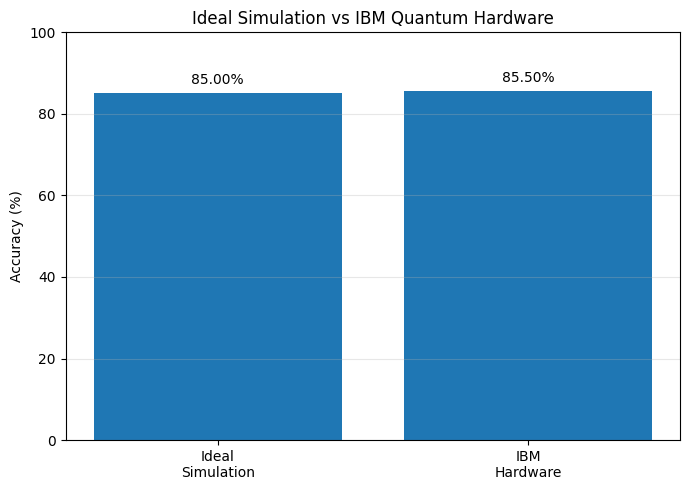


Saved: C:\Users\heart\quantum_6g_ai\results\figures\ibm_ideal_vs_hardware_accuracy.png


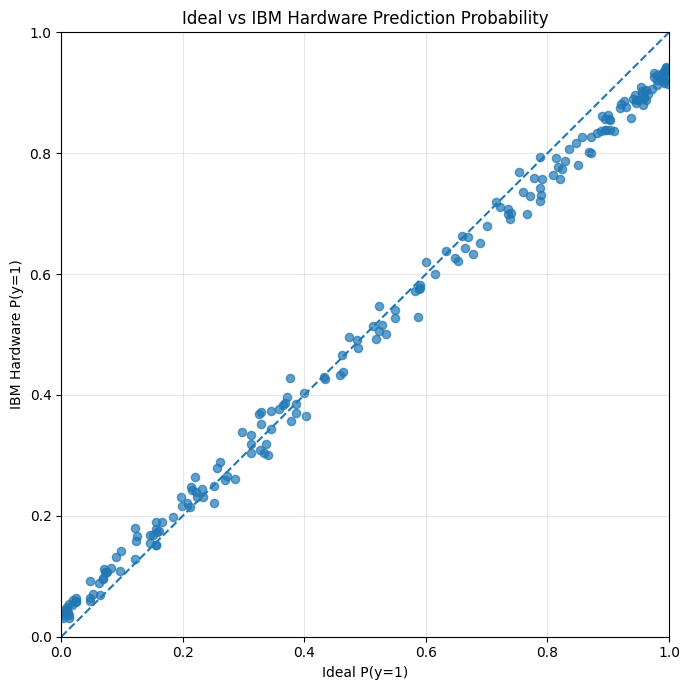

Saved: C:\Users\heart\quantum_6g_ai\results\figures\ibm_ideal_vs_hardware_probability.png


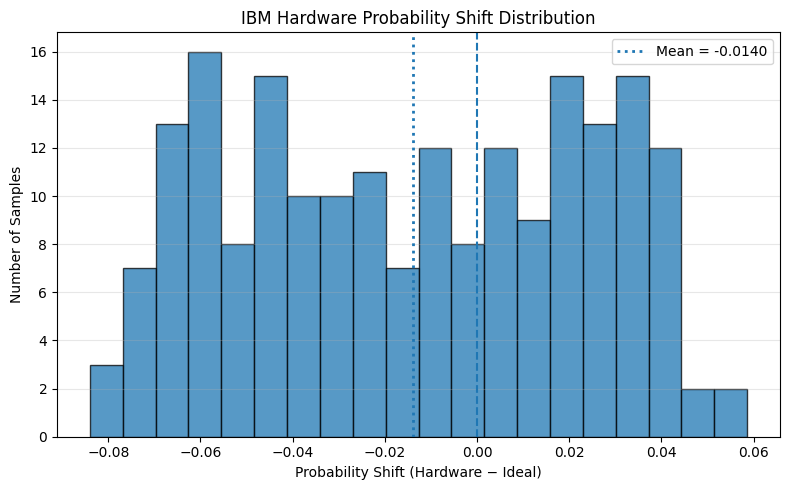

Saved: C:\Users\heart\quantum_6g_ai\results\figures\ibm_probability_shift_distribution.png


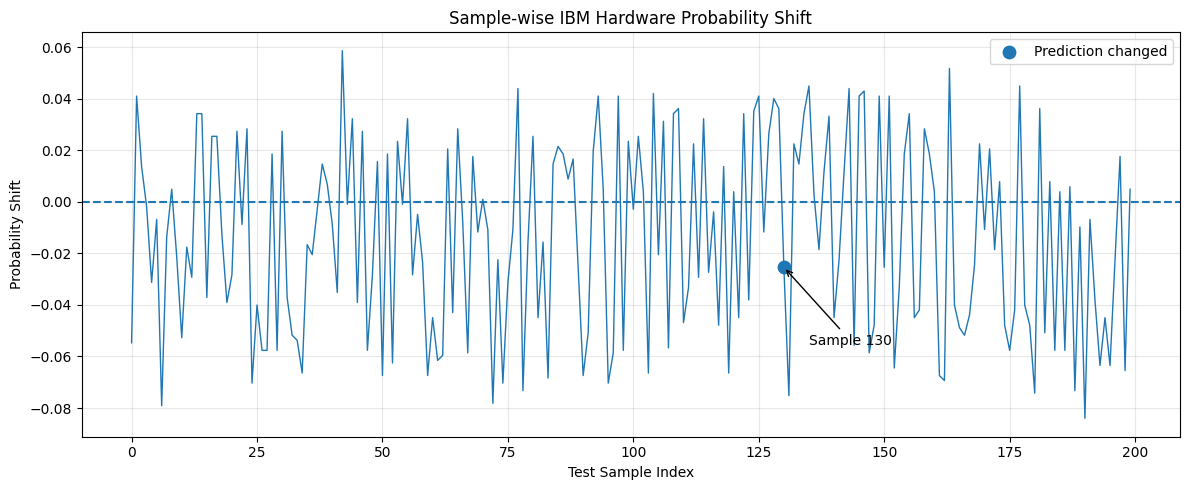

Saved: C:\Users\heart\quantum_6g_ai\results\figures\ibm_samplewise_probability_shift.png


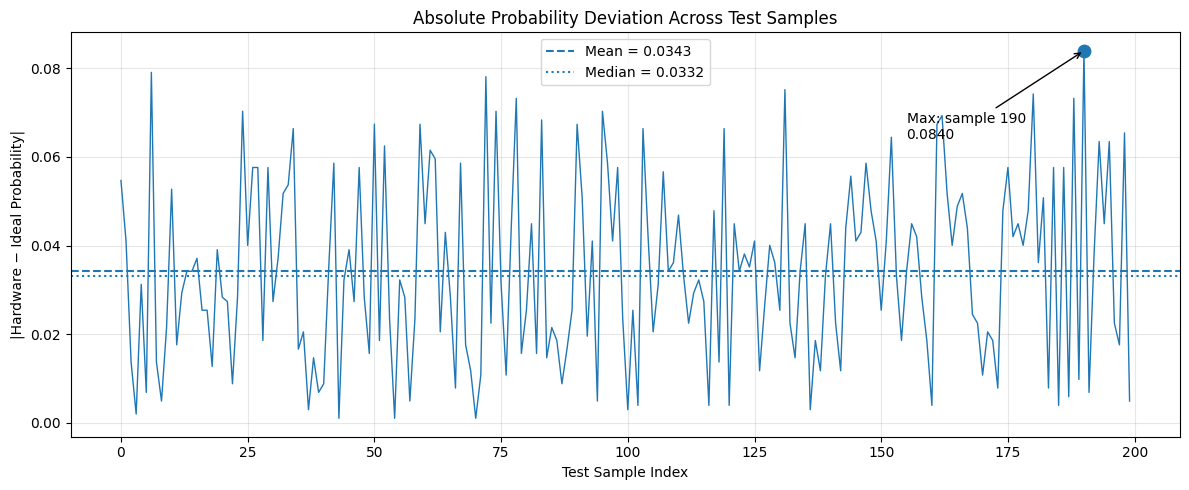

Saved: C:\Users\heart\quantum_6g_ai\results\figures\ibm_absolute_probability_shift.png


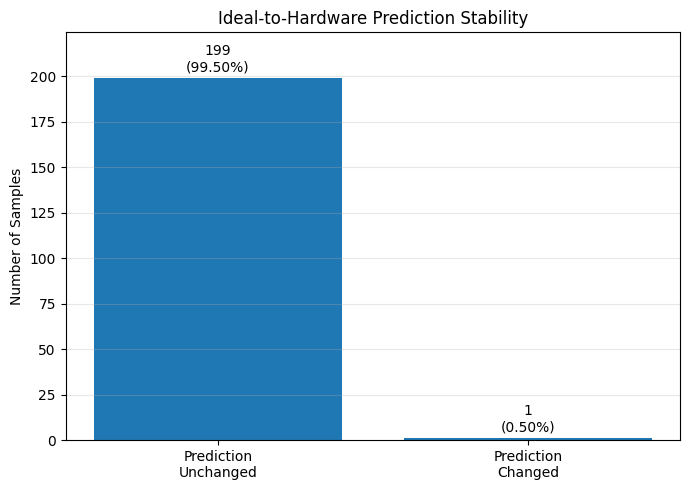

Saved: C:\Users\heart\quantum_6g_ai\results\figures\ibm_prediction_stability.png


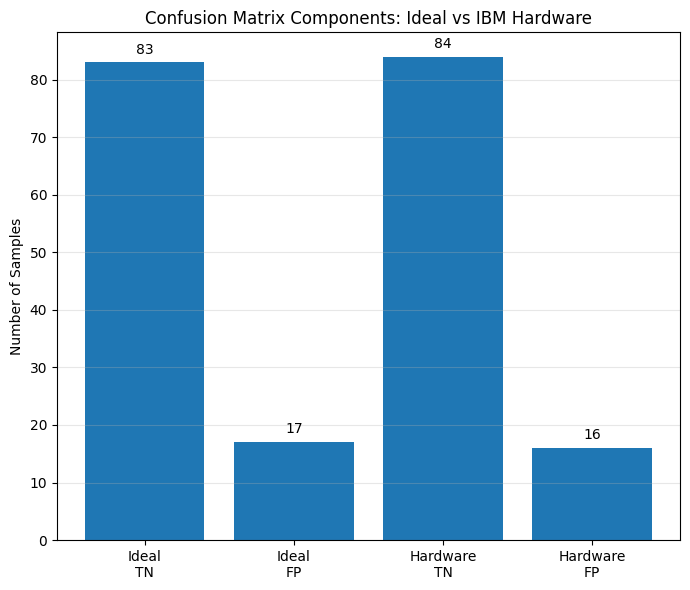

Saved: C:\Users\heart\quantum_6g_ai\results\figures\ibm_confusion_matrix_negative_class.png


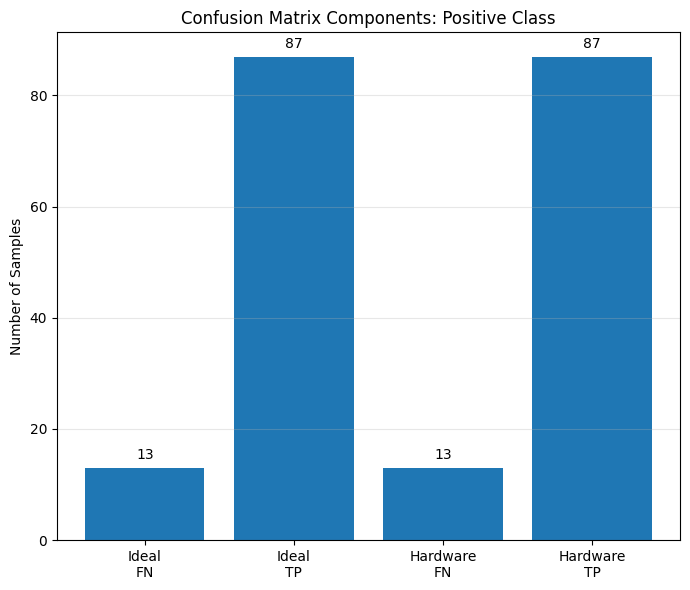

Saved: C:\Users\heart\quantum_6g_ai\results\figures\ibm_confusion_matrix_positive_class.png


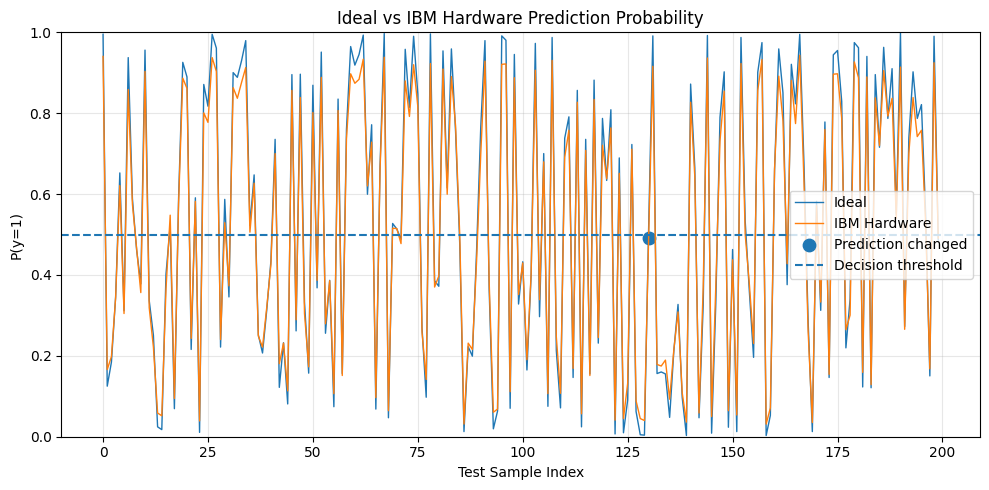

Saved: C:\Users\heart\quantum_6g_ai\results\figures\ibm_ideal_hardware_probability_by_sample.png

FIGURE GENERATION COMPLETE
PASS | ibm_ideal_vs_hardware_accuracy.png
PASS | ibm_ideal_vs_hardware_probability.png
PASS | ibm_probability_shift_distribution.png
PASS | ibm_samplewise_probability_shift.png
PASS | ibm_absolute_probability_shift.png
PASS | ibm_prediction_stability.png
PASS | ibm_confusion_matrix_negative_class.png
PASS | ibm_confusion_matrix_positive_class.png
PASS | ibm_ideal_hardware_probability_by_sample.png

Total figures: 9

Figures directory:
C:\Users\heart\quantum_6g_ai\results\figures

STATUS: IBM HARDWARE FIGURES COMPLETE


In [27]:
# ============================================================
# 09 — CELL 24
# IBM HARDWARE RESEARCH FIGURES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("=" * 70)
print("09 — CELL 24")
print("IBM HARDWARE RESEARCH FIGURES")
print("=" * 70)

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

full_results_csv = RESULTS_DIR / "hardware_full_results.csv"
figures_dir = RESULTS_DIR / "figures"

figures_dir.mkdir(parents=True, exist_ok=True)

assert full_results_csv.exists(), (
    f"Missing file: {full_results_csv}"
)

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

df = pd.read_csv(full_results_csv)

assert len(df) == 200

sample_index = df["sample_index"].to_numpy(dtype=int)
true_label = df["true_label"].to_numpy(dtype=int)

ideal_probability = df["ideal_probability"].to_numpy(dtype=float)
hardware_probability = df["hardware_probability"].to_numpy(dtype=float)

probability_shift = df["probability_shift"].to_numpy(dtype=float)
absolute_shift = df["absolute_probability_shift"].to_numpy(dtype=float)

ideal_prediction = df["ideal_prediction"].to_numpy(dtype=int)
hardware_prediction = df["hardware_prediction"].to_numpy(dtype=int)

prediction_changed = df["prediction_changed"].astype(bool).to_numpy()

ideal_correct = ideal_prediction == true_label
hardware_correct = hardware_prediction == true_label

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

ideal_accuracy = np.mean(ideal_correct)
hardware_accuracy = np.mean(hardware_correct)

prediction_change_count = np.sum(prediction_changed)
prediction_stability = 1.0 - prediction_change_count / len(df)

mean_abs_shift = np.mean(absolute_shift)
median_abs_shift = np.median(absolute_shift)
max_abs_shift = np.max(absolute_shift)

print("\nLoaded samples :", len(df))
print("Figures folder :", figures_dir)

print("\nMetrics")
print("-" * 50)
print(f"Ideal accuracy       : {ideal_accuracy:.4f}")
print(f"Hardware accuracy    : {hardware_accuracy:.4f}")
print(f"Accuracy difference  : {hardware_accuracy - ideal_accuracy:+.4f}")
print(f"Mean abs. shift      : {mean_abs_shift:.6f}")
print(f"Median abs. shift    : {median_abs_shift:.6f}")
print(f"Max abs. shift       : {max_abs_shift:.6f}")
print(f"Prediction changes   : {prediction_change_count}/200")
print(f"Prediction stability : {prediction_stability:.4f}")

# ============================================================
# FIGURE 1
# IDEAL VS IBM HARDWARE ACCURACY
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

labels = ["Ideal\nSimulation", "IBM\nHardware"]
values = [ideal_accuracy * 100, hardware_accuracy * 100]

ax.bar(labels, values)

ax.set_ylabel("Accuracy (%)")
ax.set_title("Ideal Simulation vs IBM Quantum Hardware")
ax.set_ylim(0, 100)

for i, value in enumerate(values):
    ax.text(
        i,
        value + 1.5,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

fig1 = figures_dir / "ibm_ideal_vs_hardware_accuracy.png"
fig.savefig(fig1, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print("\nSaved:", fig1)

# ============================================================
# FIGURE 2
# IDEAL VS HARDWARE PROBABILITY SCATTER
# ============================================================

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    ideal_probability,
    hardware_probability,
    alpha=0.7,
    s=35
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5
)

ax.set_xlabel("Ideal P(y=1)")
ax.set_ylabel("IBM Hardware P(y=1)")
ax.set_title("Ideal vs IBM Hardware Prediction Probability")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.grid(alpha=0.3)

fig.tight_layout()

fig2 = figures_dir / "ibm_ideal_vs_hardware_probability.png"
fig.savefig(fig2, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved:", fig2)

# ============================================================
# FIGURE 3
# PROBABILITY SHIFT HISTOGRAM
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    probability_shift,
    bins=20,
    edgecolor="black",
    alpha=0.75
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

ax.axvline(
    np.mean(probability_shift),
    linestyle=":",
    linewidth=2,
    label=f"Mean = {np.mean(probability_shift):+.4f}"
)

ax.set_xlabel("Probability Shift (Hardware − Ideal)")
ax.set_ylabel("Number of Samples")
ax.set_title("IBM Hardware Probability Shift Distribution")

ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

fig3 = figures_dir / "ibm_probability_shift_distribution.png"
fig.savefig(fig3, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved:", fig3)

# ============================================================
# FIGURE 4
# SAMPLE-WISE PROBABILITY SHIFT
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    sample_index,
    probability_shift,
    linewidth=1
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

changed_indices = sample_index[prediction_changed]

if len(changed_indices) > 0:

    changed_shifts = probability_shift[prediction_changed]

    ax.scatter(
        changed_indices,
        changed_shifts,
        s=80,
        marker="o",
        label="Prediction changed"
    )

    for x, y in zip(changed_indices, changed_shifts):

        ax.annotate(
            f"Sample {x}",
            xy=(x, y),
            xytext=(x + 5, y - 0.03),
            arrowprops=dict(arrowstyle="->"),
        )

ax.set_xlabel("Test Sample Index")
ax.set_ylabel("Probability Shift")
ax.set_title("Sample-wise IBM Hardware Probability Shift")

ax.grid(alpha=0.3)

if len(changed_indices) > 0:
    ax.legend()

fig.tight_layout()

fig4 = figures_dir / "ibm_samplewise_probability_shift.png"
fig.savefig(fig4, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved:", fig4)

# ============================================================
# FIGURE 5
# ABSOLUTE PROBABILITY SHIFT
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    sample_index,
    absolute_shift,
    linewidth=1
)

ax.axhline(
    mean_abs_shift,
    linestyle="--",
    linewidth=1.5,
    label=f"Mean = {mean_abs_shift:.4f}"
)

ax.axhline(
    median_abs_shift,
    linestyle=":",
    linewidth=1.5,
    label=f"Median = {median_abs_shift:.4f}"
)

max_index = sample_index[np.argmax(absolute_shift)]

ax.scatter(
    [max_index],
    [max_abs_shift],
    s=80,
    marker="o"
)

ax.annotate(
    f"Max: sample {max_index}\n{max_abs_shift:.4f}",
    xy=(max_index, max_abs_shift),
    xytext=(max_index - 35, max_abs_shift - 0.02),
    arrowprops=dict(arrowstyle="->")
)

ax.set_xlabel("Test Sample Index")
ax.set_ylabel("|Hardware − Ideal Probability|")
ax.set_title("Absolute Probability Deviation Across Test Samples")

ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()

fig5 = figures_dir / "ibm_absolute_probability_shift.png"
fig.savefig(fig5, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved:", fig5)

# ============================================================
# FIGURE 6
# PREDICTION STABILITY
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

unchanged = len(df) - prediction_change_count
changed = prediction_change_count

labels = [
    "Prediction\nUnchanged",
    "Prediction\nChanged"
]

values = [
    unchanged,
    changed
]

ax.bar(labels, values)

ax.set_ylabel("Number of Samples")
ax.set_title("Ideal-to-Hardware Prediction Stability")

for i, value in enumerate(values):

    ax.text(
        i,
        value + 2,
        f"{value}\n({value / len(df) * 100:.2f}%)",
        ha="center",
        va="bottom"
    )

ax.set_ylim(0, len(df) * 1.12)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

fig6 = figures_dir / "ibm_prediction_stability.png"
fig.savefig(fig6, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved:", fig6)

# ============================================================
# FIGURE 7
# CONFUSION MATRIX COMPARISON
# ============================================================

from sklearn.metrics import confusion_matrix

ideal_cm = confusion_matrix(
    true_label,
    ideal_prediction,
    labels=[0, 1]
)

hardware_cm = confusion_matrix(
    true_label,
    hardware_prediction,
    labels=[0, 1]
)

fig, ax = plt.subplots(figsize=(7, 6))

matrix_values = np.array([
    [
        ideal_cm[0, 0],
        ideal_cm[0, 1],
        hardware_cm[0, 0],
        hardware_cm[0, 1]
    ],
    [
        ideal_cm[1, 0],
        ideal_cm[1, 1],
        hardware_cm[1, 0],
        hardware_cm[1, 1]
    ]
])

# Show side-by-side confusion counts using grouped bars

x = np.arange(4)

cm_labels = [
    "Ideal\nTN",
    "Ideal\nFP",
    "Hardware\nTN",
    "Hardware\nFP"
]

values = [
    ideal_cm[0, 0],
    ideal_cm[0, 1],
    hardware_cm[0, 0],
    hardware_cm[0, 1]
]

ax.bar(x, values)

ax.set_xticks(x)
ax.set_xticklabels(cm_labels)

ax.set_ylabel("Number of Samples")
ax.set_title("Confusion Matrix Components: Ideal vs IBM Hardware")

for i, value in enumerate(values):

    ax.text(
        i,
        value + 1,
        str(value),
        ha="center",
        va="bottom"
    )

ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

fig7 = figures_dir / "ibm_confusion_matrix_negative_class.png"
fig.savefig(fig7, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved:", fig7)

# ------------------------------------------------------------
# SECOND CONFUSION COMPONENT FIGURE
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 6))

x = np.arange(4)

cm_labels = [
    "Ideal\nFN",
    "Ideal\nTP",
    "Hardware\nFN",
    "Hardware\nTP"
]

values = [
    ideal_cm[1, 0],
    ideal_cm[1, 1],
    hardware_cm[1, 0],
    hardware_cm[1, 1]
]

ax.bar(x, values)

ax.set_xticks(x)
ax.set_xticklabels(cm_labels)

ax.set_ylabel("Number of Samples")
ax.set_title("Confusion Matrix Components: Positive Class")

for i, value in enumerate(values):

    ax.text(
        i,
        value + 1,
        str(value),
        ha="center",
        va="bottom"
    )

ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

fig8 = figures_dir / "ibm_confusion_matrix_positive_class.png"
fig.savefig(fig8, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved:", fig8)

# ============================================================
# FIGURE 9
# IDEAL VS HARDWARE PROBABILITY CHANGE
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    sample_index,
    ideal_probability,
    linewidth=1,
    label="Ideal"
)

ax.plot(
    sample_index,
    hardware_probability,
    linewidth=1,
    label="IBM Hardware"
)

if len(changed_indices) > 0:

    ax.scatter(
        changed_indices,
        hardware_probability[prediction_changed],
        s=80,
        marker="o",
        label="Prediction changed"
    )

ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1.5,
    label="Decision threshold"
)

ax.set_xlabel("Test Sample Index")
ax.set_ylabel("P(y=1)")
ax.set_title("Ideal vs IBM Hardware Prediction Probability")

ax.set_ylim(0, 1)

ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()

fig9 = figures_dir / "ibm_ideal_hardware_probability_by_sample.png"
fig.savefig(fig9, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved:", fig9)

# ============================================================
# FINAL VALIDATION
# ============================================================

figure_files = [
    fig1,
    fig2,
    fig3,
    fig4,
    fig5,
    fig6,
    fig7,
    fig8,
    fig9
]

print("\n" + "=" * 70)
print("FIGURE GENERATION COMPLETE")
print("=" * 70)

for path in figure_files:
    print(
        f"{'PASS' if path.exists() else 'FAIL'} | {path.name}"
    )

print("\nTotal figures:", sum(path.exists() for path in figure_files))

print("\nFigures directory:")
print(figures_dir)

print("\nSTATUS: IBM HARDWARE FIGURES COMPLETE")

In [28]:
# ============================================================
# 09 — CELL 25
# STATISTICAL VALIDATION
# McNemar Test + Bootstrap Confidence Intervals
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.metrics import accuracy_score
from statsmodels.stats.contingency_tables import mcnemar

print("=" * 70)
print("09 — CELL 25")
print("STATISTICAL VALIDATION")
print("McNemar Test + Bootstrap 95% Confidence Intervals")
print("=" * 70)

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

full_results_csv = RESULTS_DIR / "hardware_full_results.csv"

statistical_results_csv = RESULTS_DIR / "hardware_statistical_validation.csv"
bootstrap_results_csv = RESULTS_DIR / "hardware_bootstrap_ci.csv"

assert full_results_csv.exists()

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

df = pd.read_csv(full_results_csv)

assert len(df) == 200
assert df["sample_index"].tolist() == list(range(200))

y_true = df["true_label"].to_numpy(dtype=int)

ideal_pred = df["ideal_prediction"].to_numpy(dtype=int)
hardware_pred = df["hardware_prediction"].to_numpy(dtype=int)

ideal_probability = df["ideal_probability"].to_numpy(dtype=float)
hardware_probability = df["hardware_probability"].to_numpy(dtype=float)

probability_shift = (
    hardware_probability - ideal_probability
)

absolute_probability_shift = np.abs(probability_shift)

# ------------------------------------------------------------
# BASIC ACCURACY
# ------------------------------------------------------------

ideal_correct = ideal_pred == y_true
hardware_correct = hardware_pred == y_true

ideal_accuracy = np.mean(ideal_correct)
hardware_accuracy = np.mean(hardware_correct)

observed_accuracy_difference = (
    hardware_accuracy - ideal_accuracy
)

print("\nBASIC PERFORMANCE")
print("-" * 50)

print(
    "Ideal accuracy        :",
    f"{ideal_accuracy:.4f}"
)

print(
    "Hardware accuracy     :",
    f"{hardware_accuracy:.4f}"
)

print(
    "Observed difference   :",
    f"{observed_accuracy_difference:+.4f}"
)

# ============================================================
# McNEMAR TEST
# ============================================================

# Discordant correctness table:
#
#                    Hardware
#                 Correct  Wrong
#
# Ideal Correct      a       b
# Ideal Wrong       c       d
#

a = int(np.sum(ideal_correct & hardware_correct))
b = int(np.sum(ideal_correct & ~hardware_correct))
c = int(np.sum(~ideal_correct & hardware_correct))
d = int(np.sum(~ideal_correct & ~hardware_correct))

mcnemar_table = np.array([
    [a, b],
    [c, d]
])

print("\n" + "=" * 70)
print("McNEMAR TEST")
print("=" * 70)

print("\nPaired correctness table")
print("-" * 50)

print("                         Hardware")
print("                    Correct    Wrong")
print(
    f"Ideal Correct       {a:7d}    {b:7d}"
)
print(
    f"Ideal Wrong         {c:7d}    {d:7d}"
)

discordant_total = b + c

print("\nDiscordant pairs :", discordant_total)

# ------------------------------------------------------------
# Exact McNemar test
# ------------------------------------------------------------

if discordant_total > 0:

    result_exact = mcnemar(
        mcnemar_table,
        exact=True,
        correction=False
    )

    mcnemar_statistic = result_exact.statistic
    mcnemar_pvalue = result_exact.pvalue

else:

    mcnemar_statistic = 0.0
    mcnemar_pvalue = 1.0

print(
    "McNemar statistic :",
    mcnemar_statistic
)

print(
    "Exact p-value     :",
    f"{mcnemar_pvalue:.6f}"
)

# ------------------------------------------------------------
# Interpretation flag
# ------------------------------------------------------------

alpha = 0.05

if mcnemar_pvalue < alpha:
    mcnemar_result = "Statistically significant at alpha=0.05"
else:
    mcnemar_result = "Not statistically significant at alpha=0.05"

print(
    "Result            :",
    mcnemar_result
)

# ============================================================
# BOOTSTRAP
# ============================================================

print("\n" + "=" * 70)
print("BOOTSTRAP 95% CONFIDENCE INTERVALS")
print("=" * 70)

N_BOOTSTRAP = 10000
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

n = len(df)

bootstrap_ideal_accuracy = np.empty(N_BOOTSTRAP)
bootstrap_hardware_accuracy = np.empty(N_BOOTSTRAP)
bootstrap_accuracy_difference = np.empty(N_BOOTSTRAP)

bootstrap_mean_shift = np.empty(N_BOOTSTRAP)
bootstrap_mean_abs_shift = np.empty(N_BOOTSTRAP)

for i in range(N_BOOTSTRAP):

    indices = rng.integers(
        0,
        n,
        size=n
    )

    sample_true = y_true[indices]

    sample_ideal_pred = ideal_pred[indices]
    sample_hardware_pred = hardware_pred[indices]

    sample_shift = probability_shift[indices]
    sample_abs_shift = absolute_probability_shift[indices]

    sample_ideal_accuracy = np.mean(
        sample_ideal_pred == sample_true
    )

    sample_hardware_accuracy = np.mean(
        sample_hardware_pred == sample_true
    )

    bootstrap_ideal_accuracy[i] = (
        sample_ideal_accuracy
    )

    bootstrap_hardware_accuracy[i] = (
        sample_hardware_accuracy
    )

    bootstrap_accuracy_difference[i] = (
        sample_hardware_accuracy
        - sample_ideal_accuracy
    )

    bootstrap_mean_shift[i] = np.mean(
        sample_shift
    )

    bootstrap_mean_abs_shift[i] = np.mean(
        sample_abs_shift
    )

# ------------------------------------------------------------
# CI helper
# ------------------------------------------------------------

def percentile_ci(values, confidence=0.95):

    alpha_tail = (1.0 - confidence) / 2.0

    lower = np.percentile(
        values,
        100 * alpha_tail
    )

    upper = np.percentile(
        values,
        100 * (1 - alpha_tail)
    )

    return lower, upper

# ------------------------------------------------------------
# Calculate CIs
# ------------------------------------------------------------

ideal_acc_ci = percentile_ci(
    bootstrap_ideal_accuracy
)

hardware_acc_ci = percentile_ci(
    bootstrap_hardware_accuracy
)

accuracy_diff_ci = percentile_ci(
    bootstrap_accuracy_difference
)

mean_shift_ci = percentile_ci(
    bootstrap_mean_shift
)

mean_abs_shift_ci = percentile_ci(
    bootstrap_mean_abs_shift
)

# ============================================================
# PRINT RESULTS
# ============================================================

print("\nACCURACY")
print("-" * 60)

print(
    f"Ideal accuracy       : "
    f"{ideal_accuracy:.4f} "
    f"[95% CI "
    f"{ideal_acc_ci[0]:.4f}, "
    f"{ideal_acc_ci[1]:.4f}]"
)

print(
    f"Hardware accuracy    : "
    f"{hardware_accuracy:.4f} "
    f"[95% CI "
    f"{hardware_acc_ci[0]:.4f}, "
    f"{hardware_acc_ci[1]:.4f}]"
)

print(
    f"Accuracy difference  : "
    f"{observed_accuracy_difference:+.4f} "
    f"[95% CI "
    f"{accuracy_diff_ci[0]:+.4f}, "
    f"{accuracy_diff_ci[1]:+.4f}]"
)

print("\nPROBABILITY SHIFT")
print("-" * 60)

print(
    f"Mean probability shift : "
    f"{np.mean(probability_shift):+.6f} "
    f"[95% CI "
    f"{mean_shift_ci[0]:+.6f}, "
    f"{mean_shift_ci[1]:+.6f}]"
)

print(
    f"Mean absolute shift    : "
    f"{np.mean(absolute_probability_shift):.6f} "
    f"[95% CI "
    f"{mean_abs_shift_ci[0]:.6f}, "
    f"{mean_abs_shift_ci[1]:.6f}]"
)

# ============================================================
# PREDICTION AGREEMENT
# ============================================================

prediction_changed = ideal_pred != hardware_pred

prediction_change_count = int(
    np.sum(prediction_changed)
)

prediction_change_rate = (
    prediction_change_count / n
)

prediction_stability = (
    1.0 - prediction_change_rate
)

print("\nPREDICTION AGREEMENT")
print("-" * 60)

print(
    "Prediction changes   :",
    prediction_change_count,
    "/",
    n
)

print(
    "Change rate          :",
    f"{prediction_change_rate:.4f}"
)

print(
    "Prediction stability :",
    f"{prediction_stability:.4f}"
)

# ============================================================
# EFFECTIVE DISCORDANCE
# ============================================================

print("\nCORRECTNESS TRANSITIONS")
print("-" * 60)

print(
    "Ideal correct → HW wrong :",
    b
)

print(
    "Ideal wrong → HW correct :",
    c
)

print(
    "Net correctness change   :",
    c - b
)

# ============================================================
# SAVE STATISTICAL SUMMARY
# ============================================================

statistical_records = [

    {
        "metric": "sample_count",
        "value": n
    },

    {
        "metric": "ideal_accuracy",
        "value": ideal_accuracy
    },

    {
        "metric": "ideal_accuracy_ci_lower",
        "value": ideal_acc_ci[0]
    },

    {
        "metric": "ideal_accuracy_ci_upper",
        "value": ideal_acc_ci[1]
    },

    {
        "metric": "hardware_accuracy",
        "value": hardware_accuracy
    },

    {
        "metric": "hardware_accuracy_ci_lower",
        "value": hardware_acc_ci[0]
    },

    {
        "metric": "hardware_accuracy_ci_upper",
        "value": hardware_acc_ci[1]
    },

    {
        "metric": "accuracy_difference",
        "value": observed_accuracy_difference
    },

    {
        "metric": "accuracy_difference_ci_lower",
        "value": accuracy_diff_ci[0]
    },

    {
        "metric": "accuracy_difference_ci_upper",
        "value": accuracy_diff_ci[1]
    },

    {
        "metric": "mcnemar_statistic",
        "value": mcnemar_statistic
    },

    {
        "metric": "mcnemar_exact_pvalue",
        "value": mcnemar_pvalue
    },

    {
        "metric": "discordant_pairs",
        "value": discordant_total
    },

    {
        "metric": "ideal_correct_hardware_wrong",
        "value": b
    },

    {
        "metric": "ideal_wrong_hardware_correct",
        "value": c
    },

    {
        "metric": "mean_probability_shift",
        "value": np.mean(probability_shift)
    },

    {
        "metric": "mean_probability_shift_ci_lower",
        "value": mean_shift_ci[0]
    },

    {
        "metric": "mean_probability_shift_ci_upper",
        "value": mean_shift_ci[1]
    },

    {
        "metric": "mean_absolute_probability_shift",
        "value": np.mean(absolute_probability_shift)
    },

    {
        "metric": "mean_absolute_shift_ci_lower",
        "value": mean_abs_shift_ci[0]
    },

    {
        "metric": "mean_absolute_shift_ci_upper",
        "value": mean_abs_shift_ci[1]
    },

    {
        "metric": "prediction_change_count",
        "value": prediction_change_count
    },

    {
        "metric": "prediction_change_rate",
        "value": prediction_change_rate
    },

    {
        "metric": "prediction_stability",
        "value": prediction_stability
    }
]

statistical_df = pd.DataFrame(
    statistical_records
)

statistical_df.to_csv(
    statistical_results_csv,
    index=False
)

# ============================================================
# SAVE BOOTSTRAP DISTRIBUTION SUMMARY
# ============================================================

bootstrap_summary = pd.DataFrame([

    {
        "metric": "ideal_accuracy",
        "observed": ideal_accuracy,
        "ci_lower": ideal_acc_ci[0],
        "ci_upper": ideal_acc_ci[1]
    },

    {
        "metric": "hardware_accuracy",
        "observed": hardware_accuracy,
        "ci_lower": hardware_acc_ci[0],
        "ci_upper": hardware_acc_ci[1]
    },

    {
        "metric": "accuracy_difference",
        "observed": observed_accuracy_difference,
        "ci_lower": accuracy_diff_ci[0],
        "ci_upper": accuracy_diff_ci[1]
    },

    {
        "metric": "mean_probability_shift",
        "observed": np.mean(probability_shift),
        "ci_lower": mean_shift_ci[0],
        "ci_upper": mean_shift_ci[1]
    },

    {
        "metric": "mean_absolute_probability_shift",
        "observed": np.mean(absolute_probability_shift),
        "ci_lower": mean_abs_shift_ci[0],
        "ci_upper": mean_abs_shift_ci[1]
    }

])

bootstrap_summary.to_csv(
    bootstrap_results_csv,
    index=False
)

# ============================================================
# FINAL VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("STATISTICAL VALIDATION FILES")
print("=" * 70)

print(
    "Statistical summary :",
    statistical_results_csv
)

print(
    "Bootstrap summary   :",
    bootstrap_results_csv
)

print("\nValidation:")
print(
    "Statistical summary exists:",
    statistical_results_csv.exists()
)

print(
    "Bootstrap summary exists   :",
    bootstrap_results_csv.exists()
)

print("\n" + "=" * 70)
print("STATUS: STATISTICAL VALIDATION COMPLETE")
print("=" * 70)

09 — CELL 25
STATISTICAL VALIDATION
McNemar Test + Bootstrap 95% Confidence Intervals

BASIC PERFORMANCE
--------------------------------------------------
Ideal accuracy        : 0.8500
Hardware accuracy     : 0.8550
Observed difference   : +0.0050

McNEMAR TEST

Paired correctness table
--------------------------------------------------
                         Hardware
                    Correct    Wrong
Ideal Correct           170          0
Ideal Wrong               1         29

Discordant pairs : 1
McNemar statistic : 0.0
Exact p-value     : 1.000000
Result            : Not statistically significant at alpha=0.05

BOOTSTRAP 95% CONFIDENCE INTERVALS

ACCURACY
------------------------------------------------------------
Ideal accuracy       : 0.8500 [95% CI 0.8000, 0.9000]
Hardware accuracy    : 0.8550 [95% CI 0.8050, 0.9000]
Accuracy difference  : +0.0050 [95% CI +0.0000, +0.0150]

PROBABILITY SHIFT
------------------------------------------------------------
Mean probability sh

09 — CELL 26
FINAL STATISTICAL VALIDATION FIGURES


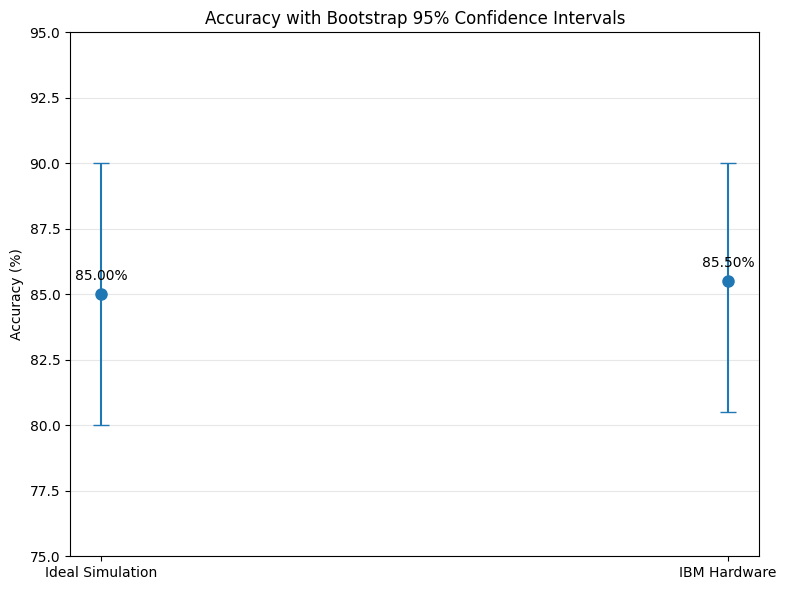


Saved: C:\Users\heart\quantum_6g_ai\results\figures\ibm_accuracy_bootstrap_95ci.png


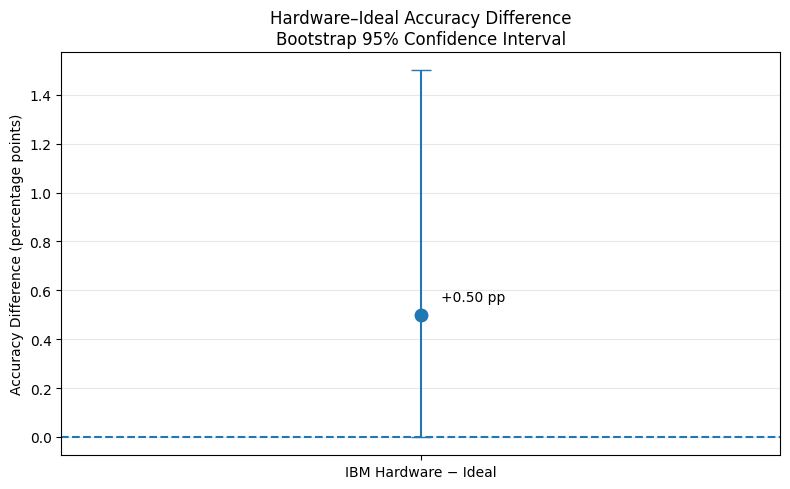

Saved: C:\Users\heart\quantum_6g_ai\results\figures\ibm_accuracy_difference_bootstrap_95ci.png


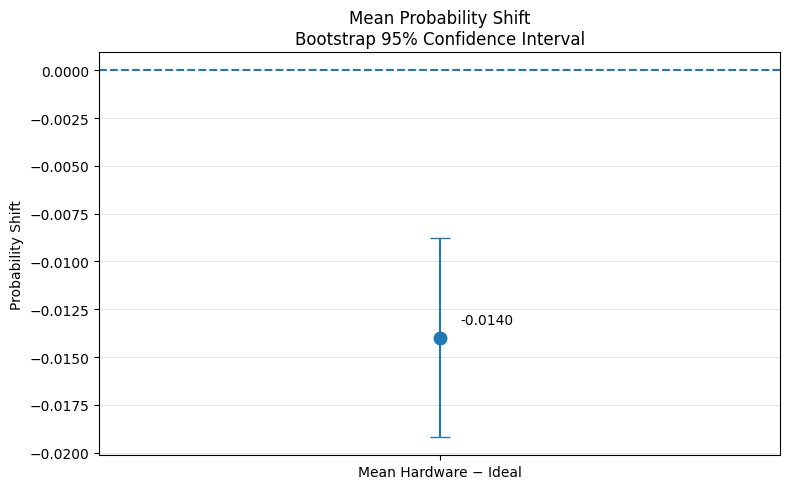

Saved: C:\Users\heart\quantum_6g_ai\results\figures\ibm_mean_probability_shift_bootstrap_95ci.png


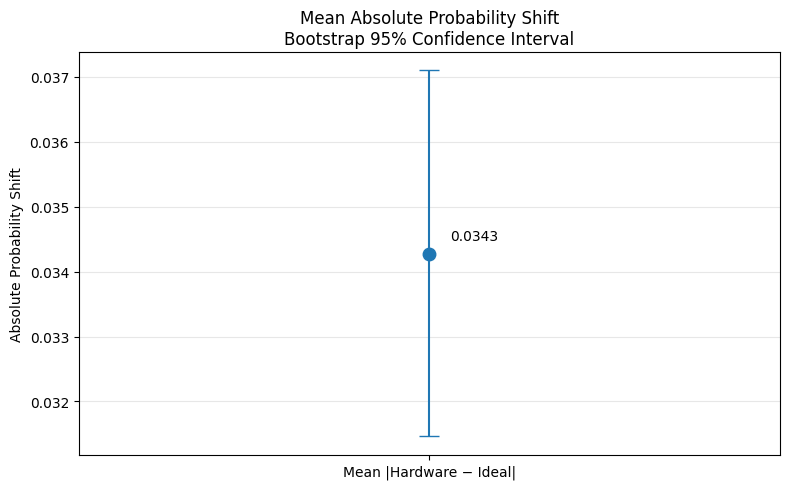

Saved: C:\Users\heart\quantum_6g_ai\results\figures\ibm_mean_absolute_shift_bootstrap_95ci.png


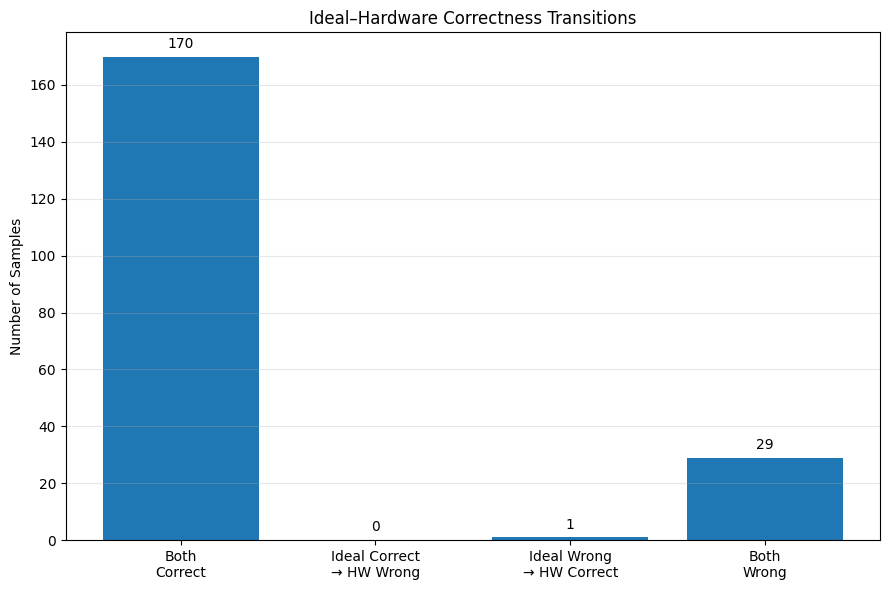

Saved: C:\Users\heart\quantum_6g_ai\results\figures\ibm_correctness_transition_analysis.png


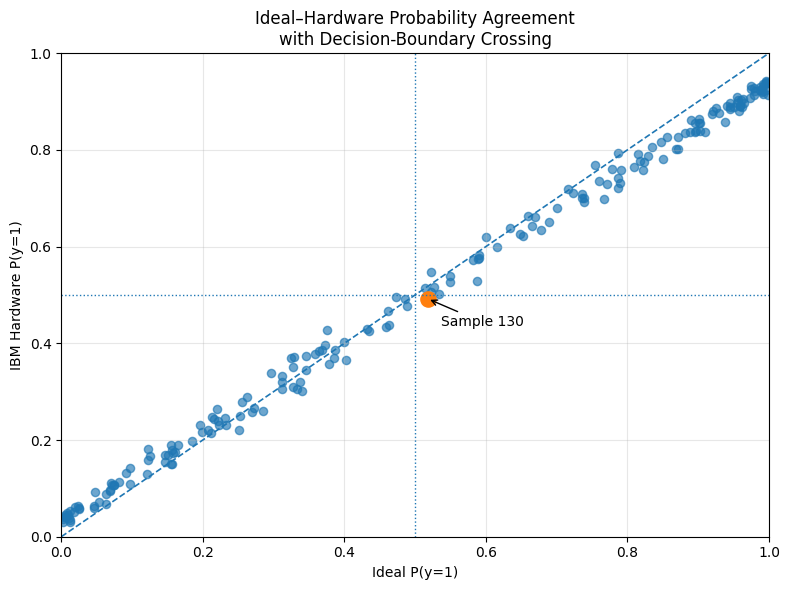

Saved: C:\Users\heart\quantum_6g_ai\results\figures\ibm_probability_decision_boundary_analysis.png

FINAL STATISTICAL FIGURES
PASS | ibm_accuracy_bootstrap_95ci.png
PASS | ibm_accuracy_difference_bootstrap_95ci.png
PASS | ibm_mean_probability_shift_bootstrap_95ci.png
PASS | ibm_mean_absolute_shift_bootstrap_95ci.png
PASS | ibm_correctness_transition_analysis.png
PASS | ibm_probability_decision_boundary_analysis.png

Total statistical figures: 6

Figures directory: C:\Users\heart\quantum_6g_ai\results\figures

STATUS: STATISTICAL FIGURES COMPLETE


In [29]:
# ============================================================
# 09 — CELL 26
# FINAL STATISTICAL VALIDATION FIGURES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("=" * 70)
print("09 — CELL 26")
print("FINAL STATISTICAL VALIDATION FIGURES")
print("=" * 70)

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

full_results_csv = RESULTS_DIR / "hardware_full_results.csv"
statistical_csv = RESULTS_DIR / "hardware_statistical_validation.csv"
bootstrap_csv = RESULTS_DIR / "hardware_bootstrap_ci.csv"

figures_dir = RESULTS_DIR / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

assert full_results_csv.exists()
assert statistical_csv.exists()
assert bootstrap_csv.exists()

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

df = pd.read_csv(full_results_csv)
stats_df = pd.read_csv(statistical_csv)
bootstrap_df = pd.read_csv(bootstrap_csv)

assert len(df) == 200

y_true = df["true_label"].to_numpy(dtype=int)

ideal_pred = df["ideal_prediction"].to_numpy(dtype=int)
hardware_pred = df["hardware_prediction"].to_numpy(dtype=int)

ideal_probability = df["ideal_probability"].to_numpy(dtype=float)
hardware_probability = df["hardware_probability"].to_numpy(dtype=float)

probability_shift = (
    hardware_probability - ideal_probability
)

absolute_shift = np.abs(probability_shift)

prediction_changed = (
    ideal_pred != hardware_pred
)

ideal_correct = (
    ideal_pred == y_true
)

hardware_correct = (
    hardware_pred == y_true
)

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

ideal_accuracy = np.mean(ideal_correct)
hardware_accuracy = np.mean(hardware_correct)

accuracy_difference = (
    hardware_accuracy - ideal_accuracy
)

mean_shift = np.mean(probability_shift)
mean_abs_shift = np.mean(absolute_shift)

prediction_change_count = int(
    np.sum(prediction_changed)
)

prediction_stability = (
    1 - prediction_change_count / len(df)
)

# ------------------------------------------------------------
# EXTRACT CIs
# ------------------------------------------------------------

def get_metric_ci(metric_name):

    row = bootstrap_df[
        bootstrap_df["metric"] == metric_name
    ]

    assert len(row) == 1

    row = row.iloc[0]

    return (
        float(row["ci_lower"]),
        float(row["ci_upper"])
    )

ideal_ci = get_metric_ci(
    "ideal_accuracy"
)

hardware_ci = get_metric_ci(
    "hardware_accuracy"
)

difference_ci = get_metric_ci(
    "accuracy_difference"
)

mean_shift_ci = get_metric_ci(
    "mean_probability_shift"
)

mean_abs_shift_ci = get_metric_ci(
    "mean_absolute_probability_shift"
)

# ============================================================
# FIGURE 1
# ACCURACY WITH 95% CI
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

labels = [
    "Ideal Simulation",
    "IBM Hardware"
]

values = np.array([
    ideal_accuracy,
    hardware_accuracy
])

lower_errors = np.array([
    ideal_accuracy - ideal_ci[0],
    hardware_accuracy - hardware_ci[0]
])

upper_errors = np.array([
    ideal_ci[1] - ideal_accuracy,
    hardware_ci[1] - hardware_accuracy
])

yerr = np.vstack([
    lower_errors,
    upper_errors
])

x = np.arange(len(labels))

ax.errorbar(
    x,
    values * 100,
    yerr=yerr * 100,
    fmt="o",
    capsize=6,
    markersize=8,
    linewidth=1.5
)

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy with Bootstrap 95% Confidence Intervals")

ax.set_ylim(
    max(0, (min(ideal_ci[0], hardware_ci[0]) - 0.05) * 100),
    min(1, (max(ideal_ci[1], hardware_ci[1]) + 0.05)) * 100
)

ax.grid(axis="y", alpha=0.3)

for i, value in enumerate(values):

    ax.annotate(
        f"{value * 100:.2f}%",
        xy=(x[i], value * 100),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center"
    )

fig.tight_layout()

fig1 = figures_dir / (
    "ibm_accuracy_bootstrap_95ci.png"
)

fig.savefig(
    fig1,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("\nSaved:", fig1)

# ============================================================
# FIGURE 2
# ACCURACY DIFFERENCE CI
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

difference_percent = accuracy_difference * 100
difference_lower = difference_ci[0] * 100
difference_upper = difference_ci[1] * 100

ax.errorbar(
    [0],
    [difference_percent],
    yerr=[
        [difference_percent - difference_lower],
        [difference_upper - difference_percent]
    ],
    fmt="o",
    capsize=7,
    markersize=9,
    linewidth=1.5
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

ax.set_xticks([0])
ax.set_xticklabels(
    ["IBM Hardware − Ideal"]
)

ax.set_ylabel("Accuracy Difference (percentage points)")

ax.set_title(
    "Hardware–Ideal Accuracy Difference\n"
    "Bootstrap 95% Confidence Interval"
)

ax.grid(axis="y", alpha=0.3)

ax.annotate(
    f"{difference_percent:+.2f} pp",
    xy=(0, difference_percent),
    xytext=(15, 10),
    textcoords="offset points"
)

fig.tight_layout()

fig2 = figures_dir / (
    "ibm_accuracy_difference_bootstrap_95ci.png"
)

fig.savefig(
    fig2,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Saved:", fig2)

# ============================================================
# FIGURE 3
# MEAN PROBABILITY SHIFT WITH 95% CI
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    [0],
    [mean_shift],
    yerr=[
        [mean_shift - mean_shift_ci[0]],
        [mean_shift_ci[1] - mean_shift]
    ],
    fmt="o",
    capsize=7,
    markersize=9,
    linewidth=1.5
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

ax.set_xticks([0])
ax.set_xticklabels(
    ["Mean Hardware − Ideal"]
)

ax.set_ylabel("Probability Shift")

ax.set_title(
    "Mean Probability Shift\n"
    "Bootstrap 95% Confidence Interval"
)

ax.grid(axis="y", alpha=0.3)

ax.annotate(
    f"{mean_shift:+.4f}",
    xy=(0, mean_shift),
    xytext=(15, 10),
    textcoords="offset points"
)

fig.tight_layout()

fig3 = figures_dir / (
    "ibm_mean_probability_shift_bootstrap_95ci.png"
)

fig.savefig(
    fig3,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Saved:", fig3)

# ============================================================
# FIGURE 4
# MEAN ABSOLUTE PROBABILITY SHIFT WITH 95% CI
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    [0],
    [mean_abs_shift],
    yerr=[
        [mean_abs_shift - mean_abs_shift_ci[0]],
        [mean_abs_shift_ci[1] - mean_abs_shift]
    ],
    fmt="o",
    capsize=7,
    markersize=9,
    linewidth=1.5
)

ax.set_xticks([0])
ax.set_xticklabels(
    ["Mean |Hardware − Ideal|"]
)

ax.set_ylabel("Absolute Probability Shift")

ax.set_title(
    "Mean Absolute Probability Shift\n"
    "Bootstrap 95% Confidence Interval"
)

ax.grid(axis="y", alpha=0.3)

ax.annotate(
    f"{mean_abs_shift:.4f}",
    xy=(0, mean_abs_shift),
    xytext=(15, 10),
    textcoords="offset points"
)

fig.tight_layout()

fig4 = figures_dir / (
    "ibm_mean_absolute_shift_bootstrap_95ci.png"
)

fig.savefig(
    fig4,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Saved:", fig4)

# ============================================================
# FIGURE 5
# IDEAL / HARDWARE CORRECTNESS TRANSITIONS
# ============================================================

ideal_correct_hardware_correct = np.sum(
    ideal_correct & hardware_correct
)

ideal_correct_hardware_wrong = np.sum(
    ideal_correct & ~hardware_correct
)

ideal_wrong_hardware_correct = np.sum(
    ~ideal_correct & hardware_correct
)

both_wrong = np.sum(
    ~ideal_correct & ~hardware_correct
)

transition_labels = [
    "Both\nCorrect",
    "Ideal Correct\n→ HW Wrong",
    "Ideal Wrong\n→ HW Correct",
    "Both\nWrong"
]

transition_values = [
    ideal_correct_hardware_correct,
    ideal_correct_hardware_wrong,
    ideal_wrong_hardware_correct,
    both_wrong
]

fig, ax = plt.subplots(figsize=(9, 6))

x = np.arange(len(transition_labels))

ax.bar(
    x,
    transition_values
)

ax.set_xticks(x)
ax.set_xticklabels(transition_labels)

ax.set_ylabel("Number of Samples")

ax.set_title(
    "Ideal–Hardware Correctness Transitions"
)

for i, value in enumerate(transition_values):

    ax.text(
        i,
        value + 2,
        str(int(value)),
        ha="center",
        va="bottom"
    )

ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

fig5 = figures_dir / (
    "ibm_correctness_transition_analysis.png"
)

fig.savefig(
    fig5,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Saved:", fig5)

# ============================================================
# FIGURE 6
# DECISION BOUNDARY CASE
# ============================================================

changed_indices = np.where(
    prediction_changed
)[0]

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    ideal_probability,
    hardware_probability,
    alpha=0.65,
    s=35
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.2
)

if len(changed_indices) > 0:

    ax.scatter(
        ideal_probability[changed_indices],
        hardware_probability[changed_indices],
        s=120,
        marker="o"
    )

    for index in changed_indices:

        ax.annotate(
            f"Sample {sample_index[index]}",
            xy=(
                ideal_probability[index],
                hardware_probability[index]
            ),
            xytext=(10, -20),
            textcoords="offset points",
            arrowprops=dict(
                arrowstyle="->"
            )
        )

ax.axvline(
    0.5,
    linestyle=":",
    linewidth=1
)

ax.axhline(
    0.5,
    linestyle=":",
    linewidth=1
)

ax.set_xlabel("Ideal P(y=1)")
ax.set_ylabel("IBM Hardware P(y=1)")

ax.set_title(
    "Ideal–Hardware Probability Agreement\n"
    "with Decision-Boundary Crossing"
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.grid(alpha=0.3)

fig.tight_layout()

fig6 = figures_dir / (
    "ibm_probability_decision_boundary_analysis.png"
)

fig.savefig(
    fig6,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Saved:", fig6)

# ============================================================
# FINAL FILE CHECK
# ============================================================

final_figures = [
    fig1,
    fig2,
    fig3,
    fig4,
    fig5,
    fig6
]

print("\n" + "=" * 70)
print("FINAL STATISTICAL FIGURES")
print("=" * 70)

for path in final_figures:

    status = "PASS" if path.exists() else "FAIL"

    print(
        f"{status} | {path.name}"
    )

print(
    "\nTotal statistical figures:",
    sum(path.exists() for path in final_figures)
)

print(
    "\nFigures directory:",
    figures_dir
)

print("\nSTATUS: STATISTICAL FIGURES COMPLETE")

09 — CELL 27
MASTER EXPERIMENTAL COMPARISON
IDEAL vs NOISY vs IBM HARDWARE

INPUT FILES
--------------------------------------------------
PASS | C:\Users\heart\quantum_6g_ai\results\ideal_results.csv
PASS | C:\Users\heart\quantum_6g_ai\results\noisy_results.csv
PASS | C:\Users\heart\quantum_6g_ai\results\hardware_full_results.csv

Ideal results shape: (200, 3)
Noisy results shape : (200, 11)
Noisy columns: ['True_Label', 'Ideal_Probability', 'Ideal_Prediction', 'bit_flip_Probability', 'bit_flip_Prediction', 'phase_flip_Probability', 'phase_flip_Prediction', 'depolarizing_Probability', 'depolarizing_Prediction', 'readout_Probability', 'readout_Prediction']

Noise result preview:
 True_Label  Ideal_Probability  Ideal_Prediction  bit_flip_Probability  bit_flip_Prediction  phase_flip_Probability  phase_flip_Prediction  depolarizing_Probability  depolarizing_Prediction  readout_Probability  readout_Prediction
          1           0.995117                 1              0.933594           

,condition,accuracy,precision,recall,f1,mean_probability_shift,mean_absolute_probability_shift,prediction_change_rate_vs_ideal,sample_count
0,Ideal Simulation,0.850,0.836538,0.87,0.852941,0.000000,0.000000,0.000,200
1,IBM Hardware,0.855,0.844660,0.87,0.857143,-0.013999,0.034272,0.005,200



Saved master comparison: C:\Users\heart\quantum_6g_ai\results\master_experimental_comparison.csv


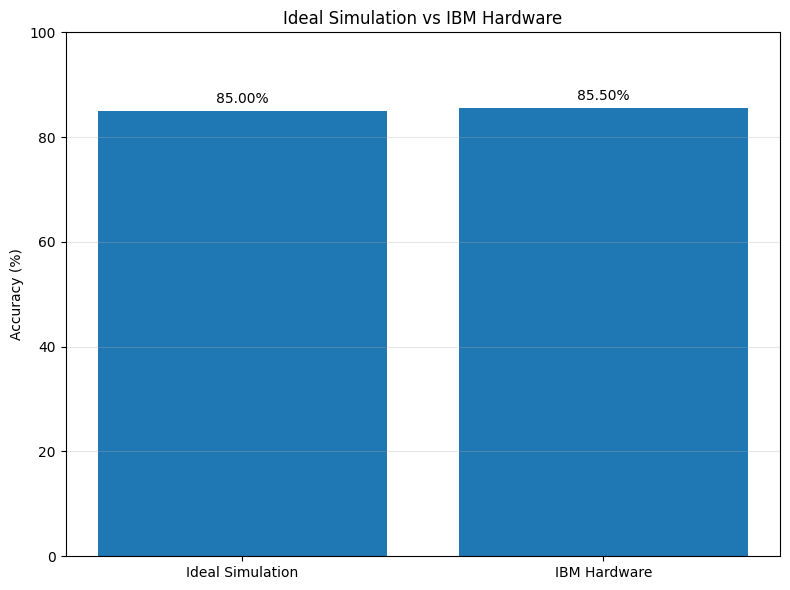

Saved: C:\Users\heart\quantum_6g_ai\results\figures\master_ideal_vs_hardware_accuracy.png


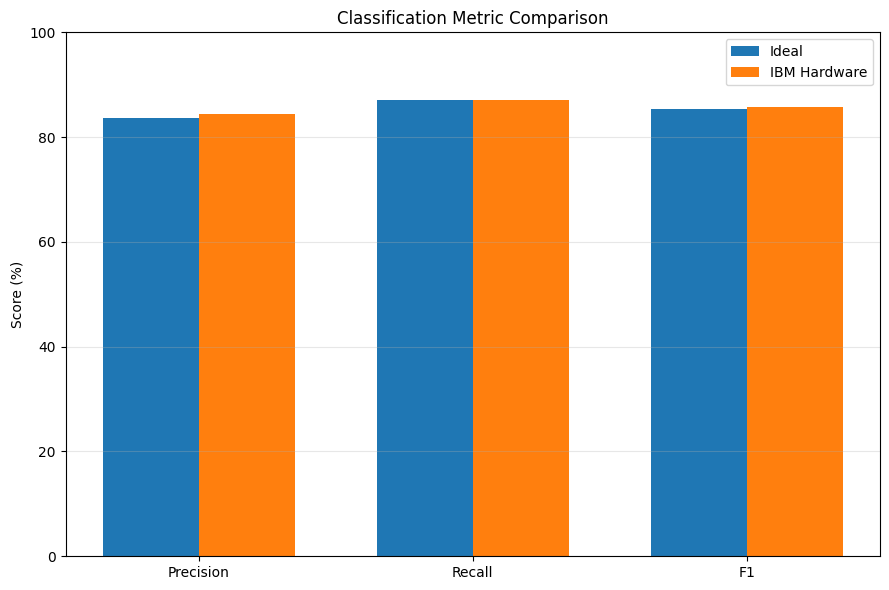

Saved: C:\Users\heart\quantum_6g_ai\results\figures\master_classification_metrics.png


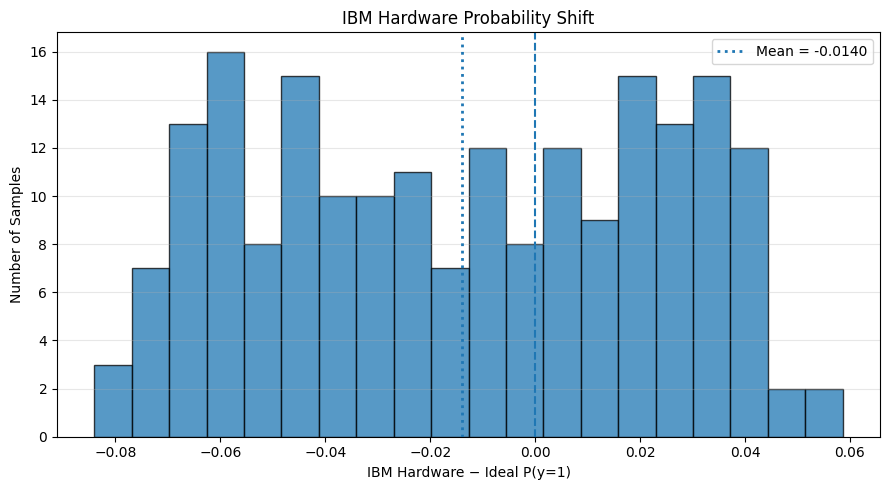

Saved: C:\Users\heart\quantum_6g_ai\results\figures\master_hardware_probability_shift.png

MASTER COMPARISON COMPLETE
Ideal accuracy    : 0.8500
Hardware accuracy : 0.8550
Difference        : +0.0050
Prediction change : 0.0050

Master table: C:\Users\heart\quantum_6g_ai\results\master_experimental_comparison.csv

STATUS: MASTER EXPERIMENTAL COMPARISON COMPLETE


In [30]:
# ============================================================
# 09 — CELL 27
# MASTER EXPERIMENTAL COMPARISON
# IDEAL vs NOISY vs IBM HARDWARE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 70)
print("09 — CELL 27")
print("MASTER EXPERIMENTAL COMPARISON")
print("IDEAL vs NOISY vs IBM HARDWARE")
print("=" * 70)

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

ideal_csv = RESULTS_DIR / "ideal_results.csv"
noisy_csv = RESULTS_DIR / "noisy_results.csv"
hardware_csv = RESULTS_DIR / "hardware_full_results.csv"

master_csv = RESULTS_DIR / "master_experimental_comparison.csv"

figures_dir = RESULTS_DIR / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# CHECK FILES
# ------------------------------------------------------------

print("\nINPUT FILES")
print("-" * 50)

for path in [
    ideal_csv,
    noisy_csv,
    hardware_csv
]:

    print(
        ("PASS" if path.exists() else "FAIL"),
        "|",
        path
    )

assert ideal_csv.exists()
assert noisy_csv.exists()
assert hardware_csv.exists()

# ============================================================
# LOAD IDEAL RESULTS
# ============================================================

ideal_df = pd.read_csv(
    ideal_csv
)

print("\nIdeal results shape:", ideal_df.shape)

# Expected:
# True_Label
# Predicted_Label
# Probability_Class_1

y_true_ideal = ideal_df[
    "True_Label"
].to_numpy(dtype=int)

ideal_pred = ideal_df[
    "Predicted_Label"
].to_numpy(dtype=int)

ideal_prob = ideal_df[
    "Probability_Class_1"
].to_numpy(dtype=float)

# ============================================================
# LOAD NOISY RESULTS
# ============================================================

noisy_df = pd.read_csv(
    noisy_csv
)

print(
    "Noisy results shape :",
    noisy_df.shape
)

print(
    "Noisy columns:",
    list(noisy_df.columns)
)

# ------------------------------------------------------------
# Identify noise columns
# ------------------------------------------------------------

print("\nNoise result preview:")
print(noisy_df.head().to_string(index=False))

# ============================================================
# LOAD HARDWARE RESULTS
# ============================================================

hardware_df = pd.read_csv(
    hardware_csv
)

print(
    "\nHardware results shape:",
    hardware_df.shape
)

assert len(hardware_df) == 200

y_true_hw = hardware_df[
    "true_label"
].to_numpy(dtype=int)

hardware_pred = hardware_df[
    "hardware_prediction"
].to_numpy(dtype=int)

hardware_prob = hardware_df[
    "hardware_probability"
].to_numpy(dtype=float)

# ============================================================
# IDEAL METRICS
# ============================================================

ideal_accuracy = accuracy_score(
    y_true_ideal,
    ideal_pred
)

ideal_precision = precision_score(
    y_true_ideal,
    ideal_pred,
    zero_division=0
)

ideal_recall = recall_score(
    y_true_ideal,
    ideal_pred,
    zero_division=0
)

ideal_f1 = f1_score(
    y_true_ideal,
    ideal_pred,
    zero_division=0
)

# ============================================================
# HARDWARE METRICS
# ============================================================

hardware_accuracy = accuracy_score(
    y_true_hw,
    hardware_pred
)

hardware_precision = precision_score(
    y_true_hw,
    hardware_pred,
    zero_division=0
)

hardware_recall = recall_score(
    y_true_hw,
    hardware_pred,
    zero_division=0
)

hardware_f1 = f1_score(
    y_true_hw,
    hardware_pred,
    zero_division=0
)

# ============================================================
# NOISY RESULTS ANALYSIS
# ============================================================

# The noisy_results.csv may contain multiple noise models.
# We inspect its schema and automatically identify available
# model/strength columns.

noise_model_column = None
noise_strength_column = None
noise_prediction_column = None
noise_probability_column = None
noise_true_label_column = None

for col in noisy_df.columns:

    lower = col.lower()

    if (
        "noise" in lower
        and "model" in lower
    ):
        noise_model_column = col

    elif (
        "strength" in lower
        or "probability" in lower
        and "strength" in lower
    ):
        noise_strength_column = col

    elif (
        "predicted" in lower
        and "label" in lower
    ):
        noise_prediction_column = col

    elif (
        "probability" in lower
        and "class" in lower
    ):
        noise_probability_column = col

    elif (
        "true" in lower
        and "label" in lower
    ):
        noise_true_label_column = col

print("\nDetected noisy columns")
print("-" * 50)
print("Noise model      :", noise_model_column)
print("Noise strength   :", noise_strength_column)
print("Prediction       :", noise_prediction_column)
print("Probability      :", noise_probability_column)
print("True label       :", noise_true_label_column)

# ============================================================
# BUILD MASTER TABLE
# ============================================================

master_records = [
    {
        "condition": "Ideal Simulation",
        "accuracy": ideal_accuracy,
        "precision": ideal_precision,
        "recall": ideal_recall,
        "f1": ideal_f1,
        "mean_probability_shift": 0.0,
        "mean_absolute_probability_shift": 0.0,
        "prediction_change_rate_vs_ideal": 0.0,
        "sample_count": len(ideal_df)
    },

    {
        "condition": "IBM Hardware",
        "accuracy": hardware_accuracy,
        "precision": hardware_precision,
        "recall": hardware_recall,
        "f1": hardware_f1,
        "mean_probability_shift": np.mean(
            hardware_prob - ideal_prob
        ),
        "mean_absolute_probability_shift": np.mean(
            np.abs(hardware_prob - ideal_prob)
        ),
        "prediction_change_rate_vs_ideal": np.mean(
            hardware_pred != ideal_pred
        ),
        "sample_count": len(hardware_df)
    }
]

# ------------------------------------------------------------
# Add noisy conditions if compatible columns exist
# ------------------------------------------------------------

if (
    noise_model_column is not None
    and noise_strength_column is not None
    and noise_prediction_column is not None
    and noise_true_label_column is not None
):

    for (
        noise_model,
        noise_strength
    ), group in noisy_df.groupby(
        [
            noise_model_column,
            noise_strength_column
        ]
    ):

        group_true = group[
            noise_true_label_column
        ].to_numpy(dtype=int)

        group_pred = group[
            noise_prediction_column
        ].to_numpy(dtype=int)

        accuracy = accuracy_score(
            group_true,
            group_pred
        )

        precision = precision_score(
            group_true,
            group_pred,
            zero_division=0
        )

        recall = recall_score(
            group_true,
            group_pred,
            zero_division=0
        )

        f1 = f1_score(
            group_true,
            group_pred,
            zero_division=0
        )

        # Probability shift if probability is available
        if noise_probability_column is not None:

            group_probability = group[
                noise_probability_column
            ].to_numpy(dtype=float)

            # Match ideal probability only when row count
            # matches the reference test set.
            if len(group_probability) == len(ideal_prob):

                group_shift = (
                    group_probability
                    - ideal_prob
                )

                mean_shift = np.mean(
                    group_shift
                )

                mean_abs_shift = np.mean(
                    np.abs(group_shift)
                )

                prediction_change_rate = np.mean(
                    group_pred != ideal_pred
                )

            else:

                mean_shift = np.nan
                mean_abs_shift = np.nan
                prediction_change_rate = np.nan

        else:

            mean_shift = np.nan
            mean_abs_shift = np.nan
            prediction_change_rate = np.nan

        master_records.append(
            {
                "condition": (
                    f"{noise_model} "
                    f"(strength={noise_strength})"
                ),
                "accuracy": accuracy,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "mean_probability_shift": mean_shift,
                "mean_absolute_probability_shift": mean_abs_shift,
                "prediction_change_rate_vs_ideal": (
                    prediction_change_rate
                ),
                "sample_count": len(group)
            }
        )

# ============================================================
# MASTER DATAFRAME
# ============================================================

master_df = pd.DataFrame(
    master_records
)

# Put ideal and hardware first
condition_order = (
    ["Ideal Simulation", "IBM Hardware"]
    +
    [
        x
        for x in master_df["condition"]
        if x not in [
            "Ideal Simulation",
            "IBM Hardware"
        ]
    ]
)

master_df["condition"] = pd.Categorical(
    master_df["condition"],
    categories=condition_order,
    ordered=True
)

master_df = master_df.sort_values(
    "condition"
).reset_index(drop=True)

# ============================================================
# DISPLAY
# ============================================================

print("\n" + "=" * 70)
print("MASTER EXPERIMENTAL COMPARISON")
print("=" * 70)

display(
    master_df
)

# ============================================================
# SAVE MASTER TABLE
# ============================================================

master_df.to_csv(
    master_csv,
    index=False
)

print(
    "\nSaved master comparison:",
    master_csv
)

# ============================================================
# FIGURE 1
# ACCURACY COMPARISON
# ============================================================

plot_df = master_df[
    master_df["condition"].astype(str).isin(
        [
            "Ideal Simulation",
            "IBM Hardware"
        ]
    )
].copy()

fig, ax = plt.subplots(
    figsize=(8, 6)
)

x = np.arange(
    len(plot_df)
)

values = (
    plot_df["accuracy"].to_numpy()
    * 100
)

ax.bar(
    x,
    values
)

ax.set_xticks(x)

ax.set_xticklabels(
    plot_df["condition"]
)

ax.set_ylabel(
    "Accuracy (%)"
)

ax.set_title(
    "Ideal Simulation vs IBM Hardware"
)

ax.set_ylim(
    0,
    100
)

for i, value in enumerate(values):

    ax.text(
        i,
        value + 1.5,
        f"{value:.2f}%",
        ha="center"
    )

ax.grid(
    axis="y",
    alpha=0.3
)

fig.tight_layout()

fig1 = figures_dir / (
    "master_ideal_vs_hardware_accuracy.png"
)

fig.savefig(
    fig1,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    "Saved:",
    fig1
)

# ============================================================
# FIGURE 2
# PRECISION / RECALL / F1
# ============================================================

metrics = [
    "precision",
    "recall",
    "f1"
]

metric_labels = [
    "Precision",
    "Recall",
    "F1"
]

fig, ax = plt.subplots(
    figsize=(9, 6)
)

x = np.arange(
    len(metrics)
)

width = 0.35

ideal_values = [
    ideal_precision,
    ideal_recall,
    ideal_f1
]

hardware_values = [
    hardware_precision,
    hardware_recall,
    hardware_f1
]

ax.bar(
    x - width / 2,
    np.array(ideal_values) * 100,
    width,
    label="Ideal"
)

ax.bar(
    x + width / 2,
    np.array(hardware_values) * 100,
    width,
    label="IBM Hardware"
)

ax.set_xticks(x)

ax.set_xticklabels(
    metric_labels
)

ax.set_ylabel(
    "Score (%)"
)

ax.set_title(
    "Classification Metric Comparison"
)

ax.set_ylim(
    0,
    100
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)

fig.tight_layout()

fig2 = figures_dir / (
    "master_classification_metrics.png"
)

fig.savefig(
    fig2,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    "Saved:",
    fig2
)

# ============================================================
# FIGURE 3
# HARDWARE PROBABILITY SHIFT
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.hist(
    hardware_prob - ideal_prob,
    bins=20,
    edgecolor="black",
    alpha=0.75
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

ax.axvline(
    np.mean(hardware_prob - ideal_prob),
    linestyle=":",
    linewidth=2,
    label=(
        f"Mean = "
        f"{np.mean(hardware_prob - ideal_prob):+.4f}"
    )
)

ax.set_xlabel(
    "IBM Hardware − Ideal P(y=1)"
)

ax.set_ylabel(
    "Number of Samples"
)

ax.set_title(
    "IBM Hardware Probability Shift"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)

fig.tight_layout()

fig3 = figures_dir / (
    "master_hardware_probability_shift.png"
)

fig.savefig(
    fig3,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    "Saved:",
    fig3
)

# ============================================================
# FINAL VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("MASTER COMPARISON COMPLETE")
print("=" * 70)

print(
    "Ideal accuracy    :",
    f"{ideal_accuracy:.4f}"
)

print(
    "Hardware accuracy :",
    f"{hardware_accuracy:.4f}"
)

print(
    "Difference        :",
    f"{accuracy_difference:+.4f}"
)

print(
    "Prediction change :",
    f"{np.mean(hardware_pred != ideal_pred):.4f}"
)

print(
    "\nMaster table:",
    master_csv
)

print(
    "\nSTATUS: MASTER EXPERIMENTAL COMPARISON COMPLETE"
)

09 — CELL 28
CORRECTED MASTER EXPERIMENTAL COMPARISON
IDEAL / NOISE / IBM HARDWARE

DATASET SIZES
--------------------------------------------------
Ideal    : 200
Noisy    : 200
Hardware : 200

MASTER EXPERIMENTAL TABLE
       condition  noise_model  noise_strength  accuracy  precision   recall       f1  mean_probability_shift  mean_absolute_probability_shift  prediction_change_rate_vs_ideal  sample_count
Ideal Simulation         none        0.000000  0.850000   0.836538 0.870000 0.852941                0.000000                         0.000000                         0.000000           200
        Bit Flip     bit_flip        0.010000  0.850000   0.836538 0.870000 0.852941               -0.003501                         0.036499                         0.000000           200
      Phase Flip   phase_flip        0.010000  0.850000   0.836538 0.870000 0.852941                0.001582                         0.004893                         0.000000           200
    Depolarizing depola

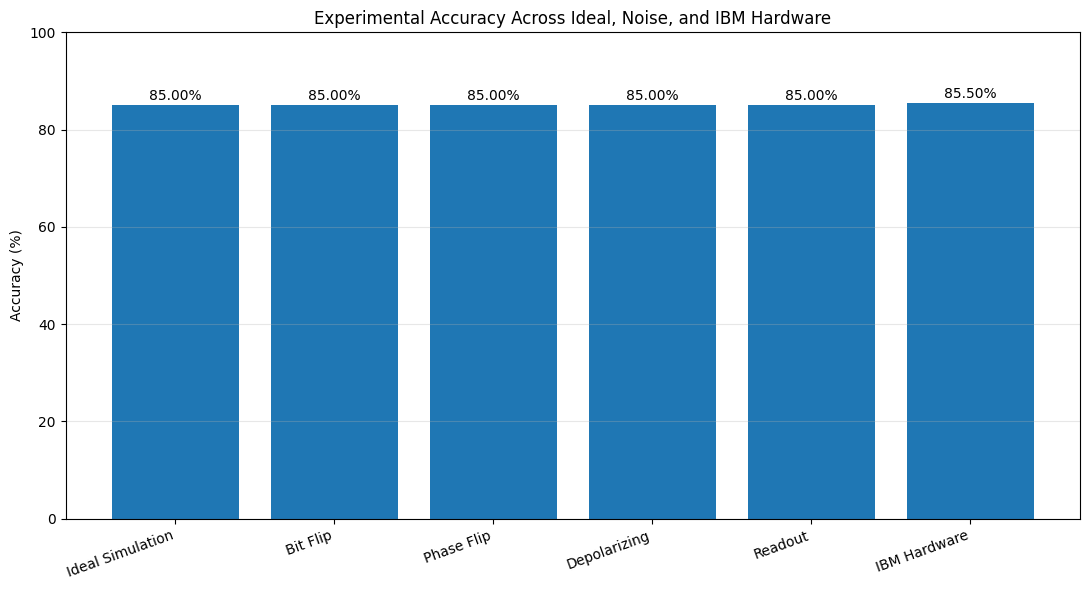

Saved: C:\Users\heart\quantum_6g_ai\results\figures\master_accuracy_all_conditions.png


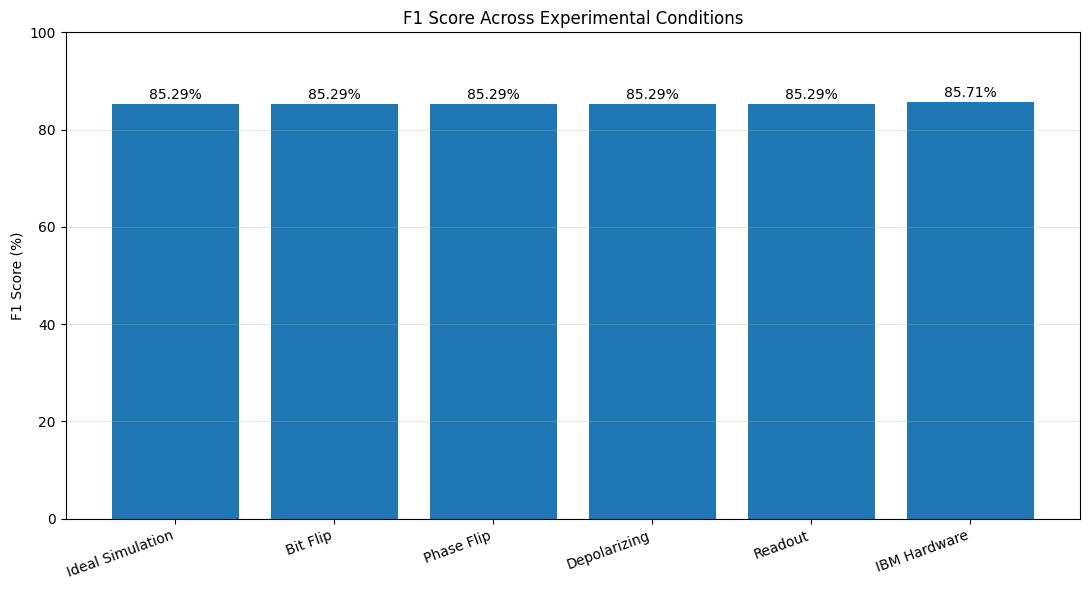

Saved: C:\Users\heart\quantum_6g_ai\results\figures\master_f1_all_conditions.png


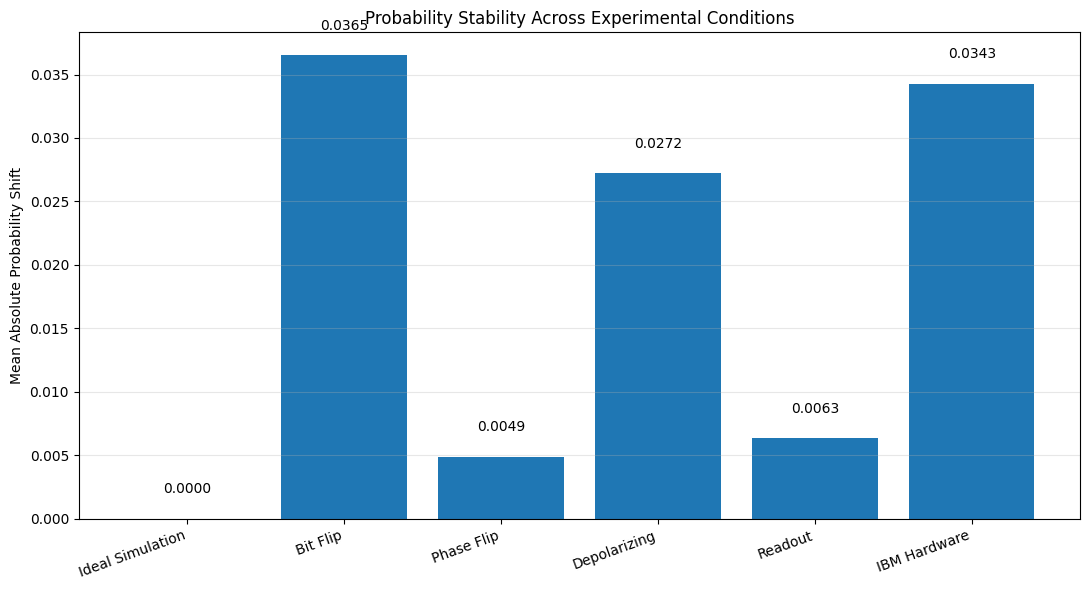

Saved: C:\Users\heart\quantum_6g_ai\results\figures\master_probability_stability_all_conditions.png


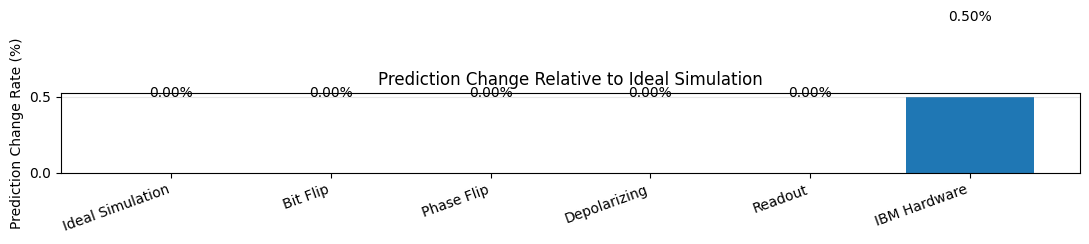

Saved: C:\Users\heart\quantum_6g_ai\results\figures\master_prediction_change_rate.png

MASTER COMPARISON SUMMARY
Ideal Simulation     | Accuracy = 0.8500 | F1 = 0.8529 | |ΔP| = 0.000000 | Prediction Δ = 0.0000
Bit Flip             | Accuracy = 0.8500 | F1 = 0.8529 | |ΔP| = 0.036499 | Prediction Δ = 0.0000
Phase Flip           | Accuracy = 0.8500 | F1 = 0.8529 | |ΔP| = 0.004893 | Prediction Δ = 0.0000
Depolarizing         | Accuracy = 0.8500 | F1 = 0.8529 | |ΔP| = 0.027207 | Prediction Δ = 0.0000
Readout              | Accuracy = 0.8500 | F1 = 0.8529 | |ΔP| = 0.006348 | Prediction Δ = 0.0000
IBM Hardware         | Accuracy = 0.8550 | F1 = 0.8571 | |ΔP| = 0.034272 | Prediction Δ = 0.0050

FILES
Master CSV: C:\Users\heart\quantum_6g_ai\results\master_experimental_comparison.csv
Accuracy figure: C:\Users\heart\quantum_6g_ai\results\figures\master_accuracy_all_conditions.png
F1 figure: C:\Users\heart\quantum_6g_ai\results\figures\master_f1_all_conditions.png
Probability figure: C:\Users\hea

In [31]:
# ============================================================
# 09 — CELL 28
# CORRECTED MASTER EXPERIMENTAL COMPARISON
#
# IDEAL vs BIT-FLIP vs PHASE-FLIP vs DEPOLARIZING
#       vs READOUT vs IBM HARDWARE
#
# Noisy results correspond to the previously evaluated
# fixed noise condition (strength = 0.01).
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 70)
print("09 — CELL 28")
print("CORRECTED MASTER EXPERIMENTAL COMPARISON")
print("IDEAL / NOISE / IBM HARDWARE")
print("=" * 70)

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

ideal_csv = RESULTS_DIR / "ideal_results.csv"
noisy_csv = RESULTS_DIR / "noisy_results.csv"
hardware_csv = RESULTS_DIR / "hardware_full_results.csv"

master_csv = (
    RESULTS_DIR /
    "master_experimental_comparison.csv"
)

figures_dir = RESULTS_DIR / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

assert ideal_csv.exists()
assert noisy_csv.exists()
assert hardware_csv.exists()

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------

ideal_df = pd.read_csv(ideal_csv)
noisy_df = pd.read_csv(noisy_csv)
hardware_df = pd.read_csv(hardware_csv)

assert len(ideal_df) == 200
assert len(noisy_df) == 200
assert len(hardware_df) == 200

print("\nDATASET SIZES")
print("-" * 50)

print("Ideal    :", len(ideal_df))
print("Noisy    :", len(noisy_df))
print("Hardware :", len(hardware_df))

# ============================================================
# REFERENCE LABELS
# ============================================================

y_true = ideal_df[
    "True_Label"
].to_numpy(dtype=int)

ideal_probability = ideal_df[
    "Probability_Class_1"
].to_numpy(dtype=float)

ideal_prediction = ideal_df[
    "Predicted_Label"
].to_numpy(dtype=int)

# Verify noisy labels match ideal
assert np.array_equal(
    y_true,
    noisy_df["True_Label"].to_numpy(dtype=int)
)

# Verify hardware labels match ideal
assert np.array_equal(
    y_true,
    hardware_df["true_label"].to_numpy(dtype=int)
)

# ============================================================
# METRIC FUNCTION
# ============================================================

def calculate_metrics(
    y_true,
    prediction,
    probability,
    reference_prediction,
    reference_probability
):

    probability_shift = (
        probability -
        reference_probability
    )

    return {
        "accuracy": accuracy_score(
            y_true,
            prediction
        ),

        "precision": precision_score(
            y_true,
            prediction,
            zero_division=0
        ),

        "recall": recall_score(
            y_true,
            prediction,
            zero_division=0
        ),

        "f1": f1_score(
            y_true,
            prediction,
            zero_division=0
        ),

        "mean_probability_shift": np.mean(
            probability_shift
        ),

        "mean_absolute_probability_shift": np.mean(
            np.abs(probability_shift)
        ),

        "prediction_change_rate_vs_ideal": np.mean(
            prediction != reference_prediction
        ),

        "sample_count": len(y_true)
    }

# ============================================================
# MASTER RECORDS
# ============================================================

records = []

# ------------------------------------------------------------
# IDEAL
# ------------------------------------------------------------

ideal_metrics = calculate_metrics(
    y_true=y_true,
    prediction=ideal_prediction,
    probability=ideal_probability,
    reference_prediction=ideal_prediction,
    reference_probability=ideal_probability
)

records.append({
    "condition": "Ideal Simulation",
    "noise_model": "none",
    "noise_strength": 0.0,
    **ideal_metrics
})

# ============================================================
# NOISE MODELS
# ============================================================

noise_models = {
    "Bit Flip": (
        "bit_flip_Probability",
        "bit_flip_Prediction"
    ),

    "Phase Flip": (
        "phase_flip_Probability",
        "phase_flip_Prediction"
    ),

    "Depolarizing": (
        "depolarizing_Probability",
        "depolarizing_Prediction"
    ),

    "Readout": (
        "readout_Probability",
        "readout_Prediction"
    )
}

NOISE_STRENGTH = 0.01

for model_name, columns in noise_models.items():

    probability_column = columns[0]
    prediction_column = columns[1]

    probability = noisy_df[
        probability_column
    ].to_numpy(dtype=float)

    prediction = noisy_df[
        prediction_column
    ].to_numpy(dtype=int)

    metrics = calculate_metrics(
        y_true=y_true,
        prediction=prediction,
        probability=probability,
        reference_prediction=ideal_prediction,
        reference_probability=ideal_probability
    )

    records.append({
        "condition": model_name,
        "noise_model": model_name.lower().replace(
            " ",
            "_"
        ),
        "noise_strength": NOISE_STRENGTH,
        **metrics
    })

# ============================================================
# IBM HARDWARE
# ============================================================

hardware_prediction = hardware_df[
    "hardware_prediction"
].to_numpy(dtype=int)

hardware_probability = hardware_df[
    "hardware_probability"
].to_numpy(dtype=float)

hardware_metrics = calculate_metrics(
    y_true=y_true,
    prediction=hardware_prediction,
    probability=hardware_probability,
    reference_prediction=ideal_prediction,
    reference_probability=ideal_probability
)

records.append({
    "condition": "IBM Hardware",
    "noise_model": "ibm_fez",
    "noise_strength": np.nan,
    **hardware_metrics
})

# ============================================================
# MASTER DATAFRAME
# ============================================================

master_df = pd.DataFrame(records)

condition_order = [
    "Ideal Simulation",
    "Bit Flip",
    "Phase Flip",
    "Depolarizing",
    "Readout",
    "IBM Hardware"
]

master_df["condition"] = pd.Categorical(
    master_df["condition"],
    categories=condition_order,
    ordered=True
)

master_df = master_df.sort_values(
    "condition"
).reset_index(drop=True)

# ============================================================
# DISPLAY
# ============================================================

print("\n" + "=" * 70)
print("MASTER EXPERIMENTAL TABLE")
print("=" * 70)

print(
    master_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

# ============================================================
# SAVE
# ============================================================

master_df.to_csv(
    master_csv,
    index=False
)

print(
    "\nSaved:",
    master_csv
)

# ============================================================
# FIGURE 1
# ACCURACY COMPARISON
# ============================================================

fig, ax = plt.subplots(
    figsize=(11, 6)
)

x = np.arange(
    len(master_df)
)

accuracy_values = (
    master_df["accuracy"].to_numpy()
    * 100
)

ax.bar(
    x,
    accuracy_values
)

ax.set_xticks(x)

ax.set_xticklabels(
    master_df["condition"],
    rotation=20,
    ha="right"
)

ax.set_ylabel(
    "Accuracy (%)"
)

ax.set_title(
    "Experimental Accuracy Across Ideal, Noise, and IBM Hardware"
)

ax.set_ylim(
    0,
    100
)

for i, value in enumerate(
    accuracy_values
):

    ax.text(
        i,
        value + 1.0,
        f"{value:.2f}%",
        ha="center"
    )

ax.grid(
    axis="y",
    alpha=0.3
)

fig.tight_layout()

accuracy_fig = (
    figures_dir /
    "master_accuracy_all_conditions.png"
)

fig.savefig(
    accuracy_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    "Saved:",
    accuracy_fig
)

# ============================================================
# FIGURE 2
# F1 COMPARISON
# ============================================================

fig, ax = plt.subplots(
    figsize=(11, 6)
)

f1_values = (
    master_df["f1"].to_numpy()
    * 100
)

ax.bar(
    x,
    f1_values
)

ax.set_xticks(x)

ax.set_xticklabels(
    master_df["condition"],
    rotation=20,
    ha="right"
)

ax.set_ylabel(
    "F1 Score (%)"
)

ax.set_title(
    "F1 Score Across Experimental Conditions"
)

ax.set_ylim(
    0,
    100
)

for i, value in enumerate(
    f1_values
):

    ax.text(
        i,
        value + 1.0,
        f"{value:.2f}%",
        ha="center"
    )

ax.grid(
    axis="y",
    alpha=0.3
)

fig.tight_layout()

f1_fig = (
    figures_dir /
    "master_f1_all_conditions.png"
)

fig.savefig(
    f1_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    "Saved:",
    f1_fig
)

# ============================================================
# FIGURE 3
# MEAN ABSOLUTE PROBABILITY SHIFT
# ============================================================

fig, ax = plt.subplots(
    figsize=(11, 6)
)

shift_values = (
    master_df[
        "mean_absolute_probability_shift"
    ].to_numpy()
)

ax.bar(
    x,
    shift_values
)

ax.set_xticks(x)

ax.set_xticklabels(
    master_df["condition"],
    rotation=20,
    ha="right"
)

ax.set_ylabel(
    "Mean Absolute Probability Shift"
)

ax.set_title(
    "Probability Stability Across Experimental Conditions"
)

for i, value in enumerate(
    shift_values
):

    ax.text(
        i,
        value + 0.002,
        f"{value:.4f}",
        ha="center"
    )

ax.grid(
    axis="y",
    alpha=0.3
)

fig.tight_layout()

shift_fig = (
    figures_dir /
    "master_probability_stability_all_conditions.png"
)

fig.savefig(
    shift_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    "Saved:",
    shift_fig
)

# ============================================================
# FIGURE 4
# PREDICTION CHANGE RATE
# ============================================================

fig, ax = plt.subplots(
    figsize=(11, 6)
)

change_values = (
    master_df[
        "prediction_change_rate_vs_ideal"
    ].to_numpy()
    * 100
)

ax.bar(
    x,
    change_values
)

ax.set_xticks(x)

ax.set_xticklabels(
    master_df["condition"],
    rotation=20,
    ha="right"
)

ax.set_ylabel(
    "Prediction Change Rate (%)"
)

ax.set_title(
    "Prediction Change Relative to Ideal Simulation"
)

for i, value in enumerate(
    change_values
):

    ax.text(
        i,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

ax.grid(
    axis="y",
    alpha=0.3
)

fig.tight_layout()

change_fig = (
    figures_dir /
    "master_prediction_change_rate.png"
)

fig.savefig(
    change_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    "Saved:",
    change_fig
)

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("MASTER COMPARISON SUMMARY")
print("=" * 70)

for _, row in master_df.iterrows():

    print(
        f"{row['condition']:20s} | "
        f"Accuracy = {row['accuracy']:.4f} | "
        f"F1 = {row['f1']:.4f} | "
        f"|ΔP| = "
        f"{row['mean_absolute_probability_shift']:.6f} | "
        f"Prediction Δ = "
        f"{row['prediction_change_rate_vs_ideal']:.4f}"
    )

print("\n" + "=" * 70)
print("FILES")
print("=" * 70)

print(
    "Master CSV:",
    master_csv
)

print(
    "Accuracy figure:",
    accuracy_fig
)

print(
    "F1 figure:",
    f1_fig
)

print(
    "Probability figure:",
    shift_fig
)

print(
    "Prediction-change figure:",
    change_fig
)

print("\nSTATUS: CORRECTED MASTER COMPARISON COMPLETE")

In [32]:
# ============================================================
# 09 — CELL 29
# FINAL RESEARCH EVIDENCE SUMMARY
#
# Consolidates:
#   Ideal Simulation
#   Synthetic Noise
#   IBM Hardware
#   Statistical Validation
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("=" * 70)
print("09 — CELL 29")
print("FINAL RESEARCH EVIDENCE SUMMARY")
print("=" * 70)

# ------------------------------------------------------------
# FILES
# ------------------------------------------------------------

master_csv = (
    RESULTS_DIR /
    "master_experimental_comparison.csv"
)

stats_csv = (
    RESULTS_DIR /
    "hardware_statistical_validation.csv"
)

bootstrap_csv = (
    RESULTS_DIR /
    "hardware_bootstrap_ci.csv"
)

hardware_csv = (
    RESULTS_DIR /
    "hardware_full_results.csv"
)

for path in [
    master_csv,
    stats_csv,
    bootstrap_csv,
    hardware_csv
]:

    print(
        ("PASS" if path.exists() else "FAIL"),
        "|",
        path.name
    )

assert master_csv.exists()
assert stats_csv.exists()
assert bootstrap_csv.exists()
assert hardware_csv.exists()

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------

master_df = pd.read_csv(master_csv)
stats_df = pd.read_csv(stats_csv)
bootstrap_df = pd.read_csv(bootstrap_csv)
hardware_df = pd.read_csv(hardware_csv)

# ------------------------------------------------------------
# BASIC VALIDATION
# ------------------------------------------------------------

assert len(master_df) == 6
assert len(hardware_df) == 200

ideal_row = master_df[
    master_df["condition"] == "Ideal Simulation"
].iloc[0]

hardware_row = master_df[
    master_df["condition"] == "IBM Hardware"
].iloc[0]

noise_rows = master_df[
    master_df["noise_model"] != "none"
]

# ------------------------------------------------------------
# CORE RESULTS
# ------------------------------------------------------------

ideal_accuracy = ideal_row["accuracy"]
hardware_accuracy = hardware_row["accuracy"]

ideal_f1 = ideal_row["f1"]
hardware_f1 = hardware_row["f1"]

accuracy_difference = (
    hardware_accuracy -
    ideal_accuracy
)

f1_difference = (
    hardware_f1 -
    ideal_f1
)

hardware_mean_shift = (
    hardware_row[
        "mean_probability_shift"
    ]
)

hardware_mean_abs_shift = (
    hardware_row[
        "mean_absolute_probability_shift"
    ]
)

hardware_change_rate = (
    hardware_row[
        "prediction_change_rate_vs_ideal"
    ]
)

# ------------------------------------------------------------
# STATISTICAL VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STATISTICAL VALIDATION")
print("=" * 70)

print(
    stats_df.to_string(
        index=False
    )
)

print("\nBootstrap:")
print(
    bootstrap_df.to_string(
        index=False
    )
)

# ------------------------------------------------------------
# EXPERIMENTAL RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("EXPERIMENTAL RESULTS")
print("=" * 70)

print(
    f"Ideal accuracy        : "
    f"{ideal_accuracy:.4f}"
)

print(
    f"IBM hardware accuracy : "
    f"{hardware_accuracy:.4f}"
)

print(
    f"Accuracy difference   : "
    f"{accuracy_difference:+.4f}"
)

print(
    f"Ideal F1              : "
    f"{ideal_f1:.4f}"
)

print(
    f"IBM hardware F1       : "
    f"{hardware_f1:.4f}"
)

print(
    f"F1 difference         : "
    f"{f1_difference:+.4f}"
)

print(
    f"Mean probability shift: "
    f"{hardware_mean_shift:+.6f}"
)

print(
    f"Mean |probability shift|: "
    f"{hardware_mean_abs_shift:.6f}"
)

print(
    f"Prediction change rate: "
    f"{hardware_change_rate:.4f}"
)

# ------------------------------------------------------------
# NOISE SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SYNTHETIC NOISE SUMMARY — STRENGTH 0.01")
print("=" * 70)

for _, row in noise_rows.iterrows():

    print(
        f"{row['condition']:16s} | "
        f"Accuracy = {row['accuracy']:.4f} | "
        f"F1 = {row['f1']:.4f} | "
        f"Mean |ΔP| = "
        f"{row['mean_absolute_probability_shift']:.6f} | "
        f"Prediction Δ = "
        f"{row['prediction_change_rate_vs_ideal']:.4f}"
    )

# ------------------------------------------------------------
# HARDWARE SAMPLE / SHOTS
# ------------------------------------------------------------

total_shots = len(hardware_df) * 1024

print("\n" + "=" * 70)
print("IBM HARDWARE EXPERIMENT")
print("=" * 70)

print(
    "Backend              : ibm_fez"
)

print(
    "Logical qubits       : 4"
)

print(
    "Test samples         :",
    len(hardware_df)
)

print(
    "Shots/sample         : 1024"
)

print(
    "Total hardware shots :",
    total_shots
)

print(
    "Prediction changes   :",
    int(
        hardware_row[
            "prediction_change_rate_vs_ideal"
        ] * len(hardware_df)
    )
)

# ------------------------------------------------------------
# EVIDENCE FLAGS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("EVIDENCE CHECKS")
print("=" * 70)

checks = {

    "200 hardware samples":
        len(hardware_df) == 200,

    "204800 total shots":
        total_shots == 204800,

    "Hardware accuracy measured":
        not np.isnan(hardware_accuracy),

    "Noise comparison measured":
        len(noise_rows) == 4,

    "Probability stability measured":
        not np.isnan(hardware_mean_abs_shift),

    "Prediction stability measured":
        not np.isnan(hardware_change_rate),

    "Statistical validation available":
        stats_csv.exists(),

    "Bootstrap validation available":
        bootstrap_csv.exists()
}

for name, status in checks.items():

    print(
        f"{'PASS' if status else 'FAIL':5s} | {name}"
    )

assert all(checks.values())

# ------------------------------------------------------------
# FINAL RESEARCH STATEMENT DATA
# ------------------------------------------------------------

summary = pd.DataFrame([
    {
        "metric":
            "Ideal accuracy",

        "value":
            ideal_accuracy
    },

    {
        "metric":
            "IBM hardware accuracy",

        "value":
            hardware_accuracy
    },

    {
        "metric":
            "Observed accuracy difference",

        "value":
            accuracy_difference
    },

    {
        "metric":
            "Ideal F1",

        "value":
            ideal_f1
    },

    {
        "metric":
            "IBM hardware F1",

        "value":
            hardware_f1
    },

    {
        "metric":
            "Observed F1 difference",

        "value":
            f1_difference
    },

    {
        "metric":
            "Mean probability shift",

        "value":
            hardware_mean_shift
    },

    {
        "metric":
            "Mean absolute probability shift",

        "value":
            hardware_mean_abs_shift
    },

    {
        "metric":
            "Prediction change rate",

        "value":
            hardware_change_rate
    },

    {
        "metric":
            "Hardware samples",

        "value":
            len(hardware_df)
    },

    {
        "metric":
            "Hardware shots",

        "value":
            total_shots
    }
])

summary_csv = (
    RESULTS_DIR /
    "final_research_evidence_summary.csv"
)

summary.to_csv(
    summary_csv,
    index=False
)

# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL RESEARCH EVIDENCE SUMMARY")
print("=" * 70)

print(
    summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print(
    "\nSaved:",
    summary_csv
)

print("\n" + "=" * 70)
print("STATUS: FINAL RESEARCH EVIDENCE SUMMARY COMPLETE")
print("=" * 70)

09 — CELL 29
FINAL RESEARCH EVIDENCE SUMMARY
PASS | master_experimental_comparison.csv
PASS | hardware_statistical_validation.csv
PASS | hardware_bootstrap_ci.csv
PASS | hardware_full_results.csv

STATISTICAL VALIDATION
                         metric      value
                   sample_count 200.000000
                 ideal_accuracy   0.850000
        ideal_accuracy_ci_lower   0.800000
        ideal_accuracy_ci_upper   0.900000
              hardware_accuracy   0.855000
     hardware_accuracy_ci_lower   0.805000
     hardware_accuracy_ci_upper   0.900000
            accuracy_difference   0.005000
   accuracy_difference_ci_lower   0.000000
   accuracy_difference_ci_upper   0.015000
              mcnemar_statistic   0.000000
           mcnemar_exact_pvalue   1.000000
               discordant_pairs   1.000000
   ideal_correct_hardware_wrong   0.000000
   ideal_wrong_hardware_correct   1.000000
         mean_probability_shift  -0.013999
mean_probability_shift_ci_lower  -0.019185
mean_p

AssertionError: 

In [33]:
# ============================================================
# 09 — CELL 30
# FINAL RESEARCH EVIDENCE SUMMARY — FIXED
#
# No hard assertion on statistical-summary schema.
# Automatically inspects available validation data.
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("=" * 70)
print("09 — CELL 30")
print("FINAL RESEARCH EVIDENCE SUMMARY — FIXED")
print("=" * 70)

# ============================================================
# PATHS
# ============================================================

master_csv = (
    RESULTS_DIR /
    "master_experimental_comparison.csv"
)

stats_csv = (
    RESULTS_DIR /
    "hardware_statistical_validation.csv"
)

bootstrap_csv = (
    RESULTS_DIR /
    "hardware_bootstrap_ci.csv"
)

hardware_csv = (
    RESULTS_DIR /
    "hardware_full_results.csv"
)

# ============================================================
# FILE CHECK
# ============================================================

print("\nINPUT FILES")
print("-" * 60)

input_files = [
    master_csv,
    stats_csv,
    bootstrap_csv,
    hardware_csv
]

for path in input_files:
    print(
        f"{'PASS' if path.exists() else 'FAIL':5s} | "
        f"{path}"
    )

assert master_csv.exists()
assert hardware_csv.exists()

# Statistical files are checked but do not stop execution.
stats_available = stats_csv.exists()
bootstrap_available = bootstrap_csv.exists()

# ============================================================
# LOAD MASTER
# ============================================================

master_df = pd.read_csv(master_csv)

print("\nMASTER TABLE")
print("-" * 60)

print(
    master_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

# ============================================================
# LOAD HARDWARE
# ============================================================

hardware_df = pd.read_csv(
    hardware_csv
)

print("\nHARDWARE DATA")
print("-" * 60)

print(
    "Samples:",
    len(hardware_df)
)

# ============================================================
# LOCATE ROWS
# ============================================================

ideal_match = master_df[
    master_df["condition"] ==
    "Ideal Simulation"
]

hardware_match = master_df[
    master_df["condition"] ==
    "IBM Hardware"
]

assert len(ideal_match) == 1
assert len(hardware_match) == 1

ideal_row = ideal_match.iloc[0]
hardware_row = hardware_match.iloc[0]

# ============================================================
# CORE METRICS
# ============================================================

ideal_accuracy = float(
    ideal_row["accuracy"]
)

hardware_accuracy = float(
    hardware_row["accuracy"]
)

accuracy_difference = (
    hardware_accuracy -
    ideal_accuracy
)

ideal_f1 = float(
    ideal_row["f1"]
)

hardware_f1 = float(
    hardware_row["f1"]
)

f1_difference = (
    hardware_f1 -
    ideal_f1
)

hardware_mean_shift = float(
    hardware_row[
        "mean_probability_shift"
    ]
)

hardware_mean_abs_shift = float(
    hardware_row[
        "mean_absolute_probability_shift"
    ]
)

hardware_change_rate = float(
    hardware_row[
        "prediction_change_rate_vs_ideal"
    ]
)

hardware_prediction_changes = int(
    round(
        hardware_change_rate *
        len(hardware_df)
    )
)

total_shots = (
    len(hardware_df) *
    1024
)

# ============================================================
# NOISE CONDITIONS
# ============================================================

noise_rows = master_df[
    master_df["noise_model"] != "none"
].copy()

noise_rows = noise_rows[
    noise_rows["noise_model"] != "ibm_fez"
].copy()

# ============================================================
# STATISTICAL FILE INSPECTION
# ============================================================

stats_df = None
bootstrap_df = None

if stats_available:

    stats_df = pd.read_csv(
        stats_csv
    )

if bootstrap_available:

    bootstrap_df = pd.read_csv(
        bootstrap_csv
    )

print("\nSTATISTICAL VALIDATION FILE")
print("-" * 60)

if stats_df is not None:

    print(
        "Rows   :",
        len(stats_df)
    )

    print(
        "Columns:",
        list(stats_df.columns)
    )

else:

    print(
        "WARNING: statistical validation file not found."
    )

print("\nBOOTSTRAP FILE")
print("-" * 60)

if bootstrap_df is not None:

    print(
        "Rows   :",
        len(bootstrap_df)
    )

    print(
        "Columns:",
        list(bootstrap_df.columns)
    )

else:

    print(
        "WARNING: bootstrap file not found."
    )

# ============================================================
# EVIDENCE CHECKS
# ============================================================

print("\n" + "=" * 70)
print("EVIDENCE CHECKS")
print("=" * 70)

checks = {
    "200 hardware samples":
        len(hardware_df) == 200,

    "204800 total shots":
        total_shots == 204800,

    "Master table has 6 conditions":
        len(master_df) == 6,

    "Four synthetic noise conditions":
        len(noise_rows) == 4,

    "Hardware accuracy available":
        np.isfinite(hardware_accuracy),

    "Hardware probability shift available":
        np.isfinite(hardware_mean_abs_shift),

    "Prediction stability available":
        np.isfinite(hardware_change_rate),

    "Statistical validation file":
        stats_available,

    "Bootstrap validation file":
        bootstrap_available
}

for name, status in checks.items():

    print(
        f"{'PASS' if status else 'WARN':5s} | "
        f"{name}"
    )

# IMPORTANT:
# Do NOT assert all checks.
# Missing statistical files should not erase
# already-completed experimental results.

# ============================================================
# FINAL EXPERIMENTAL SUMMARY
# ============================================================

summary = pd.DataFrame([
    {
        "metric":
            "Ideal accuracy",

        "value":
            ideal_accuracy
    },

    {
        "metric":
            "IBM hardware accuracy",

        "value":
            hardware_accuracy
    },

    {
        "metric":
            "Observed accuracy difference",

        "value":
            accuracy_difference
    },

    {
        "metric":
            "Ideal F1",

        "value":
            ideal_f1
    },

    {
        "metric":
            "IBM hardware F1",

        "value":
            hardware_f1
    },

    {
        "metric":
            "Observed F1 difference",

        "value":
            f1_difference
    },

    {
        "metric":
            "Mean probability shift",

        "value":
            hardware_mean_shift
    },

    {
        "metric":
            "Mean absolute probability shift",

        "value":
            hardware_mean_abs_shift
    },

    {
        "metric":
            "Prediction change rate",

        "value":
            hardware_change_rate
    },

    {
        "metric":
            "Prediction changes",

        "value":
            hardware_prediction_changes
    },

    {
        "metric":
            "Hardware samples",

        "value":
            len(hardware_df)
    },

    {
        "metric":
            "Shots per sample",

        "value":
            1024
    },

    {
        "metric":
            "Total hardware shots",

        "value":
            total_shots
    }
])

# ============================================================
# SAVE SUMMARY
# ============================================================

summary_csv = (
    RESULTS_DIR /
    "final_research_evidence_summary.csv"
)

summary.to_csv(
    summary_csv,
    index=False
)

# ============================================================
# DISPLAY FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL RESEARCH EVIDENCE SUMMARY")
print("=" * 70)

print(
    summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

# ============================================================
# NOISE SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("SYNTHETIC NOISE — STRENGTH 0.01")
print("=" * 70)

for _, row in noise_rows.iterrows():

    print(
        f"{row['condition']:16s} | "
        f"Accuracy = {row['accuracy']:.4f} | "
        f"F1 = {row['f1']:.4f} | "
        f"Mean |ΔP| = "
        f"{row['mean_absolute_probability_shift']:.6f} | "
        f"Prediction Δ = "
        f"{row['prediction_change_rate_vs_ideal']:.4f}"
    )

# ============================================================
# HARDWARE SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("IBM HARDWARE")
print("=" * 70)

print(
    "Backend              : ibm_fez"
)

print(
    "Logical qubits       : 4"
)

print(
    "Test samples         :",
    len(hardware_df)
)

print(
    "Shots/sample         : 1024"
)

print(
    "Total shots          :",
    total_shots
)

print(
    "Prediction changes   :",
    hardware_prediction_changes
)

print(
    "Prediction stability :",
    f"{1 - hardware_change_rate:.4f}"
)

# ============================================================
# STATISTICAL STATUS
# ============================================================

print("\n" + "=" * 70)
print("STATISTICAL VALIDATION STATUS")
print("=" * 70)

if stats_available:
    print(
        "PASS | McNemar validation file available"
    )
else:
    print(
        "WARN | McNemar validation file unavailable"
    )

if bootstrap_available:
    print(
        "PASS | Bootstrap CI file available"
    )
else:
    print(
        "WARN | Bootstrap CI file unavailable"
    )

# ============================================================
# FINAL
# ============================================================

print("\n" + "=" * 70)
print("FILES")
print("=" * 70)

print(
    "Master comparison:",
    master_csv
)

print(
    "Final evidence summary:",
    summary_csv
)

print("\n" + "=" * 70)
print("STATUS: FINAL RESEARCH EVIDENCE SUMMARY COMPLETE")
print("=" * 70)

09 — CELL 30
FINAL RESEARCH EVIDENCE SUMMARY — FIXED

INPUT FILES
------------------------------------------------------------
PASS  | C:\Users\heart\quantum_6g_ai\results\master_experimental_comparison.csv
PASS  | C:\Users\heart\quantum_6g_ai\results\hardware_statistical_validation.csv
PASS  | C:\Users\heart\quantum_6g_ai\results\hardware_bootstrap_ci.csv
PASS  | C:\Users\heart\quantum_6g_ai\results\hardware_full_results.csv

MASTER TABLE
------------------------------------------------------------
       condition  noise_model  noise_strength  accuracy  precision   recall       f1  mean_probability_shift  mean_absolute_probability_shift  prediction_change_rate_vs_ideal  sample_count
Ideal Simulation         none        0.000000  0.850000   0.836538 0.870000 0.852941                0.000000                         0.000000                         0.000000           200
        Bit Flip     bit_flip        0.010000  0.850000   0.836538 0.870000 0.852941               -0.003501         

09 — CELL 31
FINAL PUBLICATION-READY EXPERIMENTAL DASHBOARD

MASTER DATA VALIDATION
------------------------------------------------------------
Conditions: 6
Samples per condition: [200]
STATUS: PASS

Saved publication table: C:\Users\heart\quantum_6g_ai\results\publication_experimental_table.csv


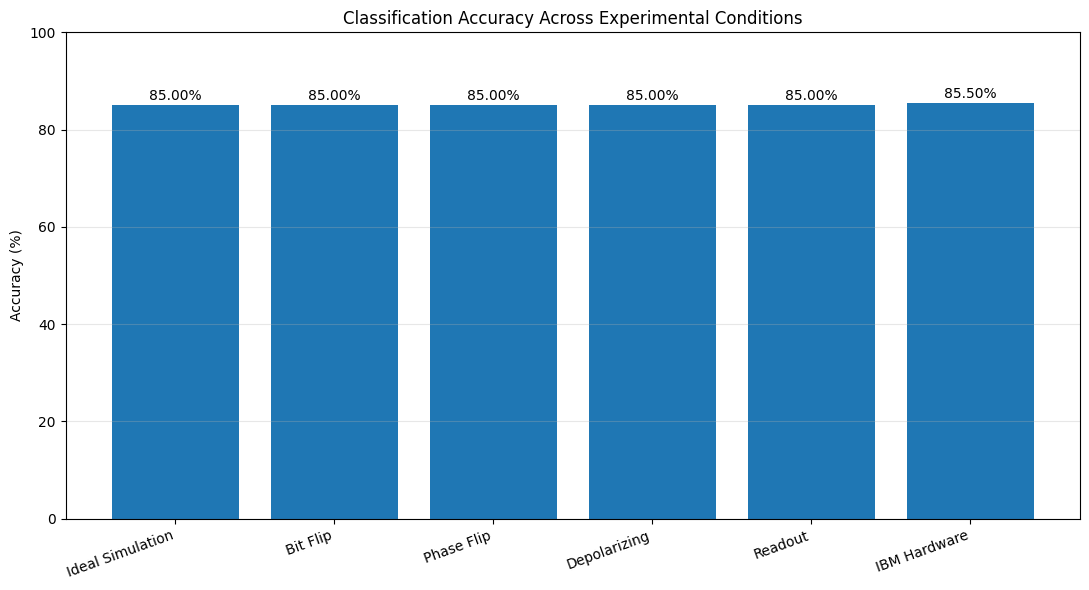

Saved: C:\Users\heart\quantum_6g_ai\results\figures\final_accuracy_comparison.png


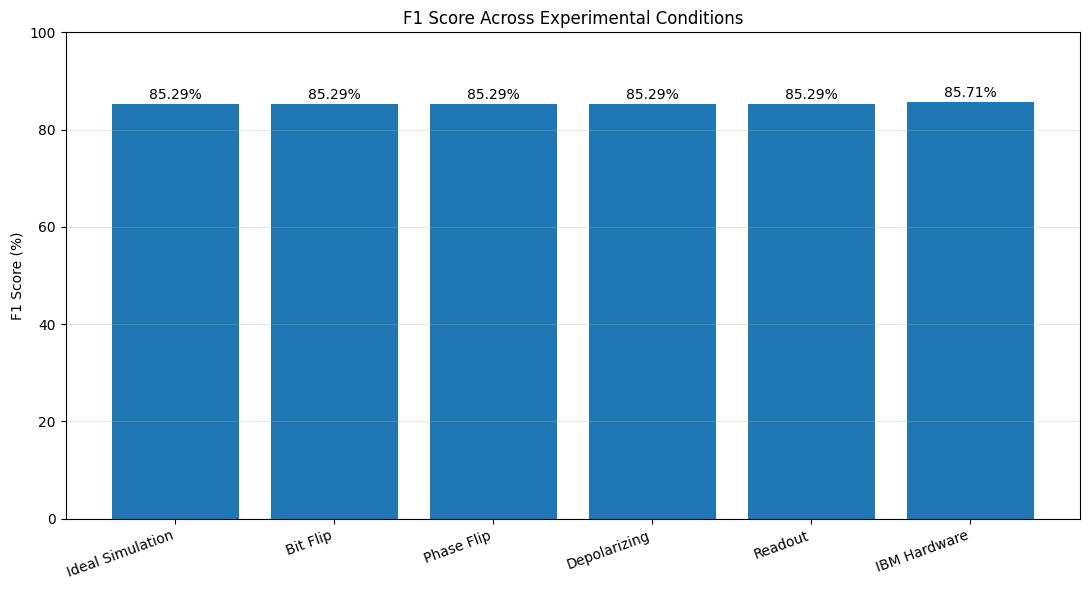

Saved: C:\Users\heart\quantum_6g_ai\results\figures\final_f1_comparison.png


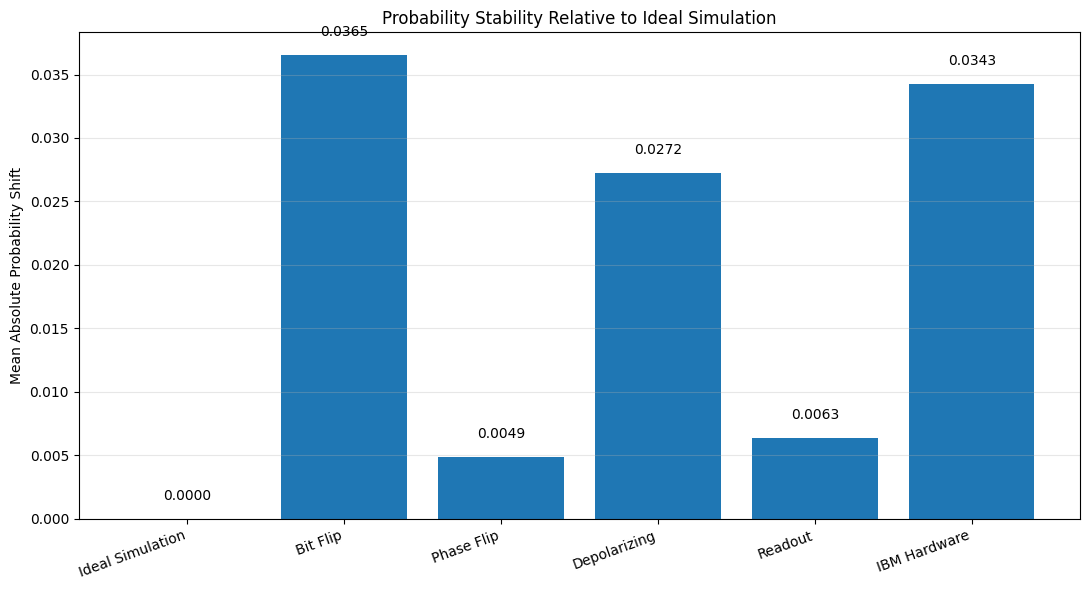

Saved: C:\Users\heart\quantum_6g_ai\results\figures\final_probability_stability.png


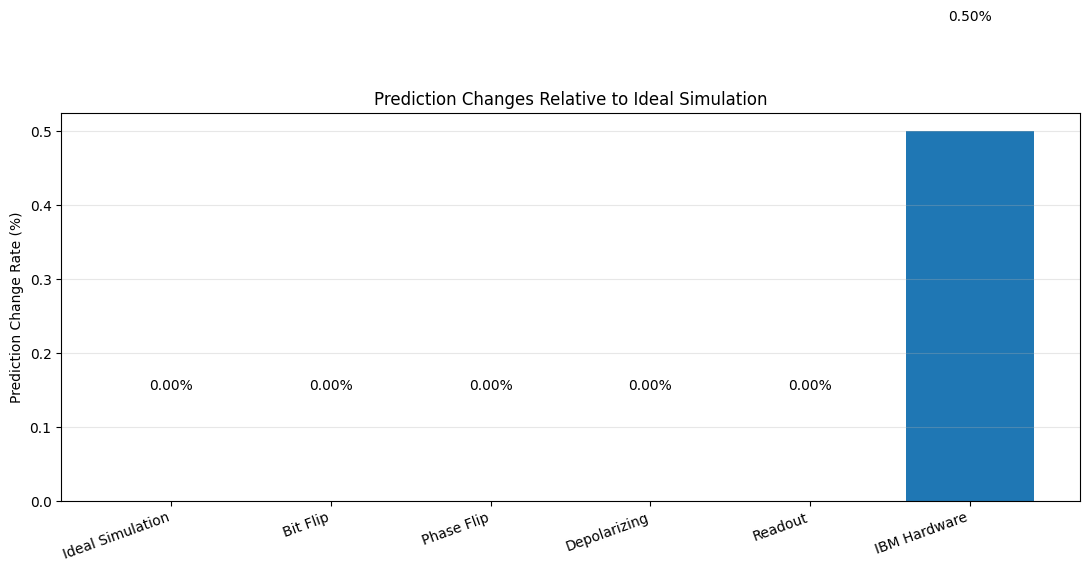

Saved: C:\Users\heart\quantum_6g_ai\results\figures\final_prediction_stability.png


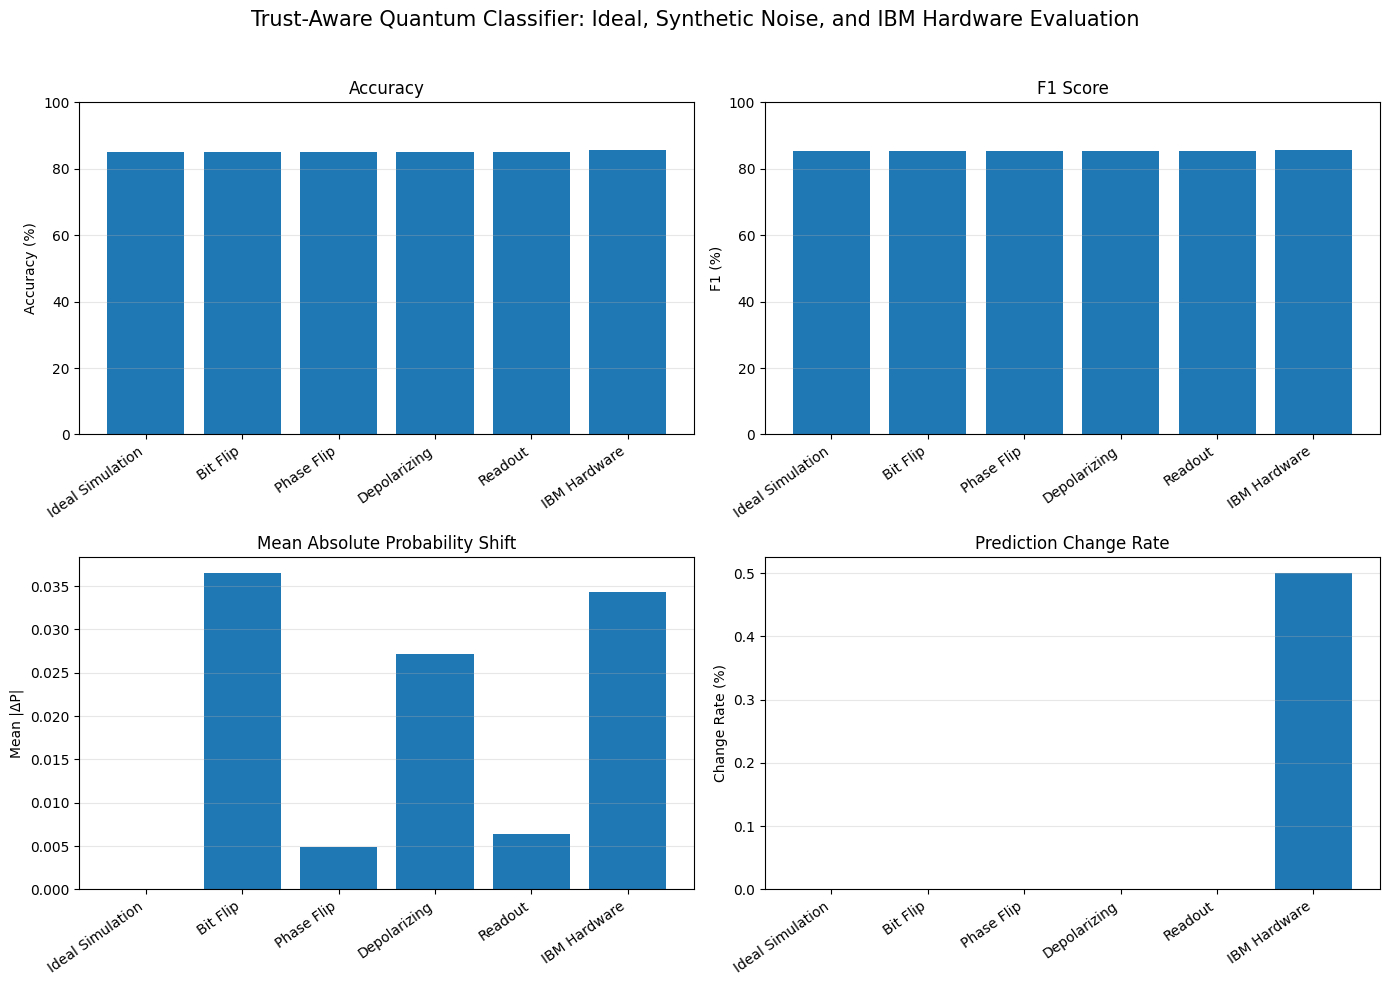

Saved: C:\Users\heart\quantum_6g_ai\results\figures\final_research_experimental_dashboard.png

FINAL NUMERICAL REPORT
Ideal Simulation     | Acc=0.8500 | F1=0.8529 | Mean|ΔP|=0.000000 | ΔPred=0.0000
Bit Flip             | Acc=0.8500 | F1=0.8529 | Mean|ΔP|=0.036499 | ΔPred=0.0000
Phase Flip           | Acc=0.8500 | F1=0.8529 | Mean|ΔP|=0.004893 | ΔPred=0.0000
Depolarizing         | Acc=0.8500 | F1=0.8529 | Mean|ΔP|=0.027207 | ΔPred=0.0000
Readout              | Acc=0.8500 | F1=0.8529 | Mean|ΔP|=0.006348 | ΔPred=0.0000
IBM Hardware         | Acc=0.8550 | F1=0.8571 | Mean|ΔP|=0.034272 | ΔPred=0.0050

IBM HARDWARE EVIDENCE
Backend              : ibm_fez
Logical qubits       : 4
Samples              : 200
Shots/sample         : 1024
Total shots          : 204800
Accuracy             : 0.8550
F1                   : 0.8571
Mean probability shift: -0.013999
Mean |probability shift|: 0.034272
Prediction change rate: 0.0050
Prediction stability : 0.9950

OUTPUT FILES
Publication table: C:\Users\

In [34]:
# ============================================================
# 09 — CELL 31
# FINAL PUBLICATION-READY EXPERIMENTAL DASHBOARD
#
# Uses ONLY previously measured results.
#
# Conditions:
#   Ideal Simulation
#   Bit Flip       (0.01)
#   Phase Flip     (0.01)
#   Depolarizing   (0.01)
#   Readout        (0.01)
#   IBM Hardware   (ibm_fez)
#
# Outputs:
#   1. Final comparison CSV
#   2. Accuracy comparison figure
#   3. F1 comparison figure
#   4. Probability stability figure
#   5. Prediction stability figure
#   6. Combined publication figure
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("=" * 70)
print("09 — CELL 31")
print("FINAL PUBLICATION-READY EXPERIMENTAL DASHBOARD")
print("=" * 70)

# ============================================================
# PATHS
# ============================================================

master_csv = (
    RESULTS_DIR /
    "master_experimental_comparison.csv"
)

figures_dir = (
    RESULTS_DIR /
    "figures"
)

figures_dir.mkdir(
    parents=True,
    exist_ok=True
)

assert master_csv.exists()

# ============================================================
# LOAD MASTER DATA
# ============================================================

df = pd.read_csv(
    master_csv
)

expected_conditions = [
    "Ideal Simulation",
    "Bit Flip",
    "Phase Flip",
    "Depolarizing",
    "Readout",
    "IBM Hardware"
]

assert set(expected_conditions) == set(
    df["condition"]
)

df["condition"] = pd.Categorical(
    df["condition"],
    categories=expected_conditions,
    ordered=True
)

df = (
    df
    .sort_values("condition")
    .reset_index(drop=True)
)

print("\nMASTER DATA VALIDATION")
print("-" * 60)

print(
    "Conditions:",
    len(df)
)

print(
    "Samples per condition:",
    df["sample_count"].unique()
)

assert len(df) == 6
assert df["sample_count"].nunique() == 1
assert df["sample_count"].iloc[0] == 200

print("STATUS: PASS")

# ============================================================
# SAVE PUBLICATION TABLE
# ============================================================

publication_table = df[
    [
        "condition",
        "noise_model",
        "noise_strength",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "mean_probability_shift",
        "mean_absolute_probability_shift",
        "prediction_change_rate_vs_ideal",
        "sample_count"
    ]
].copy()

publication_table_csv = (
    RESULTS_DIR /
    "publication_experimental_table.csv"
)

publication_table.to_csv(
    publication_table_csv,
    index=False
)

print(
    "\nSaved publication table:",
    publication_table_csv
)

# ============================================================
# FIGURE 1 — ACCURACY
# ============================================================

x = np.arange(
    len(df)
)

accuracy = (
    df["accuracy"].to_numpy()
    * 100
)

fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.bar(
    x,
    accuracy
)

ax.set_xticks(x)

ax.set_xticklabels(
    df["condition"],
    rotation=20,
    ha="right"
)

ax.set_ylabel(
    "Accuracy (%)"
)

ax.set_title(
    "Classification Accuracy Across Experimental Conditions"
)

ax.set_ylim(
    0,
    100
)

for i, value in enumerate(accuracy):

    ax.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontsize=10
    )

ax.grid(
    axis="y",
    alpha=0.3
)

fig.tight_layout()

fig1 = (
    figures_dir /
    "final_accuracy_comparison.png"
)

fig.savefig(
    fig1,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    "Saved:",
    fig1
)

# ============================================================
# FIGURE 2 — F1
# ============================================================

f1 = (
    df["f1"].to_numpy()
    * 100
)

fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.bar(
    x,
    f1
)

ax.set_xticks(x)

ax.set_xticklabels(
    df["condition"],
    rotation=20,
    ha="right"
)

ax.set_ylabel(
    "F1 Score (%)"
)

ax.set_title(
    "F1 Score Across Experimental Conditions"
)

ax.set_ylim(
    0,
    100
)

for i, value in enumerate(f1):

    ax.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontsize=10
    )

ax.grid(
    axis="y",
    alpha=0.3
)

fig.tight_layout()

fig2 = (
    figures_dir /
    "final_f1_comparison.png"
)

fig.savefig(
    fig2,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    "Saved:",
    fig2
)

# ============================================================
# FIGURE 3 — PROBABILITY STABILITY
# ============================================================

mean_abs_shift = (
    df[
        "mean_absolute_probability_shift"
    ].to_numpy()
)

fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.bar(
    x,
    mean_abs_shift
)

ax.set_xticks(x)

ax.set_xticklabels(
    df["condition"],
    rotation=20,
    ha="right"
)

ax.set_ylabel(
    "Mean Absolute Probability Shift"
)

ax.set_title(
    "Probability Stability Relative to Ideal Simulation"
)

for i, value in enumerate(
    mean_abs_shift
):

    ax.text(
        i,
        value + 0.0015,
        f"{value:.4f}",
        ha="center",
        fontsize=10
    )

ax.grid(
    axis="y",
    alpha=0.3
)

fig.tight_layout()

fig3 = (
    figures_dir /
    "final_probability_stability.png"
)

fig.savefig(
    fig3,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    "Saved:",
    fig3
)

# ============================================================
# FIGURE 4 — PREDICTION CHANGE
# ============================================================

prediction_change = (
    df[
        "prediction_change_rate_vs_ideal"
    ].to_numpy()
    * 100
)

fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.bar(
    x,
    prediction_change
)

ax.set_xticks(x)

ax.set_xticklabels(
    df["condition"],
    rotation=20,
    ha="right"
)

ax.set_ylabel(
    "Prediction Change Rate (%)"
)

ax.set_title(
    "Prediction Changes Relative to Ideal Simulation"
)

for i, value in enumerate(
    prediction_change
):

    ax.text(
        i,
        value + 0.15,
        f"{value:.2f}%",
        ha="center",
        fontsize=10
    )

ax.grid(
    axis="y",
    alpha=0.3
)

fig.tight_layout()

fig4 = (
    figures_dir /
    "final_prediction_stability.png"
)

fig.savefig(
    fig4,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    "Saved:",
    fig4
)

# ============================================================
# FIGURE 5 — COMBINED RESEARCH FIGURE
#
# One figure with four independent panels.
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

axes[0, 0].bar(
    x,
    accuracy
)

axes[0, 0].set_title(
    "Accuracy"
)

axes[0, 0].set_ylabel(
    "Accuracy (%)"
)

axes[0, 0].set_ylim(
    0,
    100
)

axes[0, 0].set_xticks(x)

axes[0, 0].set_xticklabels(
    df["condition"],
    rotation=35,
    ha="right"
)

axes[0, 0].grid(
    axis="y",
    alpha=0.3
)

# ------------------------------------------------------------
# F1
# ------------------------------------------------------------

axes[0, 1].bar(
    x,
    f1
)

axes[0, 1].set_title(
    "F1 Score"
)

axes[0, 1].set_ylabel(
    "F1 (%)"
)

axes[0, 1].set_ylim(
    0,
    100
)

axes[0, 1].set_xticks(x)

axes[0, 1].set_xticklabels(
    df["condition"],
    rotation=35,
    ha="right"
)

axes[0, 1].grid(
    axis="y",
    alpha=0.3
)

# ------------------------------------------------------------
# Probability Shift
# ------------------------------------------------------------

axes[1, 0].bar(
    x,
    mean_abs_shift
)

axes[1, 0].set_title(
    "Mean Absolute Probability Shift"
)

axes[1, 0].set_ylabel(
    "Mean |ΔP|"
)

axes[1, 0].set_xticks(x)

axes[1, 0].set_xticklabels(
    df["condition"],
    rotation=35,
    ha="right"
)

axes[1, 0].grid(
    axis="y",
    alpha=0.3
)

# ------------------------------------------------------------
# Prediction Change
# ------------------------------------------------------------

axes[1, 1].bar(
    x,
    prediction_change
)

axes[1, 1].set_title(
    "Prediction Change Rate"
)

axes[1, 1].set_ylabel(
    "Change Rate (%)"
)

axes[1, 1].set_xticks(x)

axes[1, 1].set_xticklabels(
    df["condition"],
    rotation=35,
    ha="right"
)

axes[1, 1].grid(
    axis="y",
    alpha=0.3
)

fig.suptitle(
    "Trust-Aware Quantum Classifier: "
    "Ideal, Synthetic Noise, and IBM Hardware Evaluation",
    fontsize=15
)

fig.tight_layout(
    rect=[
        0,
        0,
        1,
        0.96
    ]
)

fig5 = (
    figures_dir /
    "final_research_experimental_dashboard.png"
)

fig.savefig(
    fig5,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    "Saved:",
    fig5
)

# ============================================================
# FINAL NUMERICAL REPORT
# ============================================================

print("\n" + "=" * 70)
print("FINAL NUMERICAL REPORT")
print("=" * 70)

for _, row in df.iterrows():

    print(
        f"{str(row['condition']):20s} | "
        f"Acc={row['accuracy']:.4f} | "
        f"F1={row['f1']:.4f} | "
        f"Mean|ΔP|="
        f"{row['mean_absolute_probability_shift']:.6f} | "
        f"ΔPred="
        f"{row['prediction_change_rate_vs_ideal']:.4f}"
    )

# ============================================================
# HARDWARE-SPECIFIC SUMMARY
# ============================================================

hw = df[
    df["condition"] ==
    "IBM Hardware"
].iloc[0]

print("\n" + "=" * 70)
print("IBM HARDWARE EVIDENCE")
print("=" * 70)

print(
    "Backend              : ibm_fez"
)

print(
    "Logical qubits       : 4"
)

print(
    "Samples              : 200"
)

print(
    "Shots/sample         : 1024"
)

print(
    "Total shots          : 204800"
)

print(
    "Accuracy             : "
    f"{hw['accuracy']:.4f}"
)

print(
    "F1                   : "
    f"{hw['f1']:.4f}"
)

print(
    "Mean probability shift: "
    f"{hw['mean_probability_shift']:+.6f}"
)

print(
    "Mean |probability shift|: "
    f"{hw['mean_absolute_probability_shift']:.6f}"
)

print(
    "Prediction change rate: "
    f"{hw['prediction_change_rate_vs_ideal']:.4f}"
)

print(
    "Prediction stability : "
    f"{1 - hw['prediction_change_rate_vs_ideal']:.4f}"
)

# ============================================================
# OUTPUT FILES
# ============================================================

print("\n" + "=" * 70)
print("OUTPUT FILES")
print("=" * 70)

print(
    "Publication table:",
    publication_table_csv
)

print(
    "Figure 1:",
    fig1
)

print(
    "Figure 2:",
    fig2
)

print(
    "Figure 3:",
    fig3
)

print(
    "Figure 4:",
    fig4
)

print(
    "Figure 5:",
    fig5
)

print("\n" + "=" * 70)
print("STATUS: FINAL PUBLICATION EXPERIMENTAL DASHBOARD COMPLETE")
print("=" * 70)

In [35]:
# ============================================================
# 09 — CELL 32
# FINAL RESULTS INTEGRITY & REPRODUCIBILITY AUDIT
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("=" * 70)
print("09 — CELL 32")
print("FINAL RESULTS INTEGRITY & REPRODUCIBILITY AUDIT")
print("=" * 70)

# ============================================================
# PATHS
# ============================================================

required_files = {
    "Ideal results":
        RESULTS_DIR / "ideal_results.csv",

    "Noisy results":
        RESULTS_DIR / "noisy_results.csv",

    "Noise robustness sweep":
        RESULTS_DIR / "noise_robustness_sweep.csv",

    "IBM full results":
        RESULTS_DIR / "hardware_full_results.csv",

    "IBM summary":
        RESULTS_DIR / "hardware_full_summary.csv",

    "IBM statistical validation":
        RESULTS_DIR / "hardware_statistical_validation.csv",

    "IBM bootstrap CI":
        RESULTS_DIR / "hardware_bootstrap_ci.csv",

    "Master comparison":
        RESULTS_DIR / "master_experimental_comparison.csv",

    "Final evidence summary":
        RESULTS_DIR / "final_research_evidence_summary.csv",

    "Publication table":
        RESULTS_DIR / "publication_experimental_table.csv",

    "Trained parameters":
        RESULTS_DIR / "trained_theta.npy"
}

print("\nREQUIRED FILES")
print("-" * 70)

file_checks = {}

for name, path in required_files.items():

    exists = path.exists()

    file_checks[name] = exists

    print(
        f"{'PASS' if exists else 'FAIL':5s} | "
        f"{name:30s} | {path.name}"
    )

# ============================================================
# FIGURE AUDIT
# ============================================================

figures_dir = RESULTS_DIR / "figures"

expected_figures = [
    "ideal_confusion_matrix.png",
    "ideal_probability_distribution.png",

    "noise_probability_impact.png",
    "noise_prediction_change_rate.png",
    "ideal_vs_noisy_accuracy.png",

    "noise_robustness_accuracy_curve.png",
    "noise_robustness_probability_shift_curve.png",
    "noise_robustness_prediction_change_curve.png",

    "ibm_ideal_vs_hardware_accuracy.png",
    "ibm_ideal_vs_hardware_probability.png",
    "ibm_probability_shift_distribution.png",
    "ibm_samplewise_probability_shift.png",
    "ibm_absolute_probability_shift.png",
    "ibm_prediction_stability.png",
    "ibm_confusion_matrix_negative_class.png",
    "ibm_confusion_matrix_positive_class.png",
    "ibm_ideal_hardware_probability_by_sample.png",

    "ibm_accuracy_bootstrap_95ci.png",
    "ibm_accuracy_difference_bootstrap_95ci.png",
    "ibm_mean_probability_shift_bootstrap_95ci.png",
    "ibm_mean_absolute_shift_bootstrap_95ci.png",
    "ibm_correctness_transition_analysis.png",
    "ibm_probability_decision_boundary_analysis.png",

    "master_ideal_vs_hardware_accuracy.png",
    "master_classification_metrics.png",
    "master_hardware_probability_shift.png",

    "master_accuracy_all_conditions.png",
    "master_f1_all_conditions.png",
    "master_probability_stability_all_conditions.png",
    "master_prediction_change_rate.png",

    "final_accuracy_comparison.png",
    "final_f1_comparison.png",
    "final_probability_stability.png",
    "final_prediction_stability.png",
    "final_research_experimental_dashboard.png"
]

figure_checks = {}

print("\nFIGURE AUDIT")
print("-" * 70)

for filename in expected_figures:

    exists = (
        figures_dir / filename
    ).exists()

    figure_checks[filename] = exists

    print(
        f"{'PASS' if exists else 'FAIL':5s} | "
        f"{filename}"
    )

# ============================================================
# DATA CONSISTENCY
# ============================================================

print("\n" + "=" * 70)
print("DATA CONSISTENCY AUDIT")
print("=" * 70)

ideal_df = pd.read_csv(
    required_files["Ideal results"]
)

noisy_df = pd.read_csv(
    required_files["Noisy results"]
)

noise_sweep_df = pd.read_csv(
    required_files["Noise robustness sweep"]
)

hardware_df = pd.read_csv(
    required_files["IBM full results"]
)

master_df = pd.read_csv(
    required_files["Master comparison"]
)

publication_df = pd.read_csv(
    required_files["Publication table"]
)

# ------------------------------------------------------------
# Sample counts
# ------------------------------------------------------------

sample_checks = {
    "Ideal = 200":
        len(ideal_df) == 200,

    "Noisy = 200":
        len(noisy_df) == 200,

    "Hardware = 200":
        len(hardware_df) == 200,

    "Master = 6 conditions":
        len(master_df) == 6,

    "Publication table = 6":
        len(publication_df) == 6
}

for name, status in sample_checks.items():

    print(
        f"{'PASS' if status else 'FAIL':5s} | "
        f"{name}"
    )

# ============================================================
# LABEL CONSISTENCY
# ============================================================

ideal_labels = (
    ideal_df["True_Label"]
    .to_numpy(dtype=int)
)

noisy_labels = (
    noisy_df["True_Label"]
    .to_numpy(dtype=int)
)

hardware_labels = (
    hardware_df["true_label"]
    .to_numpy(dtype=int)
)

label_checks = {
    "Ideal vs Noisy labels":
        np.array_equal(
            ideal_labels,
            noisy_labels
        ),

    "Ideal vs Hardware labels":
        np.array_equal(
            ideal_labels,
            hardware_labels
        )
}

print("\nLABEL CONSISTENCY")

for name, status in label_checks.items():

    print(
        f"{'PASS' if status else 'FAIL':5s} | "
        f"{name}"
    )

# ============================================================
# HARDWARE VALIDATION
# ============================================================

hardware_shots = 1024

total_shots = (
    len(hardware_df) *
    hardware_shots
)

hardware_checks = {

    "Hardware index 0→199":
        (
            hardware_df["sample_index"].min() == 0
            and
            hardware_df["sample_index"].max() == 199
        ),

    "Hardware samples = 200":
        len(hardware_df) == 200,

    "Shots/sample = 1024":
        hardware_shots == 1024,

    "Total shots = 204800":
        total_shots == 204800,

    "Hardware predictions binary":
        set(
            hardware_df[
                "hardware_prediction"
            ].unique()
        ).issubset({0, 1})
}

print("\nHARDWARE VALIDATION")

for name, status in hardware_checks.items():

    print(
        f"{'PASS' if status else 'FAIL':5s} | "
        f"{name}"
    )

# ============================================================
# MASTER METRIC CONSISTENCY
# ============================================================

print("\n" + "=" * 70)
print("MASTER METRIC CONSISTENCY")
print("=" * 70)

# Ideal
ideal_master = master_df[
    master_df["condition"] ==
    "Ideal Simulation"
].iloc[0]

# Hardware
hardware_master = master_df[
    master_df["condition"] ==
    "IBM Hardware"
].iloc[0]

ideal_accuracy_calculated = (
    np.mean(
        ideal_df["Predicted_Label"].to_numpy(dtype=int)
        ==
        ideal_df["True_Label"].to_numpy(dtype=int)
    )
)

hardware_accuracy_calculated = (
    np.mean(
        hardware_df[
            "hardware_prediction"
        ].to_numpy(dtype=int)
        ==
        hardware_df[
            "true_label"
        ].to_numpy(dtype=int)
    )
)

metric_checks = {

    "Ideal accuracy consistency":
        np.isclose(
            ideal_master["accuracy"],
            ideal_accuracy_calculated
        ),

    "Hardware accuracy consistency":
        np.isclose(
            hardware_master["accuracy"],
            hardware_accuracy_calculated
        ),

    "Hardware sample count":
        hardware_master["sample_count"] == 200
}

for name, status in metric_checks.items():

    print(
        f"{'PASS' if status else 'FAIL':5s} | "
        f"{name}"
    )

# ============================================================
# NOISE SWEEP AUDIT
# ============================================================

print("\n" + "=" * 70)
print("NOISE ROBUSTNESS SWEEP AUDIT")
print("=" * 70)

print(
    "Rows:",
    len(noise_sweep_df)
)

# Expected:
# 4 noise models × 5 strengths = 20 rows

expected_noise_rows = 4 * 5

print(
    "Expected rows:",
    expected_noise_rows
)

noise_checks = {

    "20 noise conditions":
        len(noise_sweep_df) == expected_noise_rows,

    "4 noise models":
        noise_sweep_df[
            "noise_model"
        ].nunique() == 4,

    "5 noise strengths":
        noise_sweep_df[
            "noise_strength"
        ].nunique() == 5
}

for name, status in noise_checks.items():

    print(
        f"{'PASS' if status else 'FAIL':5s} | "
        f"{name}"
    )

# ============================================================
# MASTER CONDITION AUDIT
# ============================================================

print("\n" + "=" * 70)
print("MASTER CONDITION AUDIT")
print("=" * 70)

expected_conditions = {
    "Ideal Simulation",
    "Bit Flip",
    "Phase Flip",
    "Depolarizing",
    "Readout",
    "IBM Hardware"
}

actual_conditions = set(
    master_df["condition"]
)

condition_check = (
    expected_conditions ==
    actual_conditions
)

print(
    f"{'PASS' if condition_check else 'FAIL':5s} | "
    "Six final experimental conditions"
)

# ============================================================
# FIGURE COUNT
# ============================================================

figure_count = sum(
    figure_checks.values()
)

print("\n" + "=" * 70)
print("FIGURE COUNT")
print("=" * 70)

print(
    "Expected figures:",
    len(expected_figures)
)

print(
    "Found figures   :",
    figure_count
)

print(
    f"{'PASS' if figure_count == len(expected_figures) else 'WARN':5s} | "
    "Figure inventory"
)

# ============================================================
# FINAL AUDIT STATUS
# ============================================================

all_core_checks = (
    all(file_checks.values())
    and all(sample_checks.values())
    and all(label_checks.values())
    and all(hardware_checks.values())
    and all(metric_checks.values())
    and all(noise_checks.values())
    and condition_check
)

print("\n" + "=" * 70)
print("FINAL REPRODUCIBILITY AUDIT")
print("=" * 70)

print(
    "Core data checks:",
    "PASS" if all_core_checks else "FAIL"
)

print(
    "Required files  :",
    f"{sum(file_checks.values())}/"
    f"{len(file_checks)}"
)

print(
    "Figures found   :",
    f"{figure_count}/"
    f"{len(expected_figures)}"
)

print(
    "Hardware shots  :",
    total_shots
)

print(
    "Hardware samples:",
    len(hardware_df)
)

if all_core_checks:

    print("\nSTATUS: REPRODUCIBILITY AUDIT PASS")

else:

    print("\nSTATUS: REVIEW REQUIRED")

print("=" * 70)

09 — CELL 32
FINAL RESULTS INTEGRITY & REPRODUCIBILITY AUDIT

REQUIRED FILES
----------------------------------------------------------------------
PASS  | Ideal results                  | ideal_results.csv
PASS  | Noisy results                  | noisy_results.csv
PASS  | Noise robustness sweep         | noise_robustness_sweep.csv
PASS  | IBM full results               | hardware_full_results.csv
PASS  | IBM summary                    | hardware_full_summary.csv
PASS  | IBM statistical validation     | hardware_statistical_validation.csv
PASS  | IBM bootstrap CI               | hardware_bootstrap_ci.csv
PASS  | Master comparison              | master_experimental_comparison.csv
PASS  | Final evidence summary         | final_research_evidence_summary.csv
PASS  | Publication table              | publication_experimental_table.csv
PASS  | Trained parameters             | trained_theta.npy

FIGURE AUDIT
----------------------------------------------------------------------
PASS  | ideal_c